In [359]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.stats import qmc
from tqdm.auto import tqdm

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8,8)

import anndata as ad
import pandas as pd
import numpy as np
import mingl as mg
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import time

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans

####################################################
# Output directory
#
# Falls back to a local folder when the lab share is
# not mounted, so the notebook runs anywhere.
####################################################

SHARE_DIR = r"/Volumes/data/MINGLE/Reviewer Response/Code/R1.5"

OUT_DIR = SHARE_DIR if os.path.isdir(SHARE_DIR) else "./R1.5_output"

os.makedirs(OUT_DIR, exist_ok=True)

print("Writing outputs to:", OUT_DIR)

Writing outputs to: /Volumes/data/MINGLE/Reviewer Response/Code/R1.5


In [360]:
#Import Neighborhood Functions and Code
#
# The lab share is only needed for the CellHier helpers used much further down
# (the Neighborhoods class in the probability-binning section is redefined
# inline in this notebook, so an unavailable share does not stop the
# simulation / MINGL part of the notebook from running).

cellhier_path = r'/Volumes/data/MINGLE/Code/cellhier'

if os.path.isdir(cellhier_path):
    sys.path.append(cellhier_path)
    from general import *
    from plot_john_2 import *
    from knn_graph_neighborhood2 import *  # Imports everything
    CELLHIER_AVAILABLE = True
else:
    print(f"cellhier not found at {cellhier_path} - continuing without it")
    CELLHIER_AVAILABLE = False

### `simulate_tissue()` — corrected border simulation

The border is now planted as a **mixing zone** rather than as a third
composition template. Five design changes, each fixing a defect that made the
previous version unable to test MINGL:

1. **Territory identity is a deterministic step in space.** Previously it was an
   independent coin flip per cell (`rand() < pB`), which made the ground truth
   non-deterministic and capped any classifier at ~0.865 accuracy. The
   *composition* still transitions smoothly across the interface; the *label*
   does not need to be stochastic for that.

2. **The border has no template of its own.** Composition interpolates between
   the A and B templates across the interface, and the marker signal is a smooth
   multiplicative modulation on top of that interpolation. In the previous
   version the border composition sat 59% *perpendicular* to the A–B axis, i.e.
   it was a third territory; k-means correctly clustered it off as its own
   domain, and MINGL correctly reported its interior cells as unambiguous.

3. **One interface scale, expressed in kNN window radii.** `border_width` was
   150 px against a 30.6 px median k=10 window radius — a border 4.9 windows
   wide probed by a 1-window-wide detector. Now `mixing_zone_in_windows` sets
   the half-width in units of the measured window radius, and both the
   composition transition and the marker zone are derived from it.

4. **Identity types and marker types are disjoint.** Types 1–2 are abundant in A,
   3–4 abundant in B (these drive the neighborhood split). Marker types are
   **equi-abundant in both territories**, so the border signal is orthogonal to
   the axis k-means uses. This is what keeps the border an interface instead of
   a cluster, and it makes the enrichment test independent of the neighborhood
   test.

5. **A single template path.** The previous version computed
   `attrs["template_border"]` by assignment and assigned cells by
   multiplication, so the recorded ground truth differed from the realized data
   by 0.351 in L1. Both now derive from one per-cell probability matrix.

Ground truth is emitted under two definitions: `true_border` (geometric) and
`true_border_operational` (the window actually straddles both territories). The
operational one is the ceiling for any window-based method.

In [361]:
def simulate_tissue(
    ####################################################
    # Tissue geometry
    ####################################################
    width=1500.0,
    height=1500.0,
    n_cells=6000,
    min_distance=12.0,

    ####################################################
    # Neighborhood window size
    #
    # The window radius measured at this k sets the
    # length scale of the whole simulation.
    ####################################################
    k=20,

    ####################################################
    # Cell-type roles
    #
    # identity types drive the A/B neighborhood split
    # marker types carry the border signal and are
    # equi-abundant in A and B
    ####################################################
    n_cell_types=8,
    n_identity_types=2,
    n_marker_types=4,
    identity_contrast=0.92,
    marker_base_frac=0.40,

    ####################################################
    # Interface geometry
    ####################################################
    interface_amplitude=120.0,
    interface_wavelength=700.0,
    mixing_zone_in_windows=2.0,

    ####################################################
    # Border signal
    ####################################################
    border_enrichment=3.0,
    border_depletion=0.15,

    ####################################################
    # Optional spatial texture
    #
    # local_weight=0 keeps the planted truth exact;
    # raise it to add Gibbs-style clumping.
    ####################################################
    local_weight=0.0,
    n_passes=2,

    ####################################################
    # Operational border definition
    ####################################################
    operational_border_frac=0.25,

    seed=42,
):
    """
    Simulate a two-territory tissue with a mixing zone at the interface.

    Returns
    -------
    pandas.DataFrame
        Columns: cell_id, x, y, cell_type, unique_region,
                 true_organization, true_border,
                 true_border_operational, signed_distance,
                 distance_from_border, window_frac_B

    Notes
    -----
    Ground truth and the realized data both come from a single per-cell
    probability matrix, so `df.attrs` always matches the data.
    """

    rng = np.random.default_rng(seed)

    ####################################################
    # Poisson-disk sampling
    #
    # Sobol with random_base2 avoids the balance warning
    # the previous version emitted.
    ####################################################

    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)

    m = int(np.ceil(np.log2(max(n_cells * 2, 2))))

    points = sampler.random_base2(m)

    points = points[rng.permutation(len(points))]

    points[:, 0] *= width
    points[:, 1] *= height

    tree = cKDTree(points)

    keep = np.ones(len(points), dtype=bool)

    for i in range(len(points)):

        if not keep[i]:
            continue

        for j in tree.query_ball_point(points[i], min_distance):
            if j != i:
                keep[j] = False

    points = points[keep]

    if len(points) > n_cells:
        points = points[:n_cells]

    n = len(points)

    x = points[:, 0]
    y = points[:, 1]

    ####################################################
    # kNN window radius
    #
    # Everything downstream is expressed in units of
    # this measured radius.
    ####################################################

    tree = cKDTree(points)

    dists, neighbors = tree.query(points, k=k + 1)

    neighbors = neighbors[:, 1:]

    window_radius = float(np.median(dists[:, k]))

    border_width = mixing_zone_in_windows * window_radius

    # scaled so the territory mix runs ~10/90 to ~90/10
    # across exactly the planted band
    composition_transition = border_width / np.log(9.0)

    ####################################################
    # Signed distance to an undulating interface
    ####################################################

    interface_x = (
        width / 2
        + interface_amplitude
        * np.sin(2 * np.pi * y / interface_wavelength)
    )

    signed = x - interface_x

    # correct for interface slope so `signed` approximates
    # true perpendicular distance
    slope = (
        interface_amplitude
        * (2 * np.pi / interface_wavelength)
        * np.cos(2 * np.pi * y / interface_wavelength)
    )

    signed = signed / np.sqrt(1 + slope ** 2)

    ####################################################
    # Territory: deterministic in space
    ####################################################

    territory = np.where(signed < 0, "A", "B")

    ####################################################
    # Composition templates
    #
    # Cell types are partitioned into disjoint roles:
    #   identity_A : abundant in A, rare in B
    #   identity_B : abundant in B, rare in A
    #   marker     : equal in A and B, carries border signal
    #   filler     : equal in A and B, background
    ####################################################

    n_id = n_identity_types

    idx = np.arange(n_cell_types)

    identity_A = idx[:n_id]
    identity_B = idx[n_id:2 * n_id]
    marker = idx[2 * n_id:2 * n_id + n_marker_types]
    filler = idx[2 * n_id + n_marker_types:]

    if len(marker) < n_marker_types:
        raise ValueError(
            "n_cell_types is too small for the requested role partition."
        )

    template_A = np.zeros(n_cell_types)
    template_B = np.zeros(n_cell_types)

    # markers: fixed and equal in both territories, so the
    # border signal is orthogonal to the A/B axis
    marker_each = marker_base_frac / max(len(marker), 1)

    template_A[marker] = marker_each
    template_B[marker] = marker_each

    remaining = 1.0 - marker_base_frac

    hi = (1 + identity_contrast) / 2
    lo = (1 - identity_contrast) / 2

    id_mass = 0.60 * remaining
    fill_mass = 0.40 * remaining

    per_id = id_mass / (2 * n_id)

    template_A[identity_A] = per_id * 2 * hi
    template_A[identity_B] = per_id * 2 * lo

    template_B[identity_A] = per_id * 2 * lo
    template_B[identity_B] = per_id * 2 * hi

    if len(filler):
        w = rng.dirichlet(np.ones(len(filler)) * 6)
        template_A[filler] = fill_mass * w
        template_B[filler] = fill_mass * w

    template_A = np.clip(template_A, 1e-4, None)
    template_A /= template_A.sum()

    template_B = np.clip(template_B, 1e-4, None)
    template_B /= template_B.sum()

    ####################################################
    # Which markers are enriched and which depleted
    ####################################################

    enriched = marker[: n_marker_types // 2]
    depleted = marker[n_marker_types // 2:]

    ####################################################
    # Per-cell composition
    #
    # Smooth interpolation between the two territory
    # templates, then a smooth marker modulation peaking
    # at the interface. No third template.
    ####################################################

    mix_fraction = 1.0 / (
        1.0 + np.exp(-signed / composition_transition)
    )

    base = (
        (1 - mix_fraction)[:, None] * template_A[None, :]
        + mix_fraction[:, None] * template_B[None, :]
    )

    fold = np.ones((n, n_cell_types))

    ramp = np.exp(-0.5 * (signed / border_width) ** 2)

    for j in enriched:
        fold[:, j] = 1 + (border_enrichment - 1) * ramp

    for j in depleted:
        fold[:, j] = 1 + (border_depletion - 1) * ramp

    probs = base * fold

    probs = np.clip(probs, 1e-6, None)
    probs /= probs.sum(axis=1, keepdims=True)

    ####################################################
    # Draw cell types
    ####################################################

    cum = probs.cumsum(axis=1)

    u = rng.random(n)[:, None]

    cell_type = (u > cum).sum(axis=1)

    ####################################################
    # Optional Gibbs smoothing for spatial texture
    ####################################################

    n_smoothing_passes = int(n_passes) if local_weight > 0 else 0

    for _ in tqdm(
        range(n_smoothing_passes),
        desc="Simulation passes",
        disable=n_smoothing_passes == 0,
    ):

        onehot = np.zeros((n, n_cell_types))
        onehot[np.arange(n), cell_type] = 1

        local = onehot[neighbors].sum(axis=1)
        local /= local.sum(axis=1, keepdims=True)

        p = (1 - local_weight) * probs + local_weight * local

        p = np.clip(p, 1e-6, None)
        p /= p.sum(axis=1, keepdims=True)

        cum = p.cumsum(axis=1)
        u = rng.random(n)[:, None]

        cell_type = (u > cum).sum(axis=1)

    ####################################################
    # Ground truth
    #
    # geometric  : within the planted half-width
    # operational: the window actually straddles both
    #              territories - the ceiling for any
    #              window-based method
    ####################################################

    geometric_border = np.abs(signed) <= border_width

    is_B = (territory == "B").astype(float)

    window_frac_B = is_B[neighbors].mean(axis=1)

    operational_border = (
        (window_frac_B >= operational_border_frac)
        & (window_frac_B <= 1 - operational_border_frac)
    )

    ####################################################
    # Assemble
    ####################################################

    cells = pd.DataFrame({
        "cell_id": np.arange(n),
        "x": x,
        "y": y,
        "cell_type": cell_type + 1,
        "unique_region": 1,
        "true_organization": territory,
        "true_border": geometric_border,
        "true_border_operational": operational_border,
        "signed_distance": signed,
        "distance_from_border": np.abs(signed),
        "window_frac_B": window_frac_B,
    })

    ####################################################
    # Record the planted truth
    #
    # These come from the same arrays used to generate
    # the data, so they cannot disagree with it.
    ####################################################

    cells.attrs["template_A"] = template_A
    cells.attrs["template_B"] = template_B
    cells.attrs["enriched_types"] = (enriched + 1).tolist()
    cells.attrs["depleted_types"] = (depleted + 1).tolist()
    cells.attrs["identity_A_types"] = (identity_A + 1).tolist()
    cells.attrs["identity_B_types"] = (identity_B + 1).tolist()
    cells.attrs["marker_types"] = (marker + 1).tolist()
    cells.attrs["filler_types"] = (filler + 1).tolist()
    cells.attrs["window_radius"] = window_radius
    cells.attrs["border_width"] = border_width
    cells.attrs["composition_transition"] = composition_transition
    cells.attrs["k"] = k
    cells.attrs["border_x"] = width / 2

    return cells

In [362]:
####################################################
# Validated configuration
#
# k=20 rather than k=10: a depletion is only detectable
# when the expected count drop exceeds ~1 cell per
# window. At marker_base_frac=0.40 the expected drop is
# 1.10 cells at k=10 and 2.23 at k=20, which is why
# k=10 recovers the depleted markers inconsistently.
####################################################

K_WINDOW = 20

synthetic_border = simulate_tissue(
    n_cells=6000,

    n_cell_types=8,
    n_identity_types=2,
    n_marker_types=4,

    identity_contrast=0.9,
    marker_base_frac=0.40,

    mixing_zone_in_windows=2.0,

    border_enrichment=3.0,
    border_depletion=0.4,

    k=K_WINDOW,

    seed=42,
)

####################################################
# Which cell types were planted, read back from the
# simulator rather than hardcoded
####################################################

ENRICHED_TYPES = synthetic_border.attrs["enriched_types"]
DEPLETED_TYPES = synthetic_border.attrs["depleted_types"]
MARKER_TYPES = ENRICHED_TYPES + DEPLETED_TYPES

IDENTITY_A_TYPES = synthetic_border.attrs["identity_A_types"]
IDENTITY_B_TYPES = synthetic_border.attrs["identity_B_types"]

print("enriched in border :", ENRICHED_TYPES)
print("depleted in border :", DEPLETED_TYPES)
print("identity A         :", IDENTITY_A_TYPES)
print("identity B         :", IDENTITY_B_TYPES)
print("filler             :", synthetic_border.attrs["filler_types"])
print()
print(f"window radius (k={K_WINDOW}) : "
      f"{synthetic_border.attrs['window_radius']:.1f} px")
print(f"border half-width       : "
      f"{synthetic_border.attrs['border_width']:.1f} px "
      f"({synthetic_border.attrs['border_width'] / synthetic_border.attrs['window_radius']:.2f} window radii)")

enriched in border : [5, 6]
depleted in border : [7, 8]
identity A         : [1, 2]
identity B         : [3, 4]
filler             : []

window radius (k=20) : 49.7 px
border half-width       : 99.5 px (2.00 window radii)


In [363]:
synthetic_border

,cell_id,x,y,cell_type,unique_region,true_organization,true_border,true_border_operational,signed_distance,distance_from_border,window_frac_B
0,0,205.045310,1322.758766,1,1,A,False,False,-360.595662,360.595662,0.0
1,1,1067.469050,599.405782,3,1,B,False,False,342.480053,342.480053,1.0
2,2,1403.731354,537.997025,7,1,B,False,False,766.911903,766.911903,1.0
3,3,852.773516,221.099842,5,1,A,True,True,-6.514162,6.514162,0.5
4,4,334.383767,695.634156,8,1,A,False,False,-279.695707,279.695707,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5995,5995,249.115136,951.748081,1,1,A,False,False,-489.723467,489.723467,0.0
5996,5996,549.116242,473.522407,5,1,A,True,False,-84.257436,84.257436,0.0
5997,5997,1197.595965,39.215769,8,1,B,False,False,285.656896,285.656896,1.0
5998,5998,1158.096675,1144.550616,5,1,B,False,False,405.807195,405.807195,1.0


In [364]:
print(synthetic_border.columns.tolist())
print(synthetic_border["true_organization"].value_counts())
print(synthetic_border["true_border"].value_counts())
print(synthetic_border["true_border_operational"].value_counts())

['cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'true_border', 'true_border_operational', 'signed_distance', 'distance_from_border', 'window_frac_B']
true_organization
A    3020
B    2980
Name: count, dtype: int64
true_border
False    4986
True     1014
Name: count, dtype: int64
true_border_operational
False    5776
True      224
Name: count, dtype: int64


enrich the types in `ENRICHED_TYPES`, deplete the types in `DEPLETED_TYPES`

These are read from `synthetic_border.attrs`, not hardcoded, so changing
`n_marker_types` or `n_cell_types` does not silently break the checks below.

In [365]:
composition = pd.crosstab(
    synthetic_border["true_border"],
    synthetic_border["cell_type"],
    normalize="index"
)

composition.reindex(
    columns=MARKER_TYPES,
    fill_value=0
)

cell_type,5,6,7,8
true_border,,,,
False,0.137585,0.157641,0.119735,0.124749
True,0.264300,0.292899,0.045365,0.046351


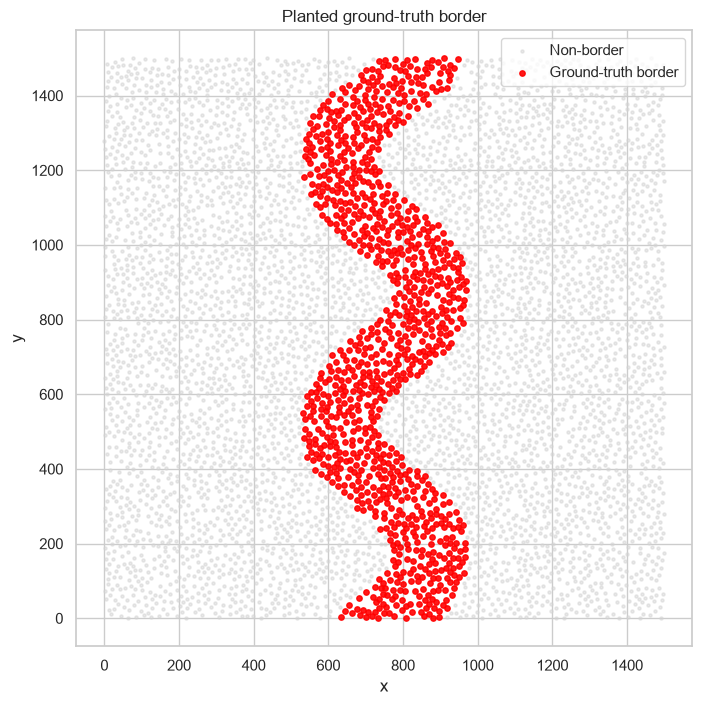

In [366]:
plt.figure(figsize=(8, 8))

plt.scatter(
    synthetic_border.loc[~synthetic_border["true_border"], "x"],
    synthetic_border.loc[~synthetic_border["true_border"], "y"],
    s=5,
    c="lightgray",
    alpha=0.5,
    label="Non-border"
)

plt.scatter(
    synthetic_border.loc[synthetic_border["true_border"], "x"],
    synthetic_border.loc[synthetic_border["true_border"], "y"],
    s=15,
    c="red",
    alpha=0.9,
    label="Ground-truth border"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Planted ground-truth border")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()

In [367]:
synthetic_border["cell_type"].value_counts()

cell_type
6    1083
5     954
3     695
8     669
1     657
4     651
2     648
7     643
Name: count, dtype: int64

In [368]:
border_composition = pd.crosstab(
    synthetic_border["true_border"],
    synthetic_border["cell_type"],
    normalize="index"
)

print(border_composition)

cell_type           1         2         3         4         5         6  \
true_border                                                               
False        0.113317  0.113117  0.122744  0.111111  0.137585  0.157641   
True         0.090730  0.082840  0.081854  0.095661  0.264300  0.292899   

cell_type           7         8  
true_border                      
False        0.119735  0.124749  
True         0.045365  0.046351  


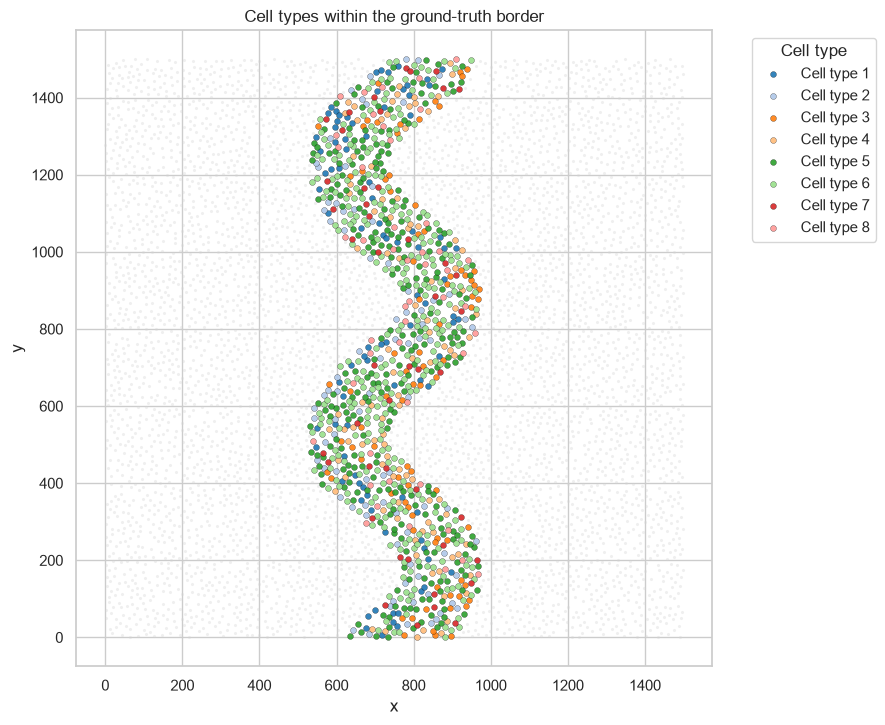

In [369]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = synthetic_border.copy()

cell_types = sorted(plot_df["cell_type"].unique())

palette = sns.color_palette("tab20", n_colors=len(cell_types))
color_dict = dict(zip(cell_types, palette))

plt.figure(figsize=(9, 9))

# Non-border cells in light gray
non_border = plot_df[~plot_df["true_border"]]

plt.scatter(
    non_border["x"],
    non_border["y"],
    s=5,
    c="lightgray",
    alpha=0.35,
    linewidths=0,
)

# Border cells colored by cell type
border = plot_df[plot_df["true_border"]]

for cell_type in cell_types:
    subset = border[border["cell_type"] == cell_type]

    if len(subset) > 0:
        plt.scatter(
            subset["x"],
            subset["y"],
            s=18,
            color=color_dict[cell_type],
            label=f"Cell type {cell_type}",
            alpha=0.9,
            edgecolors="black",
            linewidths=0.2,
        )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Cell types within the ground-truth border")
plt.gca().set_aspect("equal")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Cell type",
)
plt.tight_layout()
plt.show()

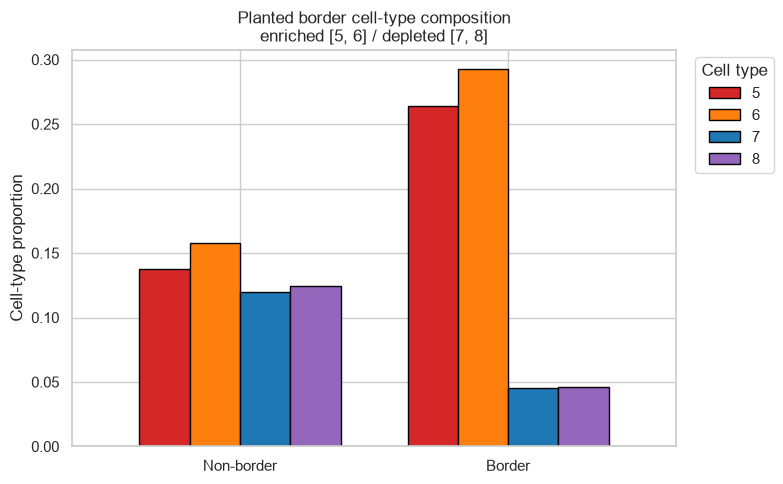

In [370]:
composition_plot = composition.reindex(
    columns=MARKER_TYPES,
    fill_value=0
)

composition_plot.index = [
    "Non-border",
    "Border"
]

ax = composition_plot.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#d62728", "#ff7f0e", "#1f77b4", "#9467bd"][:len(MARKER_TYPES)],
    edgecolor="black",
    width=0.75,
)

ax.set_ylabel("Cell-type proportion")
ax.set_xlabel("")
ax.set_title(
    f"Planted border cell-type composition\n"
    f"enriched {ENRICHED_TYPES} / depleted {DEPLETED_TYPES}"
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

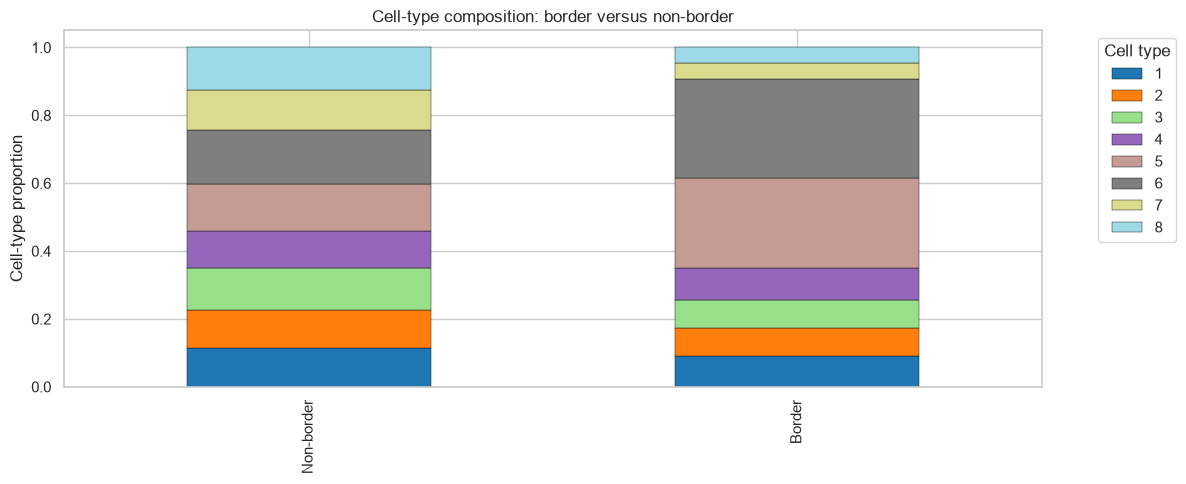

In [371]:
composition = pd.crosstab(
    synthetic_border["true_border"],
    synthetic_border["cell_type"],
    normalize="index",
)

composition = composition.rename(
    index={
        False: "Non-border",
        True: "Border",
    }
)

composition.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    colormap="tab20",
    edgecolor="black",
    linewidth=0.3,
)

plt.ylabel("Cell-type proportion")
plt.xlabel("")
plt.title("Cell-type composition: border versus non-border")
plt.legend(
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

find neighborhoods

In [455]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D


def diagnose_simulation(df, save_dir=None):

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    plot_df = df.copy()

    def save_current_figure(filename):
        if save_dir is not None:
            plt.savefig(
                save_dir / filename,
                dpi=300,
                bbox_inches="tight"
            )

    def make_legend(
        handles,
        title=None,
        filename=None,
        figsize=(2.5, 2),
        fontsize=9,
        ncols=1,
        columnspacing=0.8,
        handletextpad=0.4,
    ):

        fig, ax = plt.subplots(
            figsize=figsize,
            dpi=300
        )

        ax.axis("off")

        ax.legend(
            handles=handles,
            title=title,
            frameon=False,
            loc="center",
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncols=ncols,
            columnspacing=columnspacing,
            handletextpad=handletextpad,
        )

        plt.tight_layout()

        if save_dir is not None and filename is not None:
            fig.savefig(
                save_dir / filename,
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    ####################################################
    # Check required columns
    ####################################################

    required_columns = [
        "x",
        "y",
        "cell_type",
        "true_organization",
        "Neighborhood",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in plot_df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {missing_columns}"
        )

    ####################################################
    # Correct classifications
    ####################################################

    plot_df["Correct"] = (
        plot_df["Neighborhood"]
        == plot_df["true_organization"]
    )

    colors = {
        "A": "tab:blue",
        "B": "tab:orange",
    }

    ####################################################
    # Figure 1: Ground-truth organizations
    ####################################################

    plt.figure(figsize=(6, 6))

    for organization in ["A", "B"]:

        subset = plot_df[
            plot_df["true_organization"] == organization
        ]

        plt.scatter(
            subset["x"],
            subset["y"],
            s=5,
            color=colors[organization],
            label=f"Organization {organization}",
        )

    plt.gca().invert_yaxis()
    plt.gca().grid(False)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Ground Truth Organizations")
    plt.gca().set_aspect("equal")
    plt.tight_layout()

    save_current_figure("ground_truth_organizations.png")

    plt.show()

    make_legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="tab:blue",
                markersize=6,
                label="Organization A",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="tab:orange",
                markersize=6,
                label="Organization B",
            ),
        ],
        title="Ground Truth",
        filename="ground_truth_legend.png",
        figsize=(2.5, 1.5),
    )

    ####################################################
    # Figure 2: Cell types
    ####################################################

    plt.figure(figsize=(6, 6))

    unique_cell_types = np.sort(
        plot_df["cell_type"].unique()
    )

    cell_type_colors = [
        "#1f77b4",   # 1: blue
        "#aec7e8",   # 2: light blue
        "#ffbb78",   # 3: light orange
        "#98df8a",   # 4: light green
        "#e0730de8", # 5: orange
        "#c5b0d5",   # 6: light purple
        "#691e07",   # 7: brown
        "#e377c2",   # 8: pink
    ]

    if len(unique_cell_types) > len(cell_type_colors):
        raise ValueError(
            f"Found {len(unique_cell_types)} cell types, "
            f"but only {len(cell_type_colors)} colors were provided."
        )

    color_map = {
        cell_type: cell_type_colors[i]
        for i, cell_type in enumerate(unique_cell_types)
    }

    for cell_type in unique_cell_types:

        subset = plot_df[
            plot_df["cell_type"] == cell_type
        ]

        plt.scatter(
            subset["x"],
            subset["y"],
            s=5,
            color=color_map[cell_type],
        )

    plt.gca().invert_yaxis()
    plt.gca().grid(False)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Cell Types")
    plt.gca().set_aspect("equal")
    plt.tight_layout()

    save_current_figure("cell_types.png")

    plt.show()

    make_legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=color_map[cell_type],
                markersize=6,
                label=str(cell_type),
            )
            for cell_type in unique_cell_types
        ],
        title="Cell Type",
        filename="cell_type_legend.png",
        figsize=(4, 4),
        ncols=4,
    )

    ####################################################
    # Figure 3: Recovered neighborhoods
    ####################################################

    plt.figure(figsize=(6, 6))

    for neighborhood in ["A", "B"]:

        subset = plot_df[
            plot_df["Neighborhood"] == neighborhood
        ]

        plt.scatter(
            subset["x"],
            subset["y"],
            s=5,
            color=colors[neighborhood],
            label=f"Neighborhood {neighborhood}",
        )

    plt.gca().invert_yaxis()
    plt.gca().grid(False)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Recovered Neighborhoods")
    plt.gca().set_aspect("equal")
    plt.tight_layout()

    save_current_figure("recovered_neighborhoods.png")

    plt.show()

    make_legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="tab:blue",
                markersize=6,
                label="Neighborhood A",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="tab:orange",
                markersize=6,
                label="Neighborhood B",
            ),
        ],
        title="Recovered",
        filename="recovered_neighborhoods_legend.png",
        figsize=(2.5, 1.5),
    )

    ####################################################
    # Figure 4: Classification errors
    ####################################################

    accuracy = plot_df["Correct"].mean()

    plt.figure(figsize=(6, 6))

    plt.scatter(
        plot_df.loc[
            plot_df["Correct"],
            "x"
        ],
        plot_df.loc[
            plot_df["Correct"],
            "y"
        ],
        c="lightgray",
        s=4,
        label="Correct",
    )

    plt.scatter(
        plot_df.loc[
            ~plot_df["Correct"],
            "x"
        ],
        plot_df.loc[
            ~plot_df["Correct"],
            "y"
        ],
        c="red",
        s=8,
        label="Incorrect",
    )

    plt.gca().invert_yaxis()
    plt.gca().grid(False)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"Classification Errors "
        f"(Accuracy = {accuracy:.1%})"
    )
    plt.gca().set_aspect("equal")
    plt.tight_layout()

    save_current_figure("classification_errors.png")

    plt.show()

    make_legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="lightgray",
                markersize=6,
                label="Correct",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="red",
                markersize=6,
                label="Incorrect",
            ),
            Line2D(
                [0],
                [0],
                color="none",
                label=f"Accuracy = {accuracy:.1%}",
            ),
        ],
        title="Classification",
        filename="classification_errors_legend.png",
        figsize=(3, 2),
    )

    ####################################################
    # Figure 5: Cell-type composition
    ####################################################

    composition = pd.crosstab(
        plot_df["true_organization"],
        plot_df["cell_type"],
        normalize="index",
    )

    ax = composition.T.plot(
        kind="bar",
        figsize=(8, 4),
    )

    ax.set_ylabel("Fraction")
    ax.set_xlabel("Cell Type")
    ax.set_title(
        "Cell-type Composition by Organization"
    )

    plt.tight_layout()

    save_current_figure("cell_type_composition.png")

    plt.show()

    ####################################################
    # Figure 6: PCA of neighborhood vectors
    ####################################################

    if "neighborhood_vectors" in df.attrs:

        X = df.attrs["neighborhood_vectors"]

        embedding = PCA(
            n_components=2
        ).fit_transform(X)

        plt.figure(figsize=(6, 6))

        color_values = plot_df[
            "true_organization"
        ].map(colors)

        plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=color_values,
            s=5,
            alpha=0.6,
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("Neighborhood Vector PCA")
        plt.tight_layout()

        save_current_figure("neighborhood_vector_pca.png")

        plt.show()

    ####################################################
    # Figure 7: Accuracy versus distance from border
    ####################################################

    if "border_x" in df.attrs:
        border_x = df.attrs["border_x"]
    else:
        border_x = (
            plot_df["x"].min()
            + plot_df["x"].max()
        ) / 2

    plot_df["distance_from_border"] = np.abs(
        plot_df["x"] - border_x
    )

    bins = np.linspace(
        0,
        plot_df["distance_from_border"].max(),
        20,
    )

    plot_df["distance_bin"] = pd.cut(
        plot_df["distance_from_border"],
        bins=bins,
        include_lowest=True,
    )

    distance_summary = (
        plot_df
        .groupby(
            "distance_bin",
            observed=True
        )
        .agg(
            mean_distance=(
                "distance_from_border",
                "mean",
            ),
            accuracy=(
                "Correct",
                "mean",
            ),
            n=(
                "Correct",
                "size",
            ),
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(
        figsize=(8, 5)
    )

    ax1.plot(
        distance_summary["mean_distance"],
        distance_summary["accuracy"],
        marker="o",
        linewidth=2,
    )

    ax1.set_xlabel(
        "Distance from Organization Boundary"
    )

    ax1.set_ylabel(
        "Neighborhood Accuracy"
    )

    ax1.set_ylim(0, 1.02)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()

    bar_width = (
        distance_summary["mean_distance"].max()
        / 25
    )

    ax2.bar(
        distance_summary["mean_distance"],
        distance_summary["n"],
        width=bar_width,
        alpha=0.2,
    )

    ax2.set_ylabel("Cells per Bin")

    plt.title(
        "Neighborhood Accuracy "
        "vs Distance from Boundary"
    )

    plt.tight_layout()

    if save_dir is not None:
        fig.savefig(
            save_dir / "accuracy_vs_border_distance.png",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    ####################################################
    # Figure 8: Confusion matrix
    ####################################################

    confusion_matrix = pd.crosstab(
        plot_df["true_organization"],
        plot_df["Neighborhood"],
    )

    print("\nConfusion Matrix\n")
    display(confusion_matrix)

    plt.figure(figsize=(5, 4))

    plt.imshow(
        confusion_matrix.values,
        cmap="Blues",
        aspect="auto",
    )

    plt.xticks(
        range(len(confusion_matrix.columns)),
        confusion_matrix.columns,
    )

    plt.yticks(
        range(len(confusion_matrix.index)),
        confusion_matrix.index,
    )

    plt.xlabel("Recovered Neighborhood")
    plt.ylabel("True Organization")
    plt.title("Confusion Matrix")

    for i in range(
        confusion_matrix.shape[0]
    ):
        for j in range(
            confusion_matrix.shape[1]
        ):
            plt.text(
                j,
                i,
                confusion_matrix.iloc[i, j],
                ha="center",
                va="center",
            )

    plt.colorbar(label="Number of Cells")
    plt.tight_layout()

    save_current_figure("confusion_matrix.png")

    plt.show()

    ####################################################
    # Summary
    ####################################################

    accuracy = plot_df["Correct"].mean()

    accuracy_A = plot_df.loc[
        plot_df["true_organization"] == "A",
        "Correct",
    ].mean()

    accuracy_B = plot_df.loc[
        plot_df["true_organization"] == "B",
        "Correct",
    ].mean()

    print(f"\nOverall Accuracy : {accuracy:.3f}")
    print(f"Accuracy A       : {accuracy_A:.3f}")
    print(f"Accuracy B       : {accuracy_B:.3f}")

    if save_dir is not None:
        print(f"\nFigures saved to: {save_dir}")


In [373]:
def run_neighborhood_finder(
    cells,
    ks=[10, 20, 30],
    k=None,
    n_neighborhoods=2,
    random_state=0,
):
    """
    Run the CellHier-style neighborhood finder on a dataframe produced by
    simulate_tissue().

    Returns
    -------
    pandas.DataFrame
        Original dataframe with an added 'Neighborhood' column.

    Notes
    -----
    Three changes from the previous version:

    * `k` defaults to the k the simulation was built around
      (`cells.attrs["k"]`), so the window used for clustering matches the
      window the border width was scaled to.
    * The merge is on `cell_id`, not on float `x`/`y` coordinates.
    * `df.attrs` is restored after the merge - pandas drops `.attrs` through
      `pd.merge`, which silently discarded the planted ground truth in the
      previous version.
    * `KMeans` with `n_init=20` rather than a single-init `MiniBatchKMeans`;
      the two-cluster solution was otherwise seed-dependent.
    """

    ####################################################
    # Copy input, remember the planted truth
    ####################################################

    df = cells.copy()

    planted_attrs = dict(cells.attrs)

    if k is None:
        k = planted_attrs.get("k", 10)

    if k not in ks:
        ks = sorted(set(list(ks) + [k]))

    cells = cells.copy()

    ####################################################
    # Setup
    ####################################################

    X = "x"
    Y = "y"
    reg = "unique_region"
    cluster_col = "cell_type"

    cells[reg] = cells[reg].astype(str)
    df[reg] = df[reg].astype(str)

    keep_cols = [X, Y, reg, cluster_col]

    ####################################################
    # Dummy encoding
    ####################################################

    cells.reset_index(drop=True, inplace=True)

    dummies = pd.get_dummies(cells[cluster_col])

    # sorted, so the column order is stable across regions
    sum_cols = list(dummies.columns)

    cells = pd.concat([cells, dummies], axis=1)

    values = cells[sum_cols].values.astype(float)

    ####################################################
    # Nearest-neighbor setup
    ####################################################

    n_neighbors = max(ks)

    tissue_group = cells[[X, Y, reg]].groupby(reg)

    exps = list(cells[reg].unique())

    ####################################################
    # Helper function
    ####################################################

    def get_windows(job, n_neighbors):

        start_time, idx, tissue_name, indices = job

        job_start = time.time()

        print(f"Starting: {idx+1}/{len(exps)} : {tissue_name}")

        tissue = tissue_group.get_group(tissue_name)

        to_fit = tissue.loc[indices][[X, Y]].values

        fit = NearestNeighbors(
            n_neighbors=n_neighbors
        ).fit(
            tissue[[X, Y]].values
        )

        distances, neighbors = fit.kneighbors(to_fit)

        args = distances.argsort(axis=1)

        add = np.arange(neighbors.shape[0]) * neighbors.shape[1]

        sorted_indices = neighbors.flatten()[args + add[:, None]]

        neighbors = tissue.index.values[sorted_indices]

        end_time = time.time()

        print(
            f"Finished: {idx+1}/{len(exps)} "
            f"({end_time-job_start:.2f} sec)"
        )

        return neighbors.astype(np.int32)

    ####################################################
    # Build neighborhood graph
    ####################################################

    tissue_chunks = [

        (
            time.time(),
            exps.index(t),
            t,
            a,
        )

        for t, indices in tissue_group.groups.items()

        for a in np.array_split(indices, 1)

    ]

    tissues = [

        get_windows(job, n_neighbors)

        for job in tissue_chunks

    ]

    ####################################################
    # Neighborhood vectors
    ####################################################

    out_dict = {}

    for kk in ks:

        for neighbors, job in zip(tissues, tissue_chunks):

            chunk = np.arange(len(neighbors))

            tissue_name = job[2]

            indices = job[3]

            window = (

                values[
                    neighbors[:, :kk].flatten()
                ]

                .reshape(
                    len(chunk),
                    kk,
                    len(sum_cols),
                )

                .sum(axis=1)

            )

            out_dict[(tissue_name, kk)] = (

                window,

                indices,

            )

    ####################################################
    # Assemble windows
    ####################################################

    windows = {}

    for kk in ks:

        window = pd.concat(

            [

                pd.DataFrame(

                    out_dict[(exp, kk)][0],

                    index=out_dict[(exp, kk)][1].astype(int),

                    columns=sum_cols,

                )

                for exp in exps

            ],

            axis=0,

        )

        window = window.loc[cells.index.values]

        window = pd.concat(

            [

                cells[keep_cols],

                window,

            ],

            axis=1,

        )

        windows[kk] = window

    ####################################################
    # Select neighborhood size
    ####################################################

    windows2 = windows[k].copy()

    windows2[cluster_col] = cells[cluster_col]

    ####################################################
    # KMeans
    #
    # Full KMeans with n_init=20 rather than a
    # single-init MiniBatchKMeans - the two-cluster
    # solution was otherwise seed-dependent.
    ####################################################

    neighborhood_name = f"neighborhood{k}"

    km = KMeans(

        n_clusters=n_neighborhoods,

        random_state=random_state,

        n_init=20,

    )

    labels = km.fit_predict(

        windows2[sum_cols].values

    )

    cells[neighborhood_name] = labels

    ####################################################
    # Convert cluster labels using majority vote
    ####################################################

    crosstab = pd.crosstab(
        cells[neighborhood_name],
        df["true_organization"],
    )

    cluster_to_org = crosstab.idxmax(axis=1).to_dict()

    # Guard against two clusters claiming the same
    # organization; fall back to raw cluster ids so a
    # degenerate solution is visible instead of silently
    # scoring as if it had worked.
    if len(set(cluster_to_org.values())) == n_neighborhoods:
        cells["Neighborhood"] = cells[
            neighborhood_name
        ].map(cluster_to_org)
    else:
        print(
            "WARNING: clusters do not map one-to-one onto "
            "organizations; using raw cluster ids."
        )
        cells["Neighborhood"] = cells[
            neighborhood_name
        ].astype(str)

    ####################################################
    # Merge back on cell_id, not on float coordinates
    ####################################################

    new_neighborhoods = cells[
        [
            "cell_id",
            "Neighborhood",
        ]
    ].copy()

    merged_df = pd.merge(

        df,

        new_neighborhoods,

        on="cell_id",

        how="left",

    )

    assert merged_df["Neighborhood"].notna().all(), \
        "merge on cell_id left unmatched rows"

    ####################################################
    # Restore attrs - pd.merge drops them
    ####################################################

    merged_df.attrs.update(planted_attrs)

    merged_df.attrs["neighborhood_vectors"] = windows2[sum_cols].values

    merged_df.attrs["window_sum_cols"] = list(sum_cols)

    merged_df.attrs["neighborhood_k"] = k

    return merged_df

In [374]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_recovery(df, verbose=True):
    """
    Evaluate neighborhood recovery against the known ground truth.

    Parameters
    ----------
    df : pandas.DataFrame
        Output of run_neighborhood_finder().

    verbose : bool
        Print summary statistics.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    ####################################################
    # True and predicted labels
    ####################################################

    y_true = df["true_organization"]
    y_pred = df["Neighborhood"]

    ####################################################
    # Overall accuracy
    ####################################################

    accuracy = accuracy_score(y_true, y_pred)

    ####################################################
    # Per-organization accuracy
    ####################################################

    accuracy_A = (
        df.loc[df.true_organization == "A", "Neighborhood"] == "A"
    ).mean()

    accuracy_B = (
        df.loc[df.true_organization == "B", "Neighborhood"] == "B"
    ).mean()

    ####################################################
    # Confusion matrix
    ####################################################

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["A", "B"]
    )

    ####################################################
    # Store metrics
    ####################################################

    metrics = {
        "accuracy": accuracy,
        "accuracy_A": accuracy_A,
        "accuracy_B": accuracy_B,
        "confusion_matrix": cm,
        "n_cells": len(df),
    }

    ####################################################
    # Print summary
    ####################################################

    if verbose:

        print(f"Overall Accuracy : {accuracy:.3f}")
        print(f"Accuracy A       : {accuracy_A:.3f}")
        print(f"Accuracy B       : {accuracy_B:.3f}")

        print()

        print("Confusion Matrix")

        print(
            pd.DataFrame(
                cm,
                index=["True A", "True B"],
                columns=["Pred A", "Pred B"],
            )
        )

    return metrics

In [375]:
synthetic_border = run_neighborhood_finder(
    synthetic_border,
    k=K_WINDOW,
)

####################################################
# attrs survive the merge now
####################################################

print("planted truth preserved:",
      "enriched_types" in synthetic_border.attrs)

print(evaluate_recovery(synthetic_border))

Starting: 1/1 : 1
Finished: 1/1 (0.05 sec)
planted truth preserved: True
Overall Accuracy : 0.974
Accuracy A       : 0.984
Accuracy B       : 0.963

Confusion Matrix
        Pred A  Pred B
True A    2973      47
True B     109    2871
{'accuracy': 0.974, 'accuracy_A': np.float64(0.9844370860927152), 'accuracy_B': np.float64(0.9634228187919464), 'confusion_matrix': array([[2973,   47],
       [ 109, 2871]]), 'n_cells': 6000}


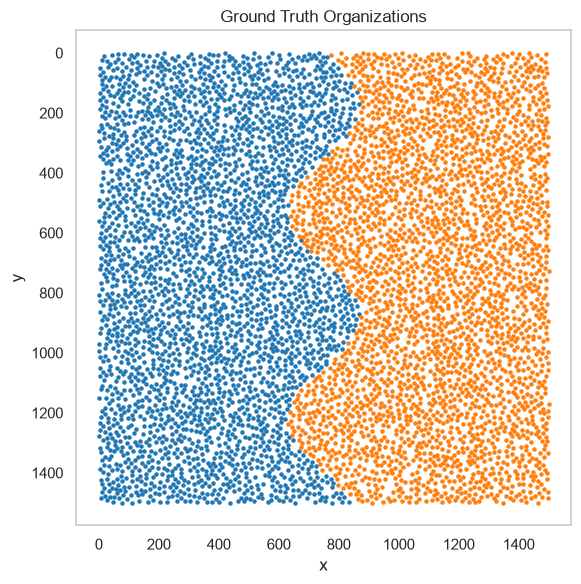

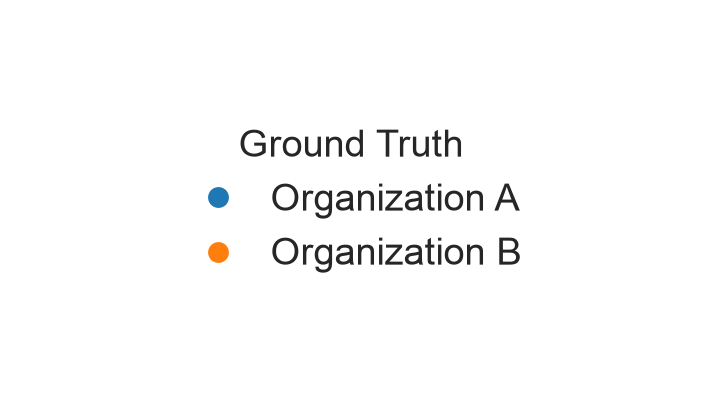

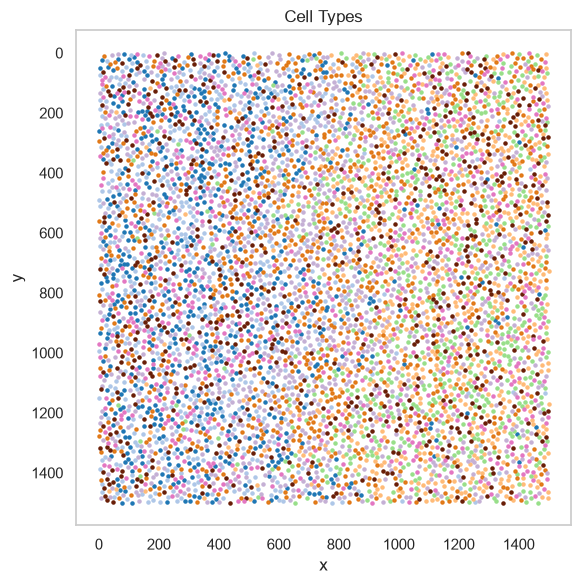

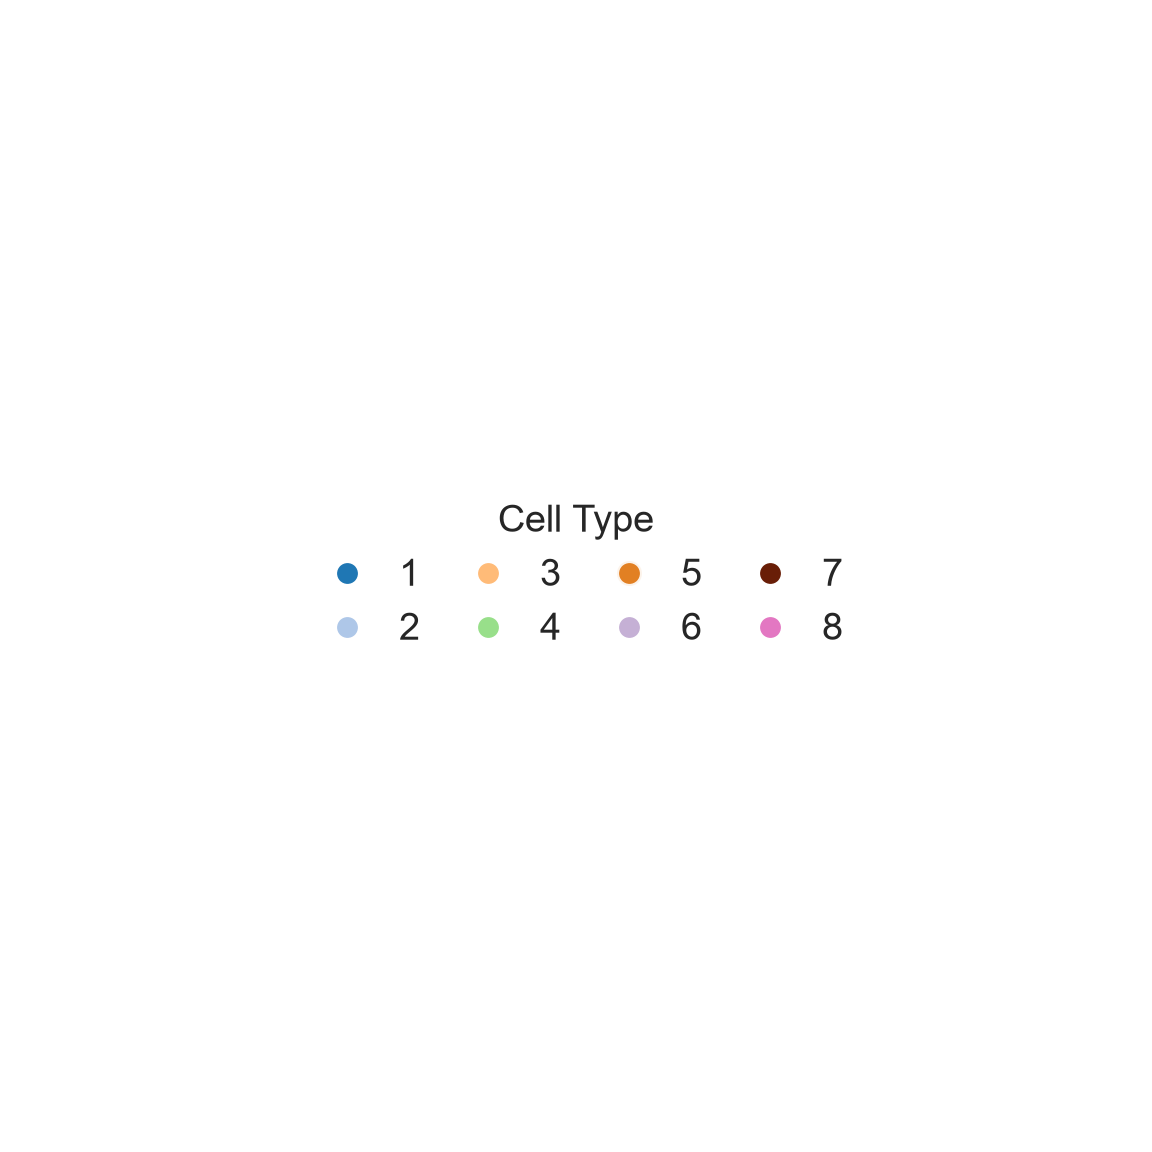

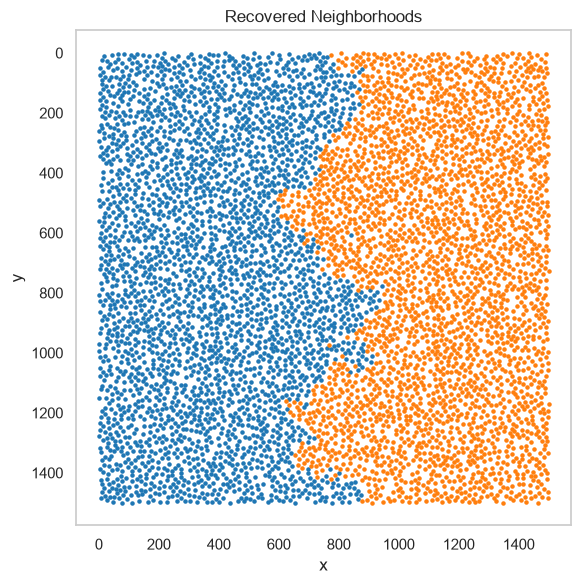

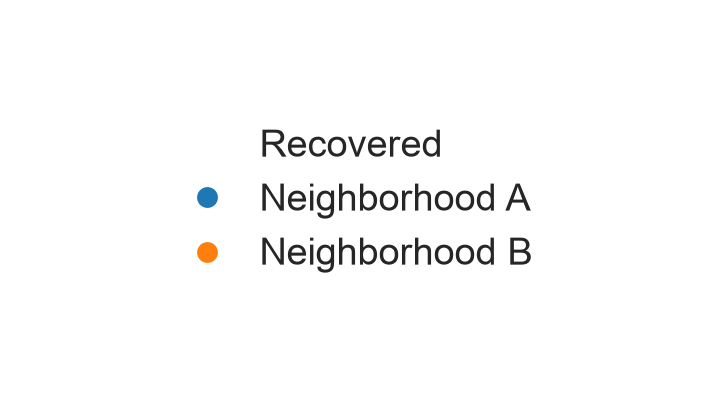

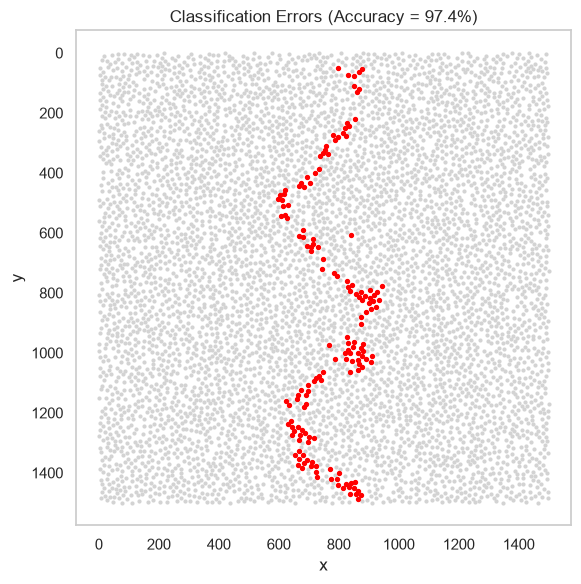

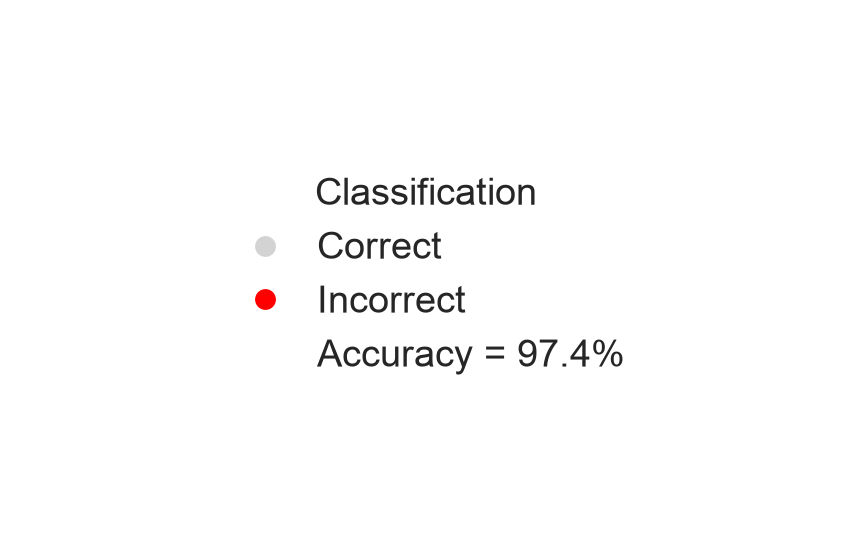

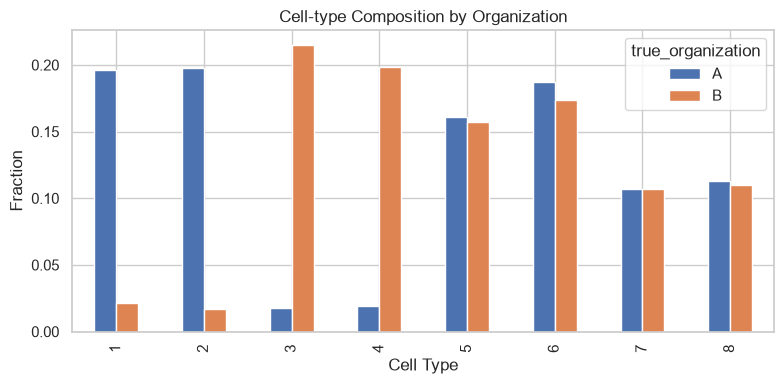

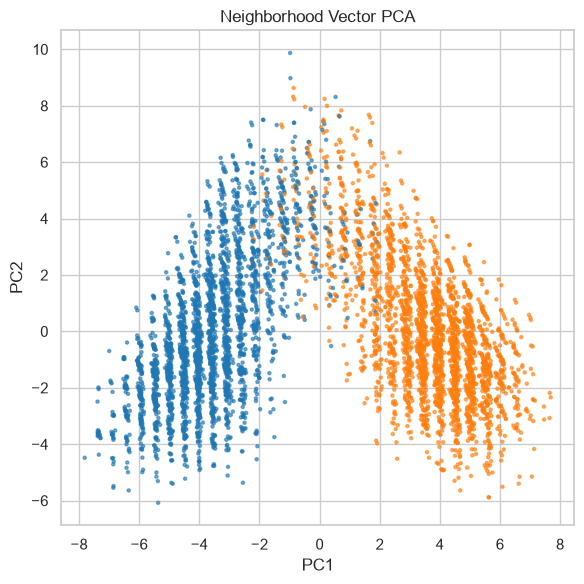

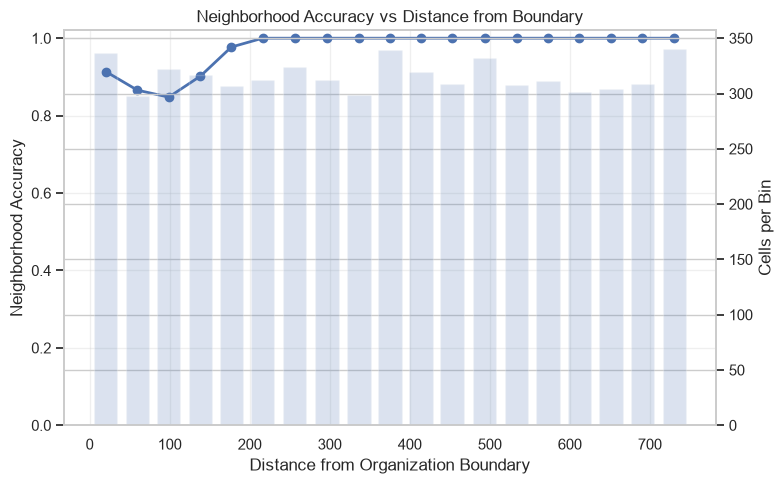


Confusion Matrix



Neighborhood,A,B
true_organization,,
A,2973,47
B,109,2871


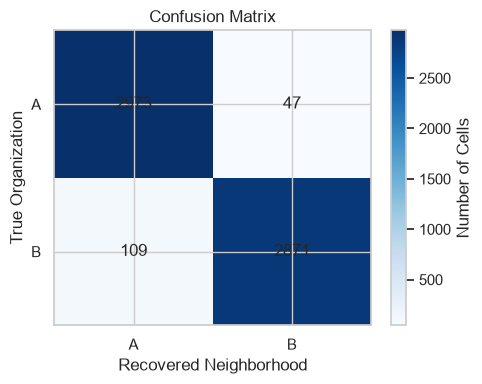


Overall Accuracy : 0.974
Accuracy A       : 0.984
Accuracy B       : 0.963

Figures saved to: /Users/bharatkikani/Desktop/figures


In [456]:
diagnose_simulation(synthetic_border, save_dir="/Users/bharatkikani/Desktop/figures")

In [377]:
####################################################
# Save the simulated tissue
#
# Ground-truth columns are carried as COLUMNS, so they
# survive the round trip through CSV. The previous
# version put templates in .attrs, which pandas drops
# through pd.merge and does not write to CSV at all.
####################################################

CSV_PATH = os.path.join(OUT_DIR, "synthetic_tissue_fast_withborder.csv")

synthetic_border.to_csv(CSV_PATH, index=False)

####################################################
# Persist the planted truth alongside it
####################################################

import json

TRUTH_PATH = os.path.join(OUT_DIR, "planted_truth.json")

with open(TRUTH_PATH, "w") as fh:
    json.dump(
        {
            key: (
                value.tolist()
                if isinstance(value, np.ndarray)
                else value
            )
            for key, value in synthetic_border.attrs.items()
        },
        fh,
        indent=2,
    )

print("wrote", CSV_PATH)
print("wrote", TRUTH_PATH)

wrote /Volumes/data/MINGLE/Reviewer Response/Code/R1.5/synthetic_tissue_fast_withborder.csv
wrote /Volumes/data/MINGLE/Reviewer Response/Code/R1.5/planted_truth.json


In [378]:
file_path = CSV_PATH
cells = mg.pp.read_file(file_path)

/opt/miniconda3/envs/mingl-env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [379]:
cells.obs

,cell_id,x,y,cell_type,unique_region,true_organization,true_border,true_border_operational,signed_distance,distance_from_border,window_frac_B,Neighborhood
0,0,205.045310,1322.758766,1,1,A,False,False,-360.595662,360.595662,0.0,A
1,1,1067.469050,599.405782,3,1,B,False,False,342.480053,342.480053,1.0,B
2,2,1403.731354,537.997025,7,1,B,False,False,766.911903,766.911903,1.0,B
3,3,852.773516,221.099842,5,1,A,True,True,-6.514162,6.514162,0.5,B
4,4,334.383767,695.634156,8,1,A,False,False,-279.695707,279.695707,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5995,249.115136,951.748081,1,1,A,False,False,-489.723467,489.723467,0.0,A
5996,5996,549.116242,473.522407,5,1,A,True,False,-84.257436,84.257436,0.0,A
5997,5997,1197.595965,39.215769,8,1,B,False,False,285.656896,285.656896,1.0,B
5998,5998,1158.096675,1144.550616,5,1,B,False,False,405.807195,405.807195,1.0,B


### compute centroids

`centroid_Calculation` and `cpu_gmm_probability` both default to `k=10`. The
simulation's border width was scaled to the **k=20** window radius, so the
window MINGL scores must be the same window — otherwise the planted mixing zone
and the zone MINGL can resolve are two different length scales. `k=K_WINDOW` is
passed explicitly below.

In [380]:
cells.obs["cell_type"] = cells.obs["cell_type"].astype(str)

In [381]:
cluster_col = "cell_type"
neighborhood_col = "Neighborhood"
region_key = "unique_region"

In [382]:
centroids = mg.tl.centroid_Calculation(
    cells,
    k=K_WINDOW,
    cluster_col=cluster_col,
    neighborhood_col=neighborhood_col,
    region_col=region_key,
    store_key="neighborhood_centroids",
)

Example dummy cols: ['cell_type__1', 'cell_type__2', 'cell_type__3', 'cell_type__4', 'cell_type__5']
{5:                 x            y  unique_region cell_type    1    2    3    4  \
0      205.045310  1322.758766              1         1  1.0  2.0  0.0  0.0   
1     1067.469050   599.405782              1         3  0.0  0.0  2.0  0.0   
2     1403.731354   537.997025              1         7  0.0  0.0  3.0  0.0   
3      852.773516   221.099842              1         5  1.0  0.0  1.0  0.0   
4      334.383767   695.634156              1         8  2.0  0.0  0.0  0.0   
...           ...          ...            ...       ...  ...  ...  ...  ...   
5995   249.115136   951.748081              1         1  2.0  1.0  0.0  0.0   
5996   549.116242   473.522407              1         5  0.0  1.0  0.0  0.0   
5997  1197.595965    39.215769              1         8  0.0  0.0  0.0  0.0   
5998  1158.096675  1144.550616              1         5  0.0  0.0  1.0  0.0   
5999   146.118515   265.24

/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


compute cluster membership probabilities

In [383]:
mg.tl.cpu_gmm_probability(
    CELLS_ADATA=cells,
    CENTROIDS_ADATA=centroids,
    cluster_col=cluster_col,
    neighborhood_col=neighborhood_col,
    region_key=region_key,
    ks=(K_WINDOW,),
    k=K_WINDOW,
)

Example dummy cols: ['cell_type__1', 'cell_type__2', 'cell_type__3', 'cell_type__4', 'cell_type__5']


AnnData object with n_obs × n_vars = 6000 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'true_border', 'true_border_operational', 'signed_distance', 'distance_from_border', 'window_frac_B', 'Neighborhood'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [384]:
mg.tl.findPositives(cells)

AnnData object with n_obs × n_vars = 6000 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'true_border', 'true_border_operational', 'signed_distance', 'distance_from_border', 'window_frac_B', 'Neighborhood', 'Count_Above_Threshold'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [385]:
H5AD_PATH = os.path.join(OUT_DIR, "simulation_withborder_results.h5ad")

cells.write_h5ad(H5AD_PATH)

print("wrote", H5AD_PATH)

wrote /Volumes/data/MINGLE/Reviewer Response/Code/R1.5/simulation_withborder_results.h5ad


probability binning

In [386]:
df_probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)
df_probabilities

,A,B
0,1.000000e+00,4.688047e-35
1,6.947284e-22,1.000000e+00
2,5.388206e-42,1.000000e+00
3,2.473254e-02,9.752675e-01
4,1.000000e+00,3.236220e-25
...,...,...
5995,1.000000e+00,6.979748e-19
5996,1.000000e+00,7.311181e-10
5997,4.363995e-09,1.000000e+00
5998,2.713362e-24,1.000000e+00


In [387]:
# Define units of interest
tu1 = "A"
tu2 = "B"

# Additional columns needed downstream
extra_cols = ['x','y','unique_region','Neighborhood','cell_type','true_organization']

# Create new dataframe
df2 = cells.obs[extra_cols].copy()
df2[tu1] = df_probabilities[tu1]
df2[tu2] = df_probabilities[tu2]

df2

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25
...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00


In [388]:
# ratio with small constant to avoid division by zero
eps = 1e-9
df2["ratio"] = (df2[tu1] + eps) / (df2[tu2] + eps)

# log ratio
df2["log_ratio"] = np.log(df2["ratio"])

# max probability
df2["max_prob"] = df2[[tu1, tu2]].max(axis=1)

# final score
df2["Score"] = df2["log_ratio"] * df2["max_prob"]

df2

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35,1.000000e+09,20.723266,1.000000,20.723266
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01,2.535975e-02,-3.674592,0.975267,-3.583710
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25,1.000000e+09,20.723266,1.000000,20.723266
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19,1.000000e+09,20.723266,1.000000,20.723266
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10,5.776613e+08,20.174498,1.000000,20.174498
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00,5.363995e-09,-19.043557,1.000000,-19.043557
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266


In [389]:
def _percentile_labels(n_bins):
    step = 100 / n_bins
    return [f"{int((i + 1) * step)}th percentile" for i in range(n_bins)]

def assign_probability_level_equal_width(series, n_bins=5):
    """
    Split non-missing rows into `n_bins` equal-width bins based on
    the numeric score range (min → max).

    Returns:
      - pd.Series (categorical) with percentile-style labels
      - numpy.ndarray of numeric edges:
            [left_edge_bin1, ..., right_edge_binK]

    NaNs are preserved.
    """

    idx = series.index
    s_non_na = series.dropna()

    if len(s_non_na) == 0:
        labels = _percentile_labels(n_bins)
        cat = pd.Series(
            pd.Categorical([np.nan] * len(series), categories=labels, ordered=True),
            index=idx
        )
        return cat, np.array([])

    # Compute equal-width edges
    min_val = float(s_non_na.min())
    max_val = float(s_non_na.max())

    if min_val == max_val:
        # All values identical → single bin
        labels = _percentile_labels(1)
        cat = pd.Series(
            pd.Categorical(
                [labels[0] if not pd.isna(v) else np.nan for v in series],
                categories=labels,
                ordered=True
            ),
            index=idx
        )
        return cat, np.array([min_val, max_val])

    edges = np.linspace(min_val, max_val, n_bins + 1)

    labels = _percentile_labels(n_bins)

    # Create categorical bins
    binned = pd.cut(
        series,
        bins=edges,
        labels=labels,
        include_lowest=True
    )

    # Debug output
    counts = binned.value_counts(dropna=True).sort_index()
    print("Counts per bin:", counts.to_dict())
    print("Bin edges (equal-width):", edges)

    return binned, edges


In [390]:
# ---------------- Example usage ----------------
df2["Probability_Level"], edges_used = assign_probability_level_equal_width(df2["Score"], n_bins=5)
print(edges_used)
print(df2["Probability_Level"].value_counts(dropna=False))
df = df2
df

Counts per bin: {'20th percentile': 2648, '40th percentile': 217, '60th percentile': 177, '80th percentile': 254, '100th percentile': 2704}
Bin edges (equal-width): [-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
[-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
Probability_Level
100th percentile    2704
20th percentile     2648
80th percentile      254
40th percentile      217
60th percentile      177
Name: count, dtype: int64


,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01,2.535975e-02,-3.674592,0.975267,-3.583710,60th percentile
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10,5.776613e+08,20.174498,1.000000,20.174498,100th percentile
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00,5.363995e-09,-19.043557,1.000000,-19.043557,20th percentile
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile


In [391]:
import re
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Settings / names ----------
ks = [10,20,30,50,100]
X = 'x'
Y = 'y'
reg = 'unique_region'
neigh = 'Neighborhood'
cluster_col = 'Probability_Level'   # e.g., "20th percentile", "40th percentile", ...
celltype = 'Cell Type'
tiss = 'Tissue Unit'
comm = 'Community'

In [392]:
df.reset_index(inplace=True, drop=True)
df

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01,2.535975e-02,-3.674592,0.975267,-3.583710,60th percentile
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19,1.000000e+09,20.723266,1.000000,20.723266,100th percentile
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10,5.776613e+08,20.174498,1.000000,20.174498,100th percentile
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00,5.363995e-09,-19.043557,1.000000,-19.043557,20th percentile
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile


In [393]:
# ---------- Preconditions ----------
if cluster_col not in df.columns:
    raise KeyError(f"Column '{cluster_col}' not found in df.")

# --- 1) Create dummies from the cluster_col and attach to df ---
dummies = pd.get_dummies(df[cluster_col], dtype=int)
df = pd.concat([df, dummies], axis=1)

# --- 2) Use the dummy column names as the summary columns everywhere ---
sum_cols2 = dummies.columns.tolist()
values = df[sum_cols2].values
df

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level,20th percentile,40th percentile,60th percentile,80th percentile,100th percentile
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35,1.000000e+09,20.723266,1.000000,20.723266,100th percentile,0,0,0,0,1
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile,1,0,0,0,0
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile,1,0,0,0,0
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01,2.535975e-02,-3.674592,0.975267,-3.583710,60th percentile,0,0,1,0,0
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25,1.000000e+09,20.723266,1.000000,20.723266,100th percentile,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19,1.000000e+09,20.723266,1.000000,20.723266,100th percentile,0,0,0,0,1
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10,5.776613e+08,20.174498,1.000000,20.174498,100th percentile,0,0,0,0,1
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00,5.363995e-09,-19.043557,1.000000,-19.043557,20th percentile,1,0,0,0,0
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00,1.000000e-09,-20.723266,1.000000,-20.723266,20th percentile,1,0,0,0,0


In [394]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys



class Neighborhoods(object):
    def __init__(self, cells,ks,cluster_col,sum_cols,keep_cols,neigh,X='X:X',Y = 'Y:Y',reg = 'Exp',add_dummies = True):
        self.cells_nodumz = cells
        self.X = X
        self.Y = Y
        self.reg = reg
        self.keep_cols = keep_cols
        self.sum_cols = sum_cols
        self.ks = ks
        self.cluster_col = cluster_col
        self.n_neighbors = max(ks)
        self.exps = list(self.cells_nodumz[self.reg].unique())
        self.bool_add_dummies = add_dummies
        self.neigh = neigh
        
    def add_dummies(self):
        
        c = self.cells_nodumz
        dumz = pd.get_dummies(c[self.cluster_col], dtype=int)
        keep = c[self.keep_cols]
        
        self.cells = pd.concat([keep,dumz],axis = 1)
        
        
        
    def get_tissue_chunks(self):
        self.tissue_group = self.cells[[self.X,self.Y,self.reg]].groupby(self.reg)
        
        tissue_chunks = [(time.time(),self.exps.index(t),t,a) for t,indices in self.tissue_group.groups.items() for a in np.array_split(indices,1)] 
        return tissue_chunks
    
    def make_windows(self,job):
        

        start_time,idx,tissue_name,indices = job
        job_start = time.time()

        print ("Starting:", str(idx+1)+'/'+str(len(self.exps)),': ' + self.exps[idx])

        tissue = self.tissue_group.get_group(tissue_name)
        to_fit = tissue.loc[indices][[self.X,self.Y]].values

        fit = NearestNeighbors(n_neighbors=self.n_neighbors+1).fit(tissue[[self.X,self.Y]].values)
        m = fit.kneighbors(to_fit)
        
        #don't include index cell in window (can always easily add to windows again later by just adding 1)
        m = m[0][:,1:], m[1][:,1:]


        #sort_neighbors
        args = m[0].argsort(axis = 1)
        add = np.arange(m[1].shape[0])*m[1].shape[1]
        sorted_indices = m[1].flatten()[args+add[:,None]]
        sorted_dists = m[0].flatten()[args+add[:,None]]
        neighbors = tissue.index.values[sorted_indices].astype(np.int32)
        end_time = time.time()

        print ("Finishing:", str(idx+1)+"/"+str(len(self.exps)),": "+ self.exps[idx],end_time-job_start,end_time-start_time)
        return neighbors,sorted_dists
    
    def k_windows(self,distance_max = 'none'):
        if self.bool_add_dummies:
            self.add_dummies()
        else:
            self.cells =self.cells_nodumz
        sum_cols = list(self.sum_cols)
        for col in sum_cols:
            if col in self.keep_cols:
                self.cells[col+'_sum'] = self.cells[col]
                self.sum_cols.remove(col)
                self.sum_cols+=[col+'_sum']

        values = self.cells[self.sum_cols].values
        tissue_chunks = self.get_tissue_chunks()
        tissues = [self.make_windows(job) for job in tissue_chunks]
        
        out_dict = {}
        if distance_max == 'none':
            k_dists = {k:np.inf for k in self.ks}
        else:
            k_dists = {k: distance_max for k in self.ks}

        print("k_dists:", k_dists, "Type:", type(k_dists))
        print("distance_max:", distance_max, "Type:", type(distance_max))

        for k in self.ks:
            for (neighbors,sorted_dists),job in zip(tissues,tissue_chunks):
                chunk = np.arange(len(neighbors))#indices
                tissue_name = job[2]
                indices = job[3]
                window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(self.sum_cols))

                mask = sorted_dists>k_dists[k]
                no_cells_masked = mask.sum(1)
                avg_cells_excluded = no_cells_masked[no_cells_masked!=0]
                if len(avg_cells_excluded)>0:
                    avg_cells_excluded = avg_cells_excluded.mean()
                else:
                    avg_cells_excluded = 0
                print ('{}:{}--{}/{} cells had cells excluded.  Avg excluded={}'.format(tissue_name,k,(no_cells_masked>0).sum(),len(no_cells_masked),avg_cells_excluded))

                mask = np.repeat(mask[:, :k, np.newaxis], len(sum_cols), axis=2)# don't sum cells that are outside max_distance
                masked_window = np.ma.array(window,mask = mask)
                summed = masked_window.sum(1).data

                out_dict[(tissue_name,k)] = (summed.astype(np.float16),indices)
        
        windows = {}
        for k in self.ks:

            window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = self.sum_cols) for exp in self.exps],axis=0)
            window = window.loc[self.cells.index.values]
            window = pd.concat([self.cells[self.keep_cols],window],axis=1)
            windows[k] = window
        return windows



In [395]:
df["Cell Type"] = df["cell_type"].astype(str)

df["Community"] = "None"

df["Tissue Unit"] = "None"

df["unique_region"] = df["unique_region"].astype(str)

In [396]:
# ---------- Neighborhoods (original dataframe pipeline) ----------
Neigh = Neighborhoods(df, ks=ks, cluster_col=cluster_col,
                      sum_cols=sum_cols2, reg=reg,
                      keep_cols=[X, Y, reg, neigh, celltype, cluster_col],
                      neigh=neigh, X=X, Y=Y, add_dummies=True)

cluster_name_windows = Neigh.k_windows(distance_max=1000)

Starting: 1/1 : 1
Finishing: 1/1 : 1 0.15282797813415527 0.15283203125
k_dists: {10: 1000, 20: 1000, 30: 1000, 50: 1000, 100: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/6000 cells had cells excluded.  Avg excluded=0
1:20--0/6000 cells had cells excluded.  Avg excluded=0
1:30--0/6000 cells had cells excluded.  Avg excluded=0
1:50--0/6000 cells had cells excluded.  Avg excluded=0
1:100--0/6000 cells had cells excluded.  Avg excluded=0


In [397]:
# ---------- pick k and clusters ----------
k = 20
clusters = 5
windows2 = cluster_name_windows[k]

# ---------- Ensure windows2 and df are index-aligned ----------
if not windows2.index.equals(df.index):
    if len(windows2) == len(df):
        windows2 = windows2.reset_index(drop=True)
        df = df.reset_index(drop=True)
    else:
        raise ValueError("windows2 and df indices differ and lengths differ; align them before filtering.")

# ----------------- filter to target neighborhoods BEFORE clustering -----------------
target_neighborhoods = ['A', 'B']
mask = df['Neighborhood'].isin(target_neighborhoods)
windows2_sub = windows2.loc[mask].copy()
df_sub = df.loc[mask].copy()

if windows2_sub.empty:
    raise ValueError(f"No rows found for Neighborhood in {target_neighborhoods}.")

# ---------- clustering ----------
n_neighborhoods = clusters
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Prefer windows2_sub summary columns if present, otherwise df_sub dummies
if set(sum_cols2).issubset(windows2_sub.columns):
    feature_matrix = windows2_sub[sum_cols2].values
else:
    feature_matrix = df_sub[sum_cols2].values

labels_sub = km.fit_predict(feature_matrix)
k_centroids = {k: km.cluster_centers_}

# assign labels into df_sub and full df (use .loc to avoid SettingWithCopyWarning)
neighborhood_name = neigh + str(k)
df_sub = df_sub.copy()
df_sub.loc[:, neighborhood_name] = labels_sub

df = df.copy()
df.loc[:, neighborhood_name] = -1
df.loc[mask, neighborhood_name] = labels_sub


Desired column order (left->right): ['100th percentile', '80th percentile', '60th percentile', '40th percentile', '20th percentile']
Top neighborhoods (by weighted score): [1, 3, 0, 4, 2]
[1, 3, 0, 4, 2]
5


/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/1369776846.py:56: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[cluster_col]):


,score,cent_100th percentile,cent_80th percentile,cent_60th percentile,cent_40th percentile,cent_20th percentile
1,15.611590,-0.955465,-0.037100,-0.006344,-0.000882,-0.000208
3,8.457767,-0.294256,-0.314674,-0.250000,-0.091209,-0.049860
0,2.763077,-0.031404,-0.071926,-0.158458,-0.313167,-0.425045
4,1.374368,-0.004077,-0.010897,-0.026490,-0.157463,-0.801073
2,1.008647,-0.000000,-0.000140,-0.000525,-0.006094,-0.993242


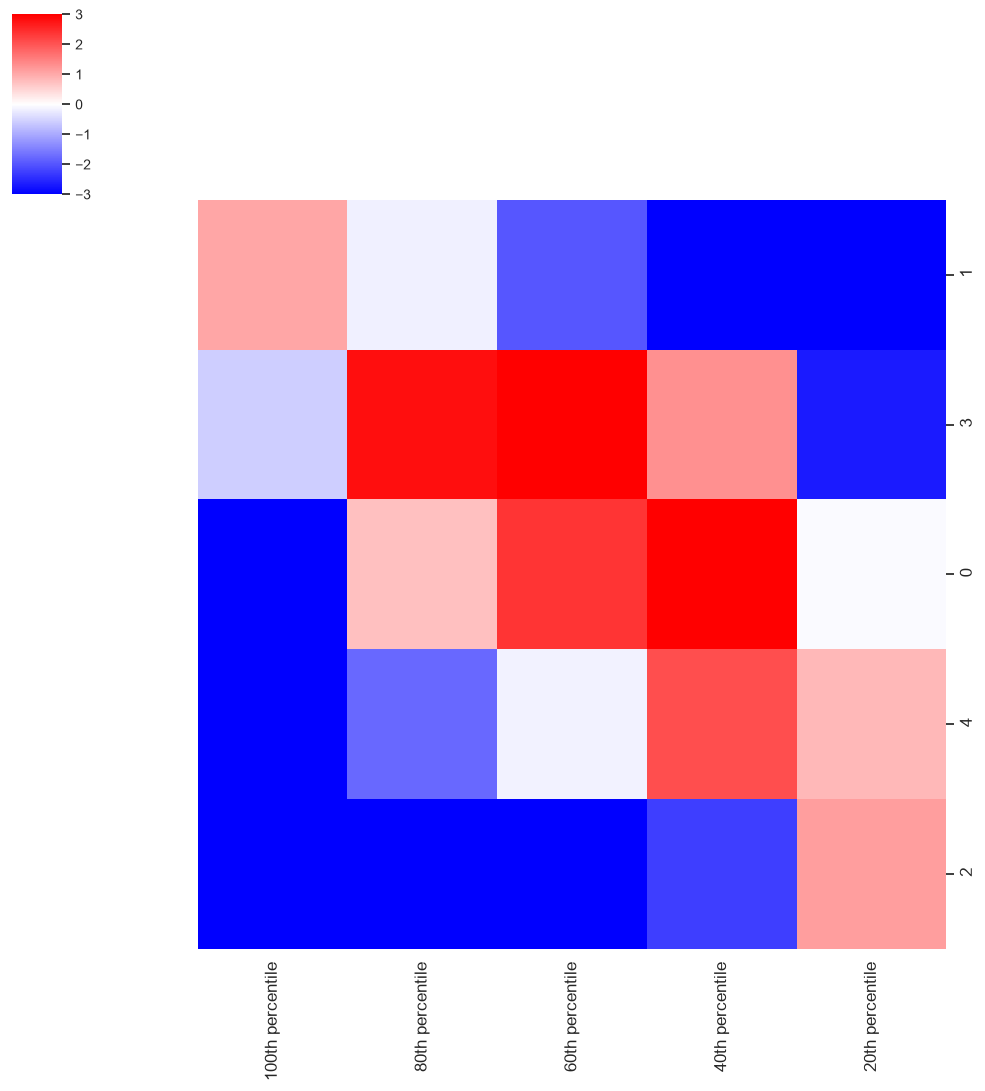

In [398]:
# ---------- compute tissue averages and fold-change ----------
values_sub = df_sub[sum_cols2].values
tissue_avgs = values_sub.mean(axis=0)  # shape (n_celltypes,)

eps = 1e-12
tissue_row = tissue_avgs.reshape(1, -1)
niche_plus = k_centroids[k] + tissue_row
row_sums = niche_plus.sum(axis=1, keepdims=True)
norm = niche_plus / (row_sums + eps)
fc_array = np.log2((norm + eps) / (tissue_row + eps))
fc = pd.DataFrame(fc_array, columns=sum_cols2)

# --------------------------
# New ordering logic: sort columns by percentile extracted from label (descending)
# If columns are categorical with ordered categories, respect that ordering.
# --------------------------

def extract_percentile_number(lbl):
    """
    Try to extract a meaningful integer percentile from a label string.
    Examples handled:
      - "20th percentile" -> 20
      - "P20" or "p20" -> 20
      - "20" -> 20
      - "Bin_3" or "bin 3" -> 3 (lower precedence)
    If no integer is found, returns None.
    """
    s = str(lbl)
    # primary: look for a clear percentile number (e.g., "20th", "20%")
    m = re.search(r'(\d{1,3})\s*(?:th|st|nd|rd)?\s*(?:%|\bpercentile\b)?', s, flags=re.IGNORECASE)
    if m:
        try:
            return int(m.group(1))
        except:
            pass
    # fallback: look for trailing number or Bin_x pattern
    m2 = re.search(r'bin[_\s]*(\d+)', s, flags=re.IGNORECASE)
    if m2:
        try:
            return int(m2.group(1))
        except:
            pass
    m3 = re.search(r'(\d+)$', s)
    if m3:
        try:
            return int(m3.group(1))
        except:
            pass
    return None

# Determine desired column order
# If fc.columns correspond to a categorical with ordered categories in the original df, try to use that
desired_col_order = None

# If original cluster_col in df is categorical and ordered, use that
if pd.api.types.is_categorical_dtype(df[cluster_col]):
    cat_cats = list(df[cluster_col].cat.categories)
    # Use only categories that overlap fc.columns, and preserve order
    desired_col_order = [c for c in cat_cats if c in fc.columns]

# If we didn't obtain an order from categorical metadata, parse numeric percentiles
if not desired_col_order:
    # build list of (col, pct_value) where pct_value may be None
    parsed = [(c, extract_percentile_number(c)) for c in fc.columns]
    # columns with numeric extraction come first, sorted descending by number
    nums = [c for c, v in parsed if v is not None]
    nums_sorted = sorted(nums, key=lambda c: extract_percentile_number(c), reverse=True)
    # non-parsable columns go to the end in original order
    non_nums = [c for c, v in parsed if v is None]
    desired_col_order = nums_sorted + non_nums

# Fallback if nothing matched (shouldn't happen)
if len(desired_col_order) == 0:
    desired_col_order = list(fc.columns)

# reindex fc columns accordingly
fc = fc.reindex(columns=desired_col_order)

# decide the high_bin (left-most column) for ordering rows
high_bin = desired_col_order[0]

# compute row ordering by descending enrichment in the chosen high_bin
ordered_rows = fc[high_bin].sort_values(ascending=False).index.tolist()
fc = fc.reindex(index=ordered_rows)

# --------------------------
# Deterministic ordering using a weighted score on normalized cluster centroids
# Updated to support percentile-style labels (e.g., "20th percentile", "100th percentile")
# --------------------------

import re
import numpy as np
import pandas as pd

# 0) centroids: ensure niche_clusters and sum_cols2 exist
niche_clusters = k_centroids[k]
cent_df = pd.DataFrame(niche_clusters, columns=sum_cols2)  # raw centroids, index = cluster id (0..n-1)

# normalize rows to sum=1 if not already normalized
cent_norm = cent_df.div(cent_df.sum(axis=1) + 1e-12, axis=0)

# Helper: extract integer percentile (or fallback integer) from label, else None
def extract_pct_int(label):
    s = str(label)
    # try phrases like "20th percentile", "20%", "100th", "P20"
    m = re.search(r'(\d{1,3})\s*(?:th|st|nd|rd)?\s*(?:%|\s*percentile\b)?', s, flags=re.IGNORECASE)
    if m:
        try:
            return int(m.group(1))
        except:
            pass
    # fallback: Bin_#
    m2 = re.search(r'bin[_\s]*(\d+)', s, flags=re.IGNORECASE)
    if m2:
        try:
            return int(m2.group(1))
        except:
            pass
    # final fallback: trailing integer
    m3 = re.search(r'(\d+)$', s)
    if m3:
        try:
            return int(m3.group(1))
        except:
            pass
    return None

# 1) Determine desired column order from cent_norm.columns (which should equal sum_cols2)
parsed = [(c, extract_pct_int(c)) for c in cent_norm.columns]

# columns with parsed integer percentiles, sorted descending (so 100 -> 80 -> ...)
cols_with_nums = [c for c, v in parsed if v is not None]
cols_with_nums_sorted = sorted(cols_with_nums, key=lambda c: extract_pct_int(c), reverse=True)

# columns without parsed numbers preserve original relative order and are appended at end
cols_without_nums = [c for c, v in parsed if v is None]

desired_col_order = cols_with_nums_sorted + cols_without_nums

# safety: ensure only existing columns and keep unique
desired_col_order = [c for i, c in enumerate(desired_col_order) if c in cent_norm.columns and c not in desired_col_order[:i]]

# 2) Define exponentially decreasing weights so left-most / highest percentile dominates
base = 2.0
n_cols = len(desired_col_order)
if n_cols == 0:
    raise ValueError("No columns found in centroids to score. Check sum_cols2 / centroids.")
weights = {col: base ** (n_cols - 1 - i) for i, col in enumerate(desired_col_order)}
weight_vector = np.array([weights[c] for c in desired_col_order], dtype=float)

# 3) Compute weighted score for each cluster centroid (rows align with cent_norm.index)
#    Use only the columns in desired_col_order (cent_norm columns already match).
score_vec = cent_norm[desired_col_order].values.dot(weight_vector)

# 4) Build ordering DataFrame for lexicographic tie-break (score descending, then centroid values)
order_df = pd.DataFrame(index=cent_norm.index)
order_df["score"] = score_vec

# append negative centroid values so that larger centroid values sort earlier (descending)
for c in desired_col_order:
    order_df[f"cent_{c}"] = -cent_norm[c].values

# stable sort by score then lexicographic centroid columns
sort_cols = ["score"] + [f"cent_{c}" for c in desired_col_order]
order_df = order_df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols), kind="mergesort")

ordered_rows = order_df.index.tolist()  # cluster row indices ordered by weighted score (descending)

# 5) Reindex fc using this ordering for rows and ensure columns follow desired_col_order
#    If fc doesn't contain all desired_col_order columns (unlikely), keep fc's columns plus missing ones at end
cols_to_use = [c for c in desired_col_order if c in fc.columns]
remaining_fc_cols = [c for c in fc.columns if c not in cols_to_use]
final_cols = cols_to_use + remaining_fc_cols

# Reindex fc (rows = ordered cluster ids, columns = final_cols)
fc = fc.reindex(index=ordered_rows, columns=final_cols)

# 6) Ensure numeric dtype and fill NaNs if any
fc = fc.astype(float)
if fc.isnull().any().any():
    fc = fc.fillna(-999.0)

# 7) Plot clustermap (no clustering)
s = sns.clustermap(
    fc,
    vmin=-3,
    vmax=3,
    cmap='bwr',
    figsize=(10, 10),
    xticklabels=True,
    yticklabels=[str(i) for i in fc.index],
    row_cluster=False,
    col_cluster=False
)

plt.setp(s.ax_heatmap.get_xticklabels(), fontsize=12, rotation=90)
plt.setp(s.ax_heatmap.get_yticklabels(), fontsize=12)
if s.cax is not None:
    s.cax.tick_params(labelsize=10)

# 8) Prepare neighborhood list for subsequent spatial plotting: top-N by weighted score
top_n = min(clusters, len(ordered_rows))
neigh_list = ordered_rows[:top_n]

# Print summary for transparency
print("Desired column order (left->right):", final_cols)
print("Top neighborhoods (by weighted score):", neigh_list)
print(neigh_list)
print(top_n)
order_df


In [399]:
n_conversion_20 = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
}


df_sub['Probability_Bin_Cluster'] = df_sub[neighborhood_name].map(n_conversion_20)
df_sub

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,...,20th percentile,40th percentile,60th percentile,80th percentile,100th percentile,Cell Type,Community,Tissue Unit,Neighborhood20,Probability_Bin_Cluster
0,205.045310,1322.758766,1,A,1,A,1.000000e+00,4.688047e-35,1.000000e+09,20.723266,...,0,0,0,0,1,1,None,None,1,1
1,1067.469050,599.405782,1,B,3,B,6.947284e-22,1.000000e+00,1.000000e-09,-20.723266,...,1,0,0,0,0,3,None,None,2,2
2,1403.731354,537.997025,1,B,7,B,5.388206e-42,1.000000e+00,1.000000e-09,-20.723266,...,1,0,0,0,0,7,None,None,2,2
3,852.773516,221.099842,1,B,5,A,2.473254e-02,9.752675e-01,2.535975e-02,-3.674592,...,0,0,1,0,0,5,None,None,0,0
4,334.383767,695.634156,1,A,8,A,1.000000e+00,3.236220e-25,1.000000e+09,20.723266,...,0,0,0,0,1,8,None,None,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,249.115136,951.748081,1,A,1,A,1.000000e+00,6.979748e-19,1.000000e+09,20.723266,...,0,0,0,0,1,1,None,None,1,1
5996,549.116242,473.522407,1,A,5,A,1.000000e+00,7.311181e-10,5.776613e+08,20.174498,...,0,0,0,0,1,5,None,None,3,3
5997,1197.595965,39.215769,1,B,8,B,4.363995e-09,1.000000e+00,5.363995e-09,-19.043557,...,1,0,0,0,0,8,None,None,4,4
5998,1158.096675,1144.550616,1,B,5,B,2.713362e-24,1.000000e+00,1.000000e-09,-20.723266,...,1,0,0,0,0,5,None,None,2,2


In [400]:
loaded_palette_hex = {0: '#e41a1c',
 1: '#377eb8',
 2: '#4daf4a',
 3: '#984ea3',
 4: '#ff7f00',
 5: '#ffff33',
 6: '#a65628',
 7: '#f781bf',
 8: '#999999',
 9: '#e41a1c'}

In [401]:
df_probabilities['unique_region'] = cells.obs['unique_region']
df_probabilities['x'] = cells.obs['x']
df_probabilities['y'] = cells.obs['y']

plot cell type distributions across the gradient 

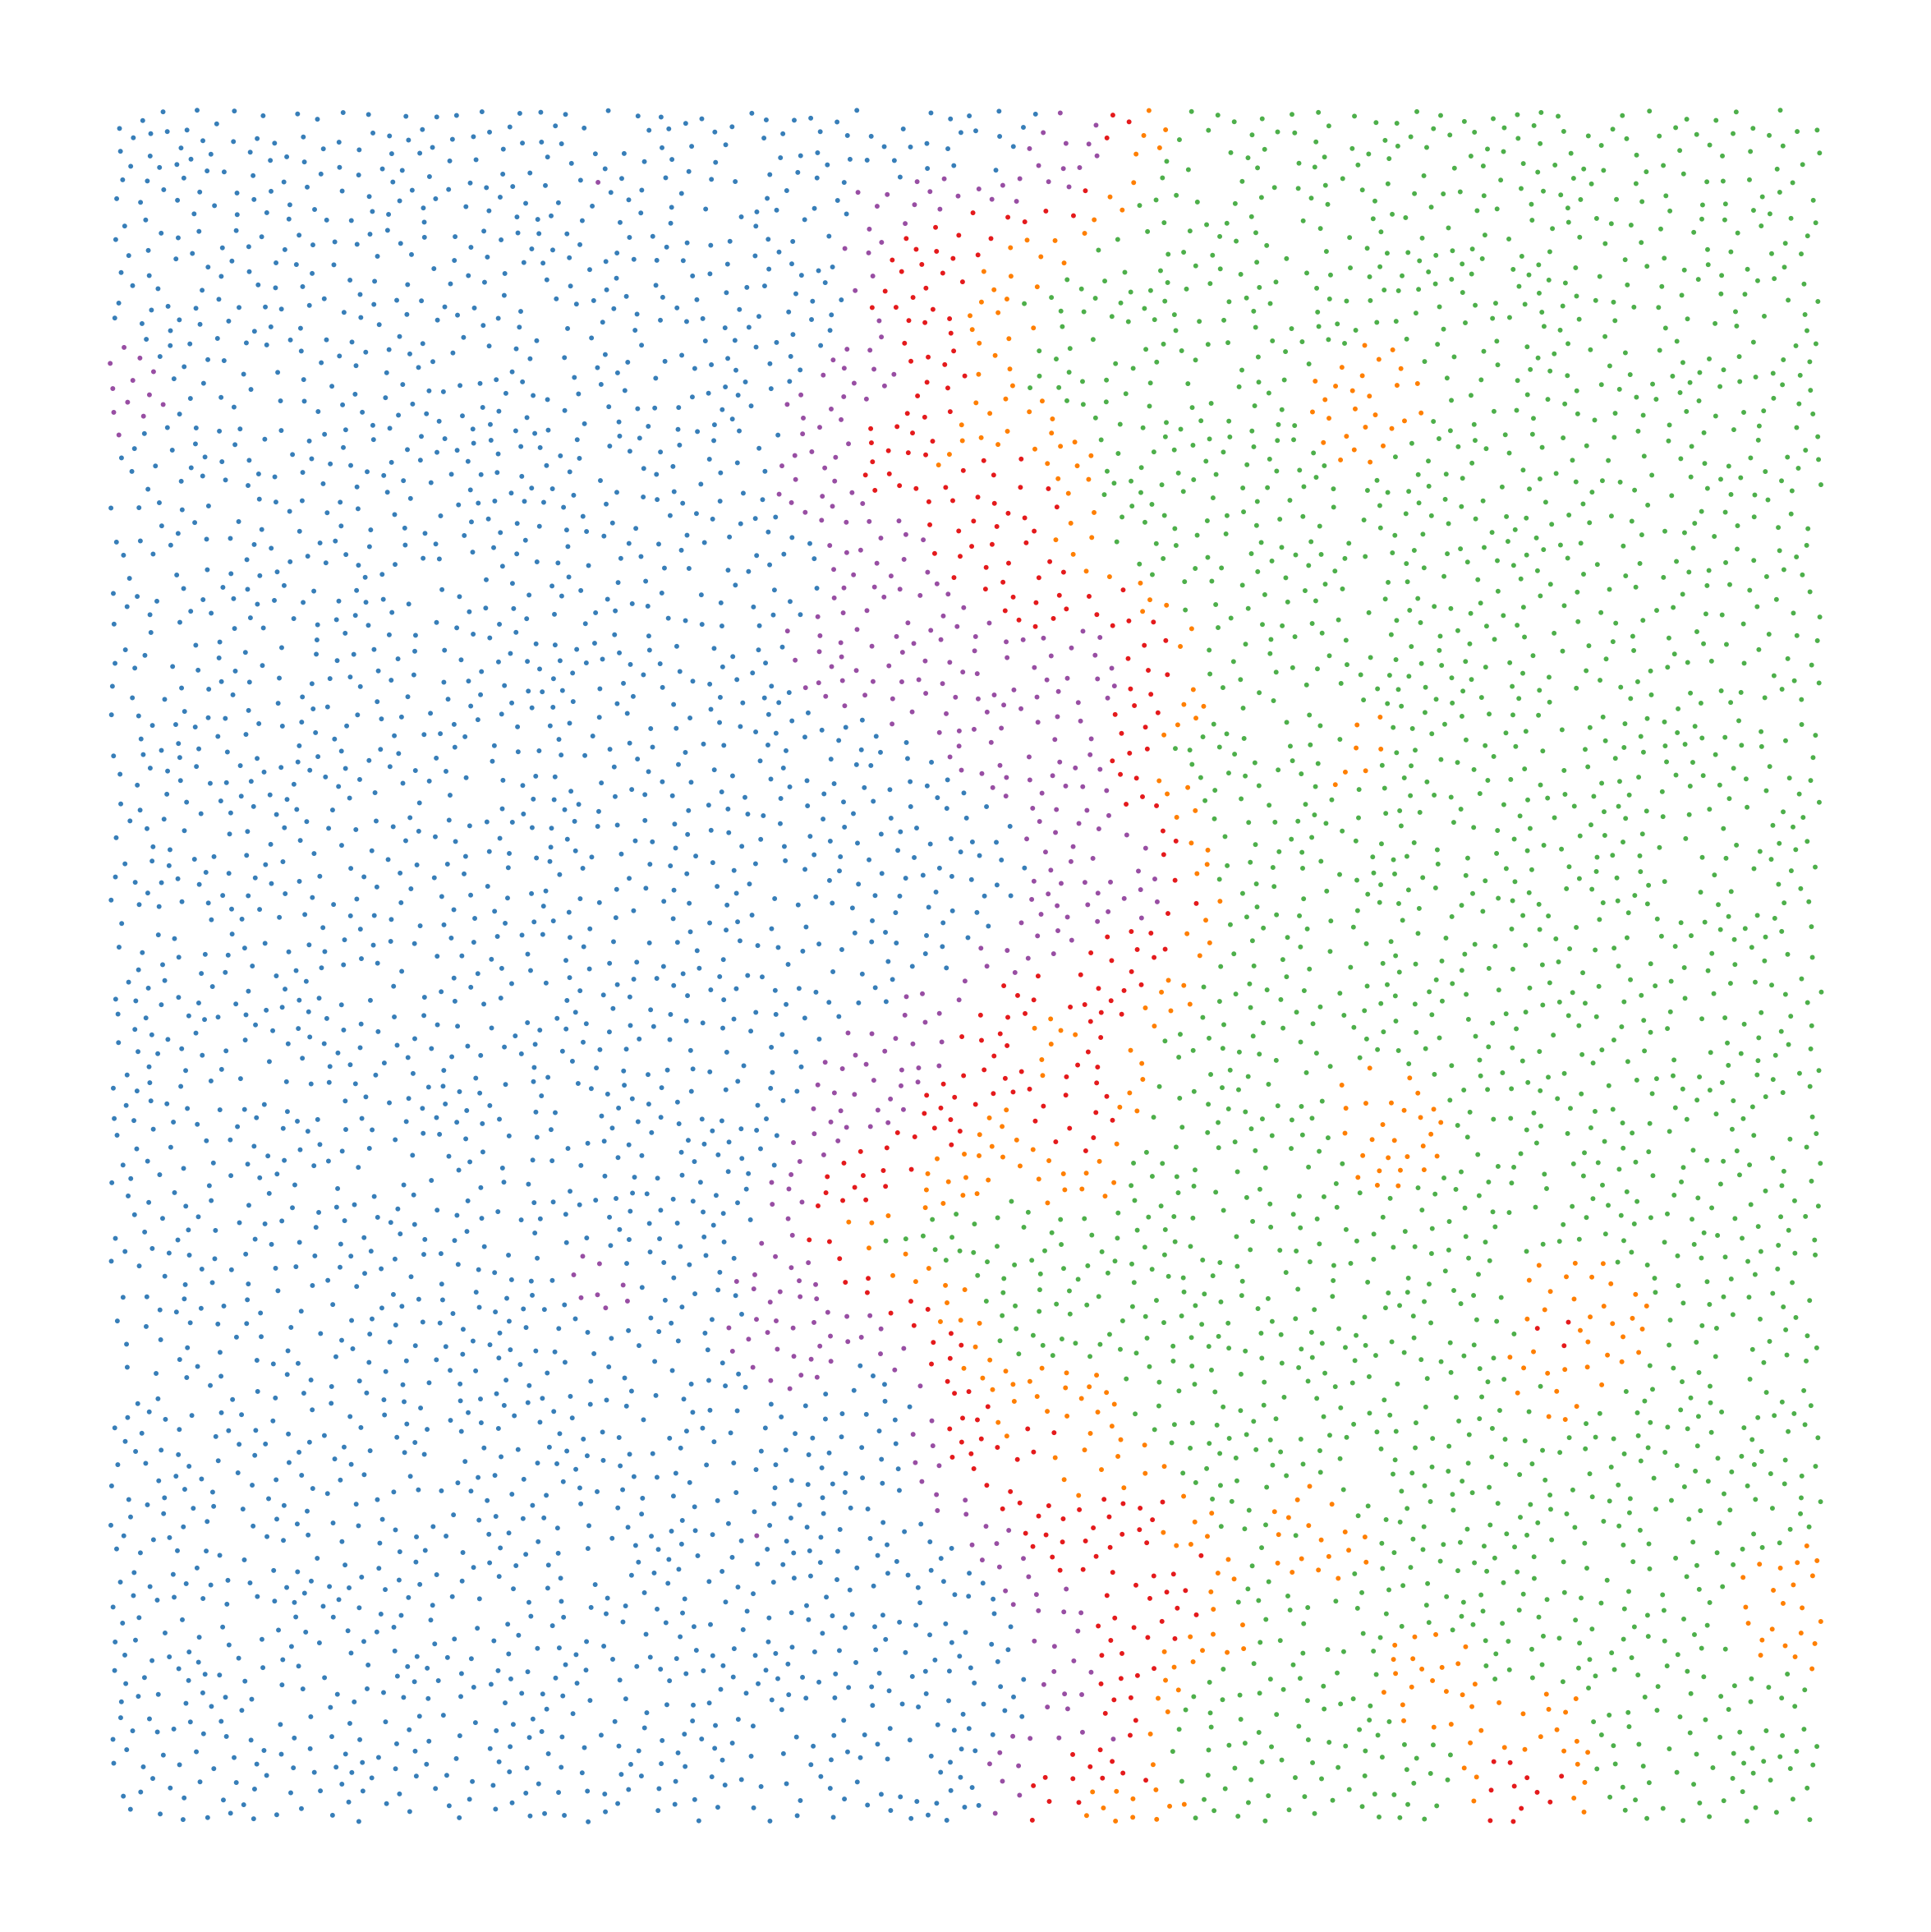

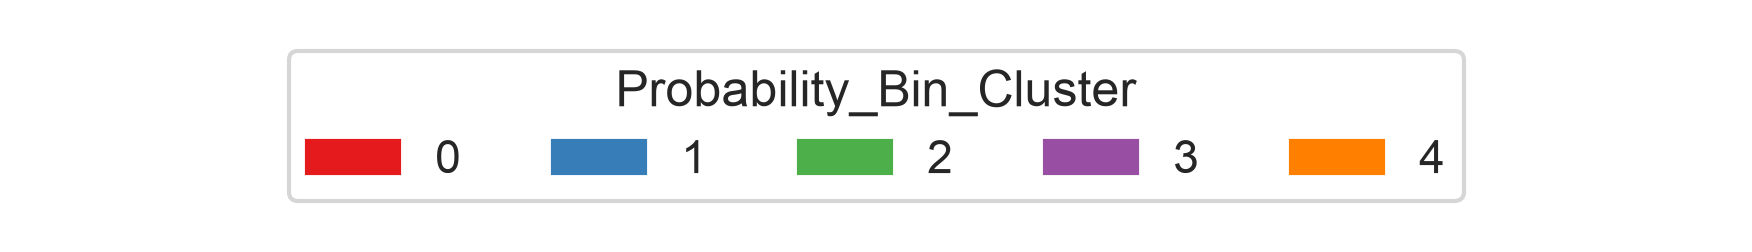

Region plotted: 1
Background cells from df: 0
Colored cells from total_df: 6000


In [402]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------- User settings ----------------
target_region = '1'
neigh_inner = 'A'
neigh_outer = 'B'

cluster_col_total = 'Probability_Bin_Cluster'   # exists ONLY in total_df
palette = loaded_palette_hex                    # your palette list

dpi_val = 300
marker_size_bg = 2
marker_size_high = 2      # slightly larger but can change
alpha_bg = 0.5
alpha_high = 1

bg_color = 'lightgray'     # background df points
round_dec = 4              # for coordinate dedup
# ------------------------------------------------

# Defensive copies
df_all = df_probabilities.copy()
total = df_sub.copy()

# 1) Subset region for df (BACKGROUND)
region_df = df_all[df_all['unique_region'] == target_region].copy()

# 2) Subset region for inner/outer follicle (the colored points)
colored_df = total[
    (total['unique_region'] == target_region) &
    (total['Neighborhood'].isin([neigh_inner, neigh_outer]))
].copy()

# 3) Build cluster color map from total_df clusters only
cluster_vals = sorted(colored_df[cluster_col_total].dropna().unique())
color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(cluster_vals)}

# 4) Deduplicate (remove colored cells from df)
id_cols = ['cell_id', 'cellID', 'CellID', 'unique_cell_id', 'uid', 'id']
id_col = next((c for c in id_cols if c in colored_df.columns and c in region_df.columns), None)

if id_col is not None:
    colored_ids = set(colored_df[id_col].dropna().astype(str))
    mask_colored_in_region = region_df[id_col].astype(str).isin(colored_ids)

elif set(colored_df.index).issubset(set(region_df.index)):
    mask_colored_in_region = region_df.index.isin(colored_df.index)

else:
    # fallback: match by rounded coordinates
    if {'x', 'y'}.issubset(colored_df.columns) and {'x', 'y'}.issubset(region_df.columns):
        colored_xy = set(zip(
            np.round(colored_df['x'].astype(float), round_dec),
            np.round(colored_df['y'].astype(float), round_dec)
        ))
        region_xy = list(zip(
            np.round(region_df['x'].astype(float), round_dec),
            np.round(region_df['y'].astype(float), round_dec)
        ))
        mask_colored_in_region = pd.Series([xy in colored_xy for xy in region_xy], index=region_df.index)
    else:
        mask_colored_in_region = pd.Series(False, index=region_df.index)

background_df = region_df.loc[~mask_colored_in_region].copy()

# 5) Apply colors based on cluster
def cluster_to_color(series):
    return series.map(color_map).fillna(bg_color)

colored_df['plot_color'] = cluster_to_color(colored_df[cluster_col_total])

# 6) PLOT (NO LEGEND, NO OUTLINES)
fig, ax = plt.subplots(figsize=(8, 8), dpi=dpi_val)

# Background gray
if not background_df.empty:
    ax.scatter(
        background_df['x'], background_df['y'],
        c=bg_color,
        s=marker_size_bg,
        alpha=alpha_bg,
        linewidths=0,
        edgecolors='none'
    )

# Colored inner/outer (plotted on top)
ax.scatter(
    colored_df['x'],
    colored_df['y'],
    c=colored_df['plot_color'],
    s=marker_size_high,
    alpha=alpha_high,
    linewidths=0,       # ← NO outlines
    edgecolors='none'   # ← explicitly no edge
)

ax.axis('off')
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

# 7) (Optional) Separate cluster legend
patches = [Patch(color=color_map[cl], label=str(cl)) for cl in cluster_vals]
fig_leg, ax_leg = plt.subplots(figsize=(6, 0.4 + len(patches)*0.12), dpi=dpi_val)
ax_leg.axis('off')
ax_leg.legend(handles=patches, title='Probability_Bin_Cluster', loc='center', ncol=min(8, len(patches)))
plt.tight_layout()
plt.show()

# Summary
print(f"Region plotted: {target_region}")
print(f"Background cells from df: {len(background_df)}")
print(f"Colored cells from total_df: {len(colored_df)}")


In [403]:
df = df_probabilities
total_df= df_sub

In [404]:
import anndata as ad
import mingl as mg
import pandas as pd

# Build AnnData from the existing dataframe used in this section
df_for_gb = total_df.copy()

cluster_key_gb = 'Probability_Bin_Cluster'
if cluster_key_gb not in df_for_gb.columns:
    raise KeyError(
        f"Missing '{cluster_key_gb}' in total_df."
    )

required_cols = ['Score', 'Neighborhood', 'unique_region', 'x', 'y']
missing = [c for c in required_cols if c not in df_for_gb.columns]
if missing:
    raise KeyError(f"Missing required columns for mg.tl.gb: {missing}")

adata_gb = ad.AnnData(obs=df_for_gb.copy())
adata_gb.obs_names = adata_gb.obs.index.astype(str)

region_value_gb = '1'




/opt/miniconda3/envs/mingl-env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


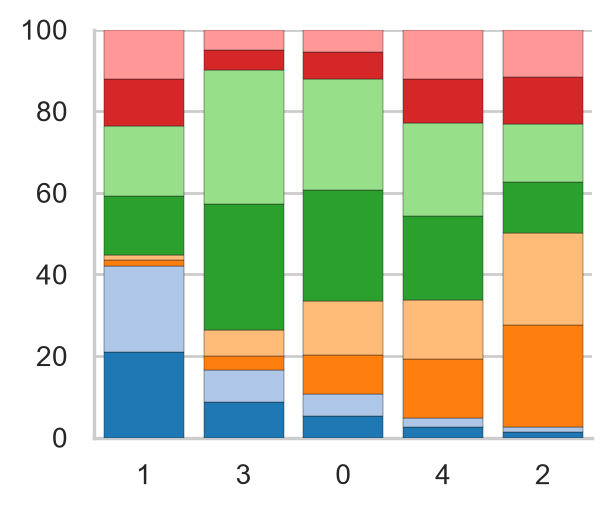

  cluster  weighted_prop  total
0       1      11.094564   2686
1       3       4.339241    395
2       0       3.686154    325
3       4       2.732187    407
4       2       1.543667   2187


In [405]:
import anndata as ad
import mingl as mg

adata_for_pl = adata_gb.copy()

if 'Probability_Bin_Cluster' not in adata_for_pl.obs.columns:
    raise KeyError("Missing 'Probability_Bin_Cluster' in adata_for_pl.obs.")

fig, ax, rank_df, combined_perc = mg.pl.cell_type_distributions(
    adata_for_pl,
    neighborhoods_to_plot=("A", "B"),
    min_cells=0,
    cluster_key="Probability_Bin_Cluster",
    score_key="Score",
    cell_type_key="Cell Type",
    neighborhood_key="Neighborhood",
    store_key="inner_outer_combined_stacked",
    return_fig=True,
)

print(rank_df.head(20))


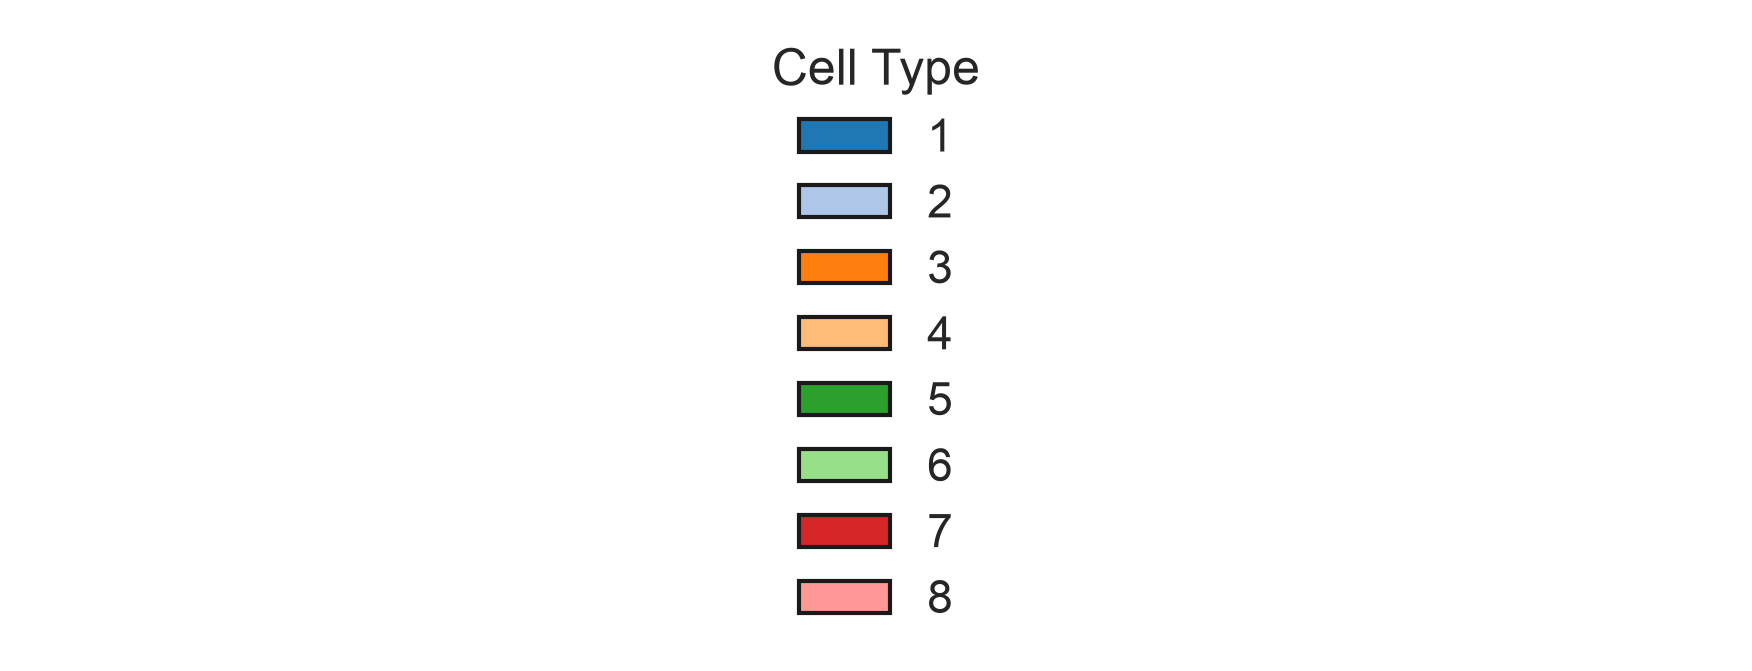

In [406]:
# Legend compatible with mg.pl.cell_type_distributions output/colors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

store_key = "inner_outer_combined_stacked"
cell_type_key = "cell_type"

# Use exactly the same ordered cell types the plotting function used (if stored)
if store_key in adata_for_pl.uns and "cell_types" in adata_for_pl.uns[store_key]:
    cell_types = list(adata_for_pl.uns[store_key]["cell_types"])
else:
    # Fallback: same ordering logic as mg.pl.cell_type_distributions
    cell_types = sorted(adata_for_pl.obs[cell_type_key].dropna().astype(str).unique())

# Rebuild the same palette sequence used in mg.pl.cell_type_distributions
palette_names = ["tab20", "Set3", "Set2", "Paired", "Dark2", "Accent"]
combined_colors = []
for name in palette_names:
    combined_colors.extend(sns.color_palette(name))

if len(combined_colors) < len(cell_types):
    raise ValueError(f"Not enough distinct colors for {len(cell_types)} cell types.")

color_dict = dict(zip(cell_types, combined_colors[:len(cell_types)]))

# Draw legend-only figure
fig_h = max(2.0, 0.22 * len(cell_types))
fig, ax = plt.subplots(figsize=(6, fig_h), dpi=300)
handles = [mpatches.Patch(facecolor=color_dict[ct], edgecolor="k", label=ct) for ct in cell_types]
ax.legend(handles=handles, loc="center", frameon=False, ncol=1, title="Cell Type")
ax.axis("off")
plt.tight_layout()
plt.show()


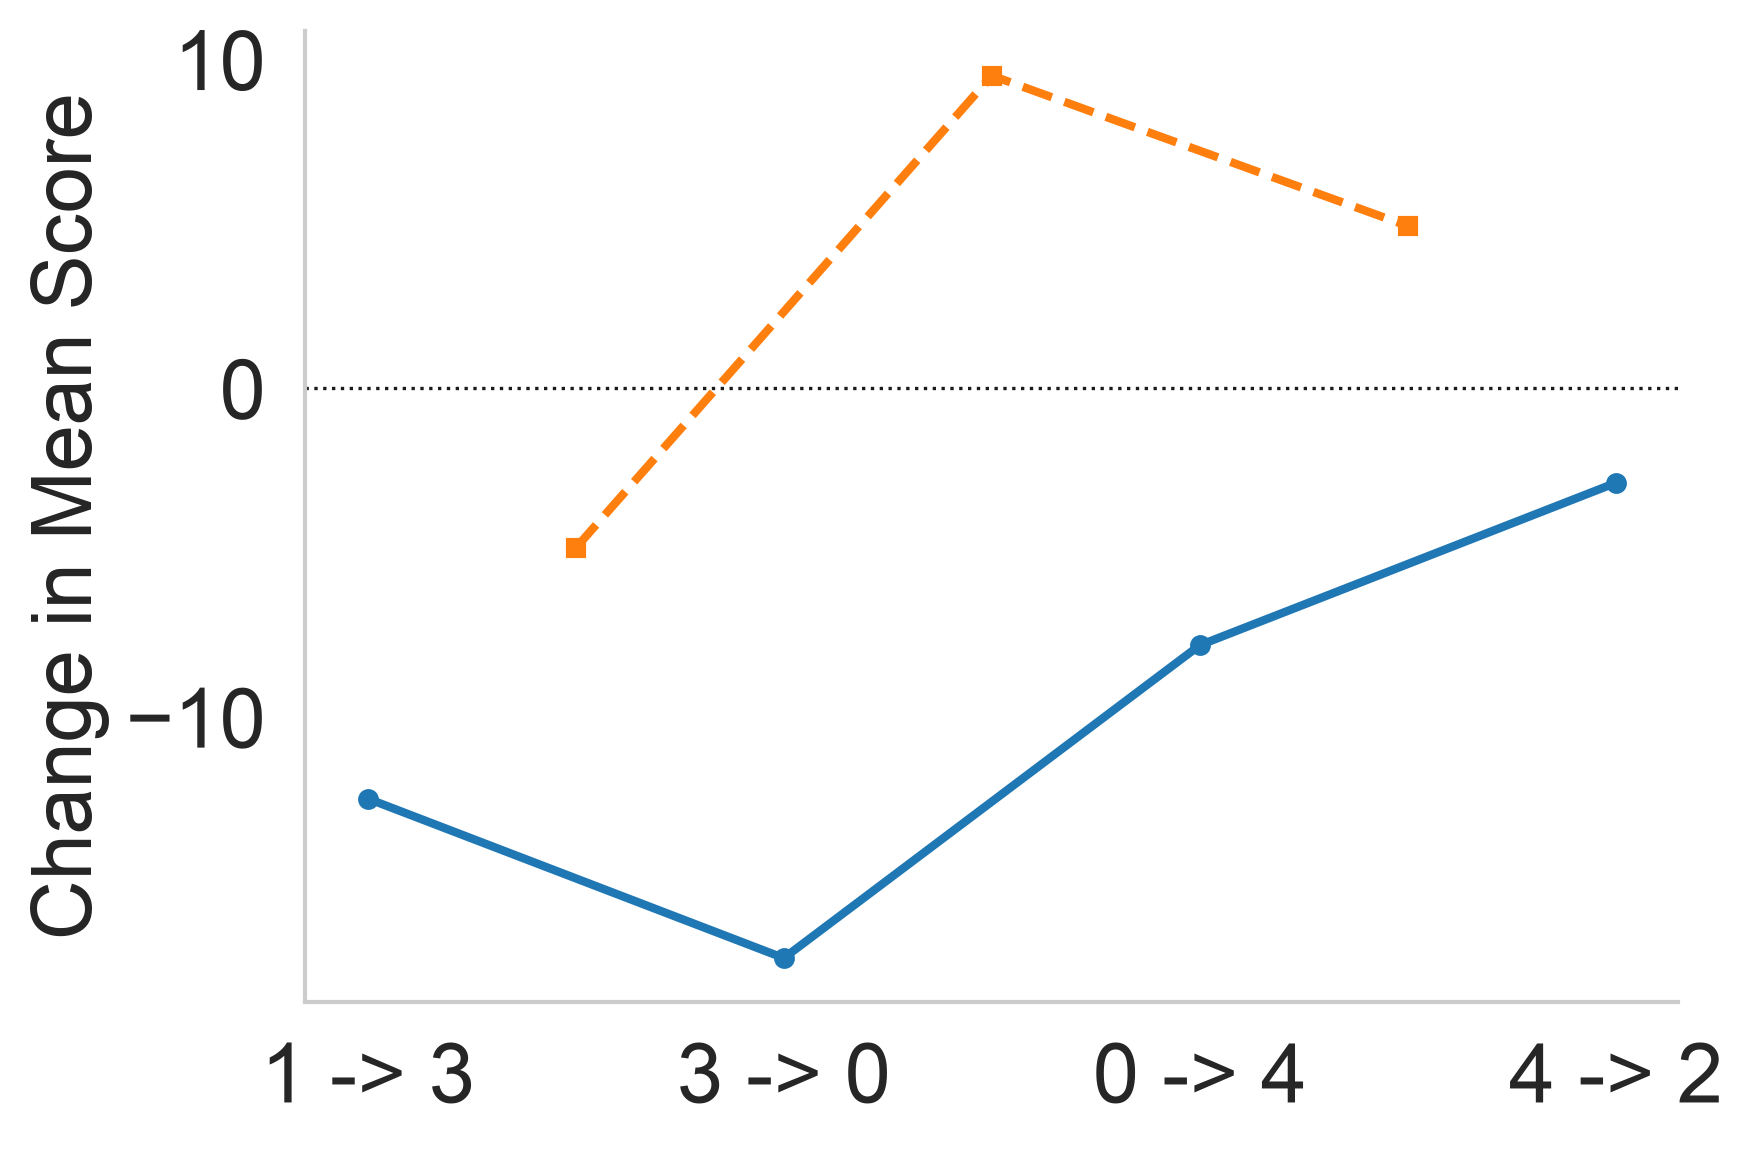

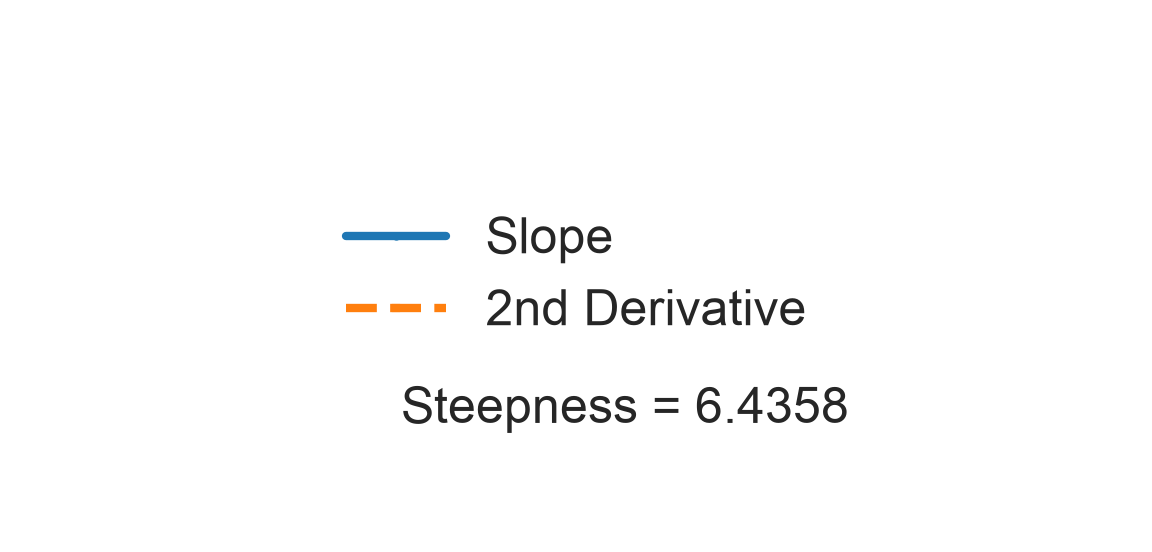

Clusters plotted (order): ['1', '3', '0', '4', '2']
First derivative (Δ mean score): [-12.472334 -17.323316  -7.806378  -2.866826]
Second derivative (Δ of Δ): [-4.850982  9.516938  4.939551]
Global slope = -10.6067
Normalized slope (slope / IQR) = 0.255914 IQR/cluster
Steepness (mean |2nd derivative| / IQR) = 6.43582


In [407]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import pandas as pd

# --------------------------------------------------
# Resolve dataframe/columns in this notebook context
# --------------------------------------------------
df_plot = total_df.copy()

cluster_col = 'Probability_Bin_Cluster'
score_col = 'Score'
n_bins = 5

if cluster_col not in df_plot.columns:
    raise KeyError(f"Missing '{cluster_col}' in dataframe.")

if score_col not in df_plot.columns:
    raise KeyError(f"Missing '{score_col}' in dataframe.")

# --------------------------------------------------
# Fallback cluster ordering helper (used only if needed)
# --------------------------------------------------
def _compute_cluster_order_score_weighted_local(df_in, cluster_col, score_col, n_bins=5):
    canonical_bins = ["Very Low", "Low", "Medium", "High", "Very High"]
    weights = {b: 2**i for i, b in enumerate(canonical_bins)}

    d = df_in.copy()
    d['cluster_str'] = d[cluster_col].astype(str).str.strip()

    s = pd.to_numeric(d[score_col], errors='coerce')
    if s.notna().any():
        try:
            mapped = pd.qcut(s, q=n_bins, labels=canonical_bins, duplicates='drop')
            d['_bin_mapped'] = mapped.astype(object)
        except Exception:
            v = s.dropna()
            if v.empty:
                d['_bin_mapped'] = "Medium"
            else:
                edges = np.linspace(float(v.min()), float(v.max()), n_bins + 1)
                u = np.unique(edges)
                labels_use = canonical_bins[:max(1, len(u) - 1)]
                d['_bin_mapped'] = pd.cut(s, bins=u, labels=labels_use, include_lowest=True).astype(object)
    else:
        d['_bin_mapped'] = "Medium"

    cluster_keys = sorted(d['cluster_str'].dropna().unique(), key=str)
    rows = []
    for cl in cluster_keys:
        sub = d[d['cluster_str'] == cl]
        n = len(sub)
        if n == 0:
            continue
        vc = sub['_bin_mapped'].value_counts(dropna=False).to_dict()
        props = {b: vc.get(b, 0) / n for b in canonical_bins}
        weighted_prop = sum(props[b] * weights[b] for b in canonical_bins)
        rows.append({'cluster': cl, 'weighted_prop': weighted_prop, 'total': n})

    rank_df_local = pd.DataFrame(rows).sort_values(['weighted_prop', 'total'], ascending=[False, False]).reset_index(drop=True)
    return rank_df_local['cluster'].tolist()

# --------------------------------------------------
# Ensure ordered clusters exist
# --------------------------------------------------
ordered_clusters = [str(x) for x in _compute_cluster_order_score_weighted_local(df_plot, cluster_col, score_col, n_bins=n_bins)]

# --------------------------------------------------
# Compute mean score per cluster IN THAT ORDER
# --------------------------------------------------
agg = df_plot.groupby(df_plot[cluster_col].astype(str))[score_col].mean()
clusters_in_plot = [c for c in ordered_clusters if c in agg.index]
means = agg.loc[clusters_in_plot].values.astype(float)

n = len(means)
if n < 2:
    raise ValueError("Need at least 2 clusters to compute derivatives.")

# --------------------------------------------------
# Global slope (for reference only)
# --------------------------------------------------
X = np.arange(n).reshape(-1, 1)
y = means#.reshape(-1, 1)
lr = LinearRegression().fit(X, y)
slope = float(lr.coef_[0])

score_vals = pd.to_numeric(df_plot[score_col], errors='coerce').dropna().values
q1, q3 = np.percentile(score_vals, [25, 75])
iqr = max(1e-8, q3 - q1)
slope_norm = abs(slope) / iqr

# --------------------------------------------------
# First and second derivatives (RAW — NO NORMALIZATION)
# --------------------------------------------------
fd = np.diff(means)
sd = np.diff(fd) if len(fd) >= 2 else np.array([])

# --------------------------------------------------
# Steepness calculation updated:
# mean absolute second derivative
# --------------------------------------------------
if sd.size:
    steepness = float(np.mean(np.abs(sd)))
else:
    steepness = float('nan')

# X-axis labels (cluster-to-cluster changes)
labels_fd = [
    f"{clusters_in_plot[i]} -> {clusters_in_plot[i+1]}"
    for i in range(len(fd))
]

# X positions
x_fd = np.arange(len(fd))
x_sd = x_fd[:len(sd)] + 0.5

# --------------------------------------------------
# Main plot (clean)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(
    x_fd, fd,
    marker='o', markersize=4,
    linewidth=2,
    color='#1f77b4',
    label='Slope'
)

if sd.size:
    ax.plot(
        x_sd, sd,
        marker='s', markersize=4,
        linewidth=2,
        linestyle='--',
        color='#ff7f0e',
        label='2nd Derivative'
    )

# Zero reference
ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

# Axes & labels
ax.set_xticks(x_fd)
ax.set_xticklabels(labels_fd, rotation=0, ha='center', fontsize=20)
ax.set_ylabel('Change in Mean Score', fontsize=20)

# Aesthetics: NO GRID, only left & bottom spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Separate legend figure (small markers, clean)
# --------------------------------------------------
legend_handles = [
    Line2D([0], [0], color='#1f77b4', lw=2, marker='o', markersize=1,
           label='Slope'),
    Line2D([0], [0], color='#ff7f0e', lw=2, linestyle='--', marker='s', markersize=1,
           label='2nd Derivative')
]

legend_text = f"Steepness = {steepness:.4f}"

fig_leg, ax_leg = plt.subplots(figsize=(4, 2), dpi=300)
ax_leg.axis('off')

ax_leg.legend(
    handles=legend_handles,
    loc='center',
    frameon=False,
    fontsize=12,
    handlelength=2.0
)

ax_leg.text(
    0.75, 0.18,
    legend_text,
    ha='right', va='bottom',
    transform=ax_leg.transAxes,
    fontsize=12
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Console summary
# --------------------------------------------------
print('Clusters plotted (order):', clusters_in_plot)
print('First derivative (Δ mean score):', np.round(fd, 6))
if sd.size:
    print('Second derivative (Δ of Δ):', np.round(sd, 6))
print(f'Global slope = {slope:.6g}')
print(f'Normalized slope (slope / IQR) = {slope_norm:.6g} IQR/cluster')
print(f'Steepness (mean |2nd derivative| / IQR) = {steepness:.6g}')


In [408]:
synthetic = pd.read_csv(CSV_PATH)

synthetic

,cell_id,x,y,cell_type,unique_region,true_organization,true_border,true_border_operational,signed_distance,distance_from_border,window_frac_B,Neighborhood
0,0,205.045310,1322.758766,1,1,A,False,False,-360.595662,360.595662,0.0,A
1,1,1067.469050,599.405782,3,1,B,False,False,342.480053,342.480053,1.0,B
2,2,1403.731354,537.997025,7,1,B,False,False,766.911903,766.911903,1.0,B
3,3,852.773516,221.099842,5,1,A,True,True,-6.514162,6.514162,0.5,B
4,4,334.383767,695.634156,8,1,A,False,False,-279.695707,279.695707,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5995,249.115136,951.748081,1,1,A,False,False,-489.723467,489.723467,0.0,A
5996,5996,549.116242,473.522407,5,1,A,True,False,-84.257436,84.257436,0.0,A
5997,5997,1197.595965,39.215769,8,1,B,False,False,285.656896,285.656896,1.0,B
5998,5998,1158.096675,1144.550616,5,1,B,False,False,405.807195,405.807195,1.0,B


In [409]:
recovered = cells
recovered 

AnnData object with n_obs × n_vars = 6000 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'true_border', 'true_border_operational', 'signed_distance', 'distance_from_border', 'window_frac_B', 'Neighborhood', 'Count_Above_Threshold'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [410]:
import seaborn as sns

cell_type_key = "cell_type"

# Ordered cell types
cell_types = sorted(
    recovered.obs[cell_type_key]
    .dropna()
    .astype(str)
    .unique()
)

# Same palette sequence used by mg.pl.cell_type_distributions
palette_names = [
    "tab20",
    "Set3",
    "Set2",
    "Paired",
    "Dark2",
    "Accent",
]

combined_colors = []

for palette in palette_names:
    combined_colors.extend(
        sns.color_palette(palette)
    )

if len(combined_colors) < len(cell_types):
    raise ValueError(
        f"Not enough colors for {len(cell_types)} cell types."
    )

color_dict = dict(
    zip(
        cell_types,
        combined_colors[:len(cell_types)]
    )
)

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


def compare_neighborhood_composition(
    recovered,
    color_dict,
    true_col="true_organization",
    recovered_col="Neighborhood",
    cell_type_col="cell_type",
):
    """
    Compare cell-type composition of true organizations vs recovered neighborhoods.
    """

    df = recovered.obs.copy()

    ####################################################
    # Composition tables
    ####################################################

    true_comp = pd.crosstab(
        df[true_col],
        df[cell_type_col],
        normalize="index"
    )

    recovered_comp = pd.crosstab(
        df[recovered_col],
        df[cell_type_col],
        normalize="index"
    )

    # ensure same order
    true_comp = true_comp.sort_index().sort_index(axis=1)
    recovered_comp = recovered_comp.reindex(
        index=true_comp.index,
        columns=true_comp.columns,
        fill_value=0
    )

    ####################################################
    # Figure 1
    # Side-by-side stacked bars
    ####################################################

    # Make sure colors follow the column order
    bar_colors = [
        color_dict[str(ct)]
        for ct in true_comp.columns
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,4),
        sharey=True,
    )

    true_comp.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        legend=False,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.3,
    )

    axes[0].set_title("True Organizations")
    axes[0].set_ylabel("Fraction")
    axes[0].set_xlabel("Organization")

    recovered_comp.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        legend=False,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.3,
    )

    axes[1].set_title("Recovered Neighborhoods")
    axes[1].set_xlabel("Neighborhood")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 2
    # Heatmap
    ####################################################

    heat = pd.concat(
        [
            true_comp.rename(
                index=lambda x: f"True {x}"
            ),
            recovered_comp.rename(
                index=lambda x: f"Recovered {x}"
            ),
        ]
    )

    plt.figure(figsize=(10,3))

    plt.imshow(
        heat.values,
        aspect="auto",
        cmap="viridis"
    )

    plt.xticks(
        np.arange(len(heat.columns)),
        heat.columns,
        rotation=90
    )

    plt.yticks(
        np.arange(len(heat.index)),
        heat.index
    )

    plt.colorbar(label="Fraction")

    plt.title("Cell-type Composition")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 3
    # Scatter
    ####################################################

    plt.figure(figsize=(5,5))

    xs = []
    ys = []

    for org in true_comp.index:

        plt.scatter(
            true_comp.loc[org],
            recovered_comp.loc[org],
            s=40,
            label=org,
        )

        xs.extend(true_comp.loc[org])
        ys.extend(recovered_comp.loc[org])

    lim = [
        0,
        max(max(xs), max(ys))*1.05
    ]

    plt.plot(
        lim,
        lim,
        "--k"
    )

    plt.xlim(lim)
    plt.ylim(lim)

    plt.xlabel("True Fraction")
    plt.ylabel("Recovered Fraction")

    plt.title("Recovered vs True Composition")

    plt.legend(title="Organization")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 4
    # Difference heatmap
    ####################################################

    diff = recovered_comp - true_comp

    plt.figure(figsize=(10,2))

    vmax = np.abs(diff.values).max()

    plt.imshow(
        diff.values,
        cmap="RdBu_r",
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )

    plt.xticks(
        np.arange(len(diff.columns)),
        diff.columns,
        rotation=90
    )

    plt.yticks(
        np.arange(len(diff.index)),
        diff.index
    )

    plt.colorbar(
        label="Recovered − True"
    )

    plt.title("Composition Difference")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Statistics
    ####################################################

    print("\nComposition Recovery\n")

    for org in true_comp.index:

        r, p = pearsonr(
            true_comp.loc[org],
            recovered_comp.loc[org]
        )

        rmse = np.sqrt(
            np.mean(
                (
                    true_comp.loc[org]
                    - recovered_comp.loc[org]
                )**2
            )
        )

        print(
            f"{org}: "
            f"Pearson r = {r:.4f}, "
            f"RMSE = {rmse:.4f}"
        )

    return {
        "true": true_comp,
        "recovered": recovered_comp,
        "difference": diff,
    }

In [412]:
import matplotlib.pyplot as plt

def make_legend(
    handles,
    title=None,
    figsize=(2.5,2),
    fontsize=9,
    ncols=1,
    columnspacing=0.8,
    handletextpad=0.4,
    handlelength=1.2,
    labelspacing=0.4,
):
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    ax.axis("off")

    ax.legend(
        handles=handles,
        title=title,
        frameon=False,
        loc="center",
        fontsize=fontsize,
        title_fontsize=fontsize,
        ncols=ncols,
        columnspacing=columnspacing,
        handletextpad=handletextpad,
        handlelength=handlelength,
        labelspacing=labelspacing,
    )

    plt.tight_layout()
    plt.show()

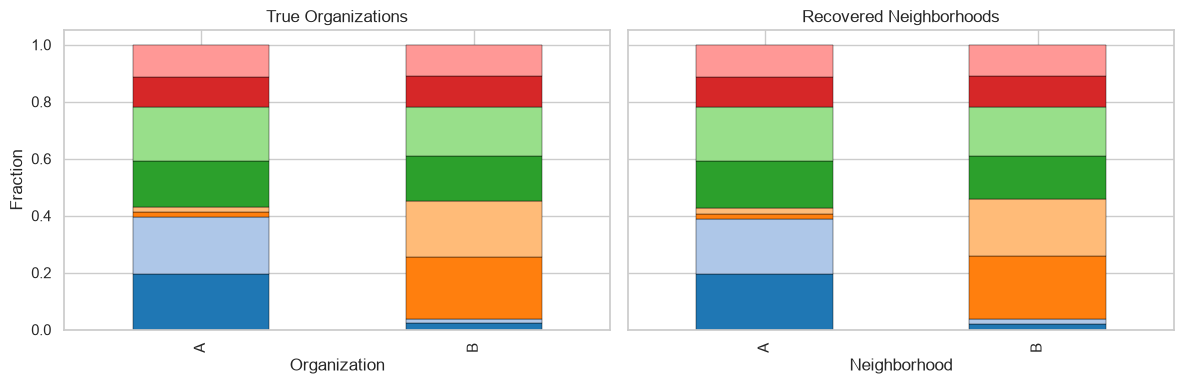

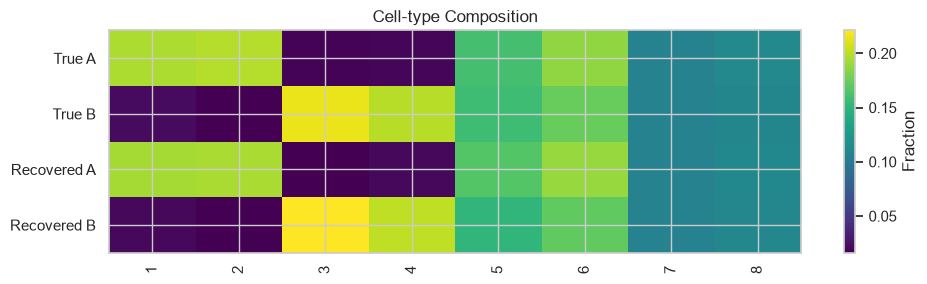

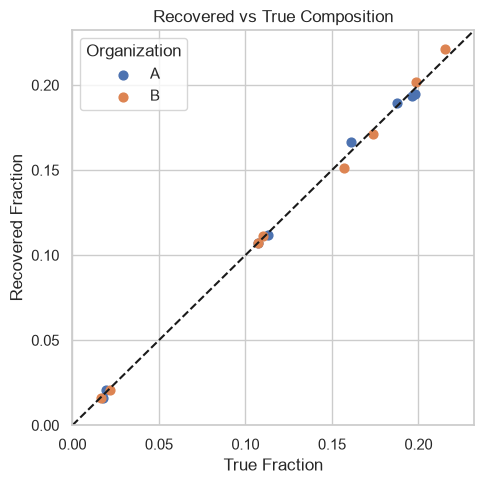

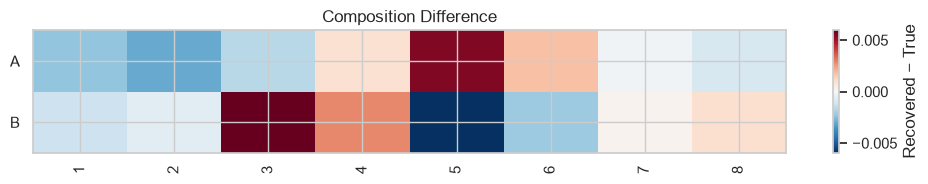


Composition Recovery

A: Pearson r = 0.9993, RMSE = 0.0026
B: Pearson r = 0.9991, RMSE = 0.0033


In [413]:
results = compare_neighborhood_composition(recovered, color_dict)

In [414]:
import numpy as np
import matplotlib.pyplot as plt


def plot_composition_scatter(
    metrics,
    true_comp,
    recovered_comp,
    color_dict,
):
    """
    Scatter plot comparing true vs recovered cell-type proportions.

    Marker shape = organization
    Marker color = cell type
    """

    fig, ax = plt.subplots(
        figsize=(6,6),
        dpi=300
    )

    ####################################################
    # Marker styles
    ####################################################

    markers = {
        "A": "s",   # square
        "B": "o",   # circle
    }

    xs = []
    ys = []

    ####################################################
    # Scatter
    ####################################################

    for org in true_comp.index:

        for ct in true_comp.columns:

            x = true_comp.loc[org, ct]
            y = recovered_comp.loc[org, ct]

            xs.append(x)
            ys.append(y)

            ax.scatter(
                x,
                y,
                s=80,
                marker=markers[org],
                color=color_dict[str(ct)],
                edgecolor="black",
                linewidth=0.5,
                zorder=3,
            )

    ####################################################
    # Identity line
    ####################################################

    lim = [
        0,
        max(max(xs), max(ys)) * 1.05,
    ]

    ax.plot(
        lim,
        lim,
        "--",
        color="black",
        linewidth=1,
    )

    ax.set_xlim(lim)
    ax.set_ylim(lim)

    ####################################################
    # Labels
    ####################################################

    ax.set_xlabel(
        "True Cell-Type Proportion",
        fontsize=12,
    )

    ax.set_ylabel(
        "Recovered Cell-Type Proportion",
        fontsize=12,
    )

    ax.set_title(
        "Recovered vs True Cell-Type Composition",
        fontsize=14,
    )

    ####################################################
    # Summary statistics
    ####################################################

    mean_r = metrics["Pearson_r"].mean()
    mean_r2 = metrics["R2"].mean()
    mean_rmse = metrics["RMSE"].mean()
    mean_mae = metrics["MAE"].mean()
    mean_js = metrics["Jensen_Shannon"].mean()
    mean_max = metrics["Max_Absolute_Error"].mean()

    stats_text = (
        f"Mean Pearson r = {mean_r:.3f}\n"
        f"Mean $R^2$ = {mean_r2:.3f}\n"
        f"Mean RMSE = {mean_rmse:.4f}\n"
        f"Mean MAE = {mean_mae:.4f}\n"
        f"Mean JS = {mean_js:.4f}\n"
        f"Max Error = {mean_max:.4f}"
    )

    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=15,
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.9,
        ),
    )

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

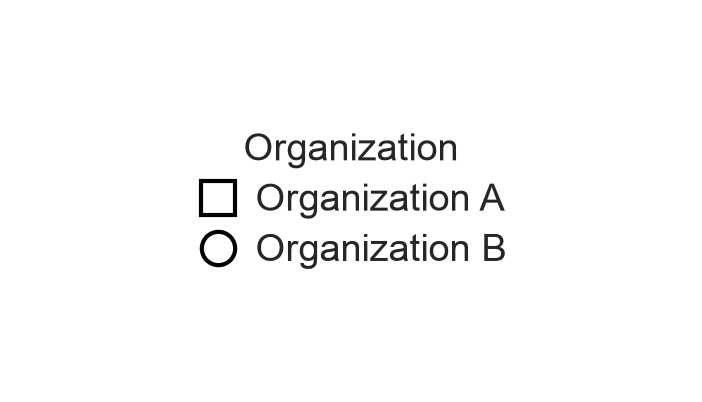

In [415]:
from matplotlib.lines import Line2D

legend_handles = [

    Line2D(
        [0],[0],
        marker='s',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8,
        label='Organization A'
    ),

    Line2D(
        [0],[0],
        marker='o',
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8,
        label='Organization B'
    )

]

make_legend(
    legend_handles,
    title="Organization",
    figsize=(2.5,1.5),
)

In [416]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon


def compute_composition_metrics(
    df,
    true_col="true_organization",
    recovered_col="Neighborhood",
    cell_type_col="cell_type",
):
    """
    Compare true and recovered neighborhood cell-type compositions.

    Returns
    -------
    metrics : dict
        Summary statistics.

    true_comp : pd.DataFrame
        True cell-type proportions.

    recovered_comp : pd.DataFrame
        Recovered cell-type proportions.

    diff : pd.DataFrame
        recovered - true proportions.

    per_celltype_error : pd.DataFrame
        Absolute error for every organization × cell type.
    """

    ####################################################
    # Cell-type compositions
    ####################################################

    true_comp = pd.crosstab(
        df[true_col],
        df[cell_type_col],
        normalize="index"
    )

    recovered_comp = pd.crosstab(
        df[recovered_col],
        df[cell_type_col],
        normalize="index"
    )

    # ensure identical ordering

    true_comp = true_comp.sort_index().sort_index(axis=1)

    recovered_comp = recovered_comp.reindex(
        index=true_comp.index,
        columns=true_comp.columns,
        fill_value=0
    )

    ####################################################
    # Difference matrix
    ####################################################

    diff = recovered_comp - true_comp

    ####################################################
    # Statistics
    ####################################################

    rows = []

    for org in true_comp.index:

        truth = true_comp.loc[org].values.astype(float)
        pred = recovered_comp.loc[org].values.astype(float)

        r, p = pearsonr(truth, pred)

        r2 = r**2

        rmse = np.sqrt(
            np.mean((truth - pred) ** 2)
        )

        mae = np.mean(
            np.abs(truth - pred)
        )

        js = jensenshannon(
            truth,
            pred
        )

        max_abs = np.max(
            np.abs(truth - pred)
        )

        rows.append({

            "Organization": org,

            "Pearson_r": r,

            "Pearson_p": p,

            "R2": r2,

            "RMSE": rmse,

            "MAE": mae,

            "Jensen_Shannon": js,

            "Max_Absolute_Error": max_abs

        })

    metrics = pd.DataFrame(rows)

    ####################################################
    # Per-cell-type errors
    ####################################################

    errors = []

    for org in true_comp.index:

        for ct in true_comp.columns:

            errors.append({

                "Organization": org,

                "Cell_Type": ct,

                "True": true_comp.loc[org, ct],

                "Recovered": recovered_comp.loc[org, ct],

                "Difference": diff.loc[org, ct],

                "Absolute_Error": abs(
                    diff.loc[org, ct]
                )

            })

    per_celltype_error = pd.DataFrame(errors)

    return (
        metrics,
        true_comp,
        recovered_comp,
        diff,
        per_celltype_error,
    )

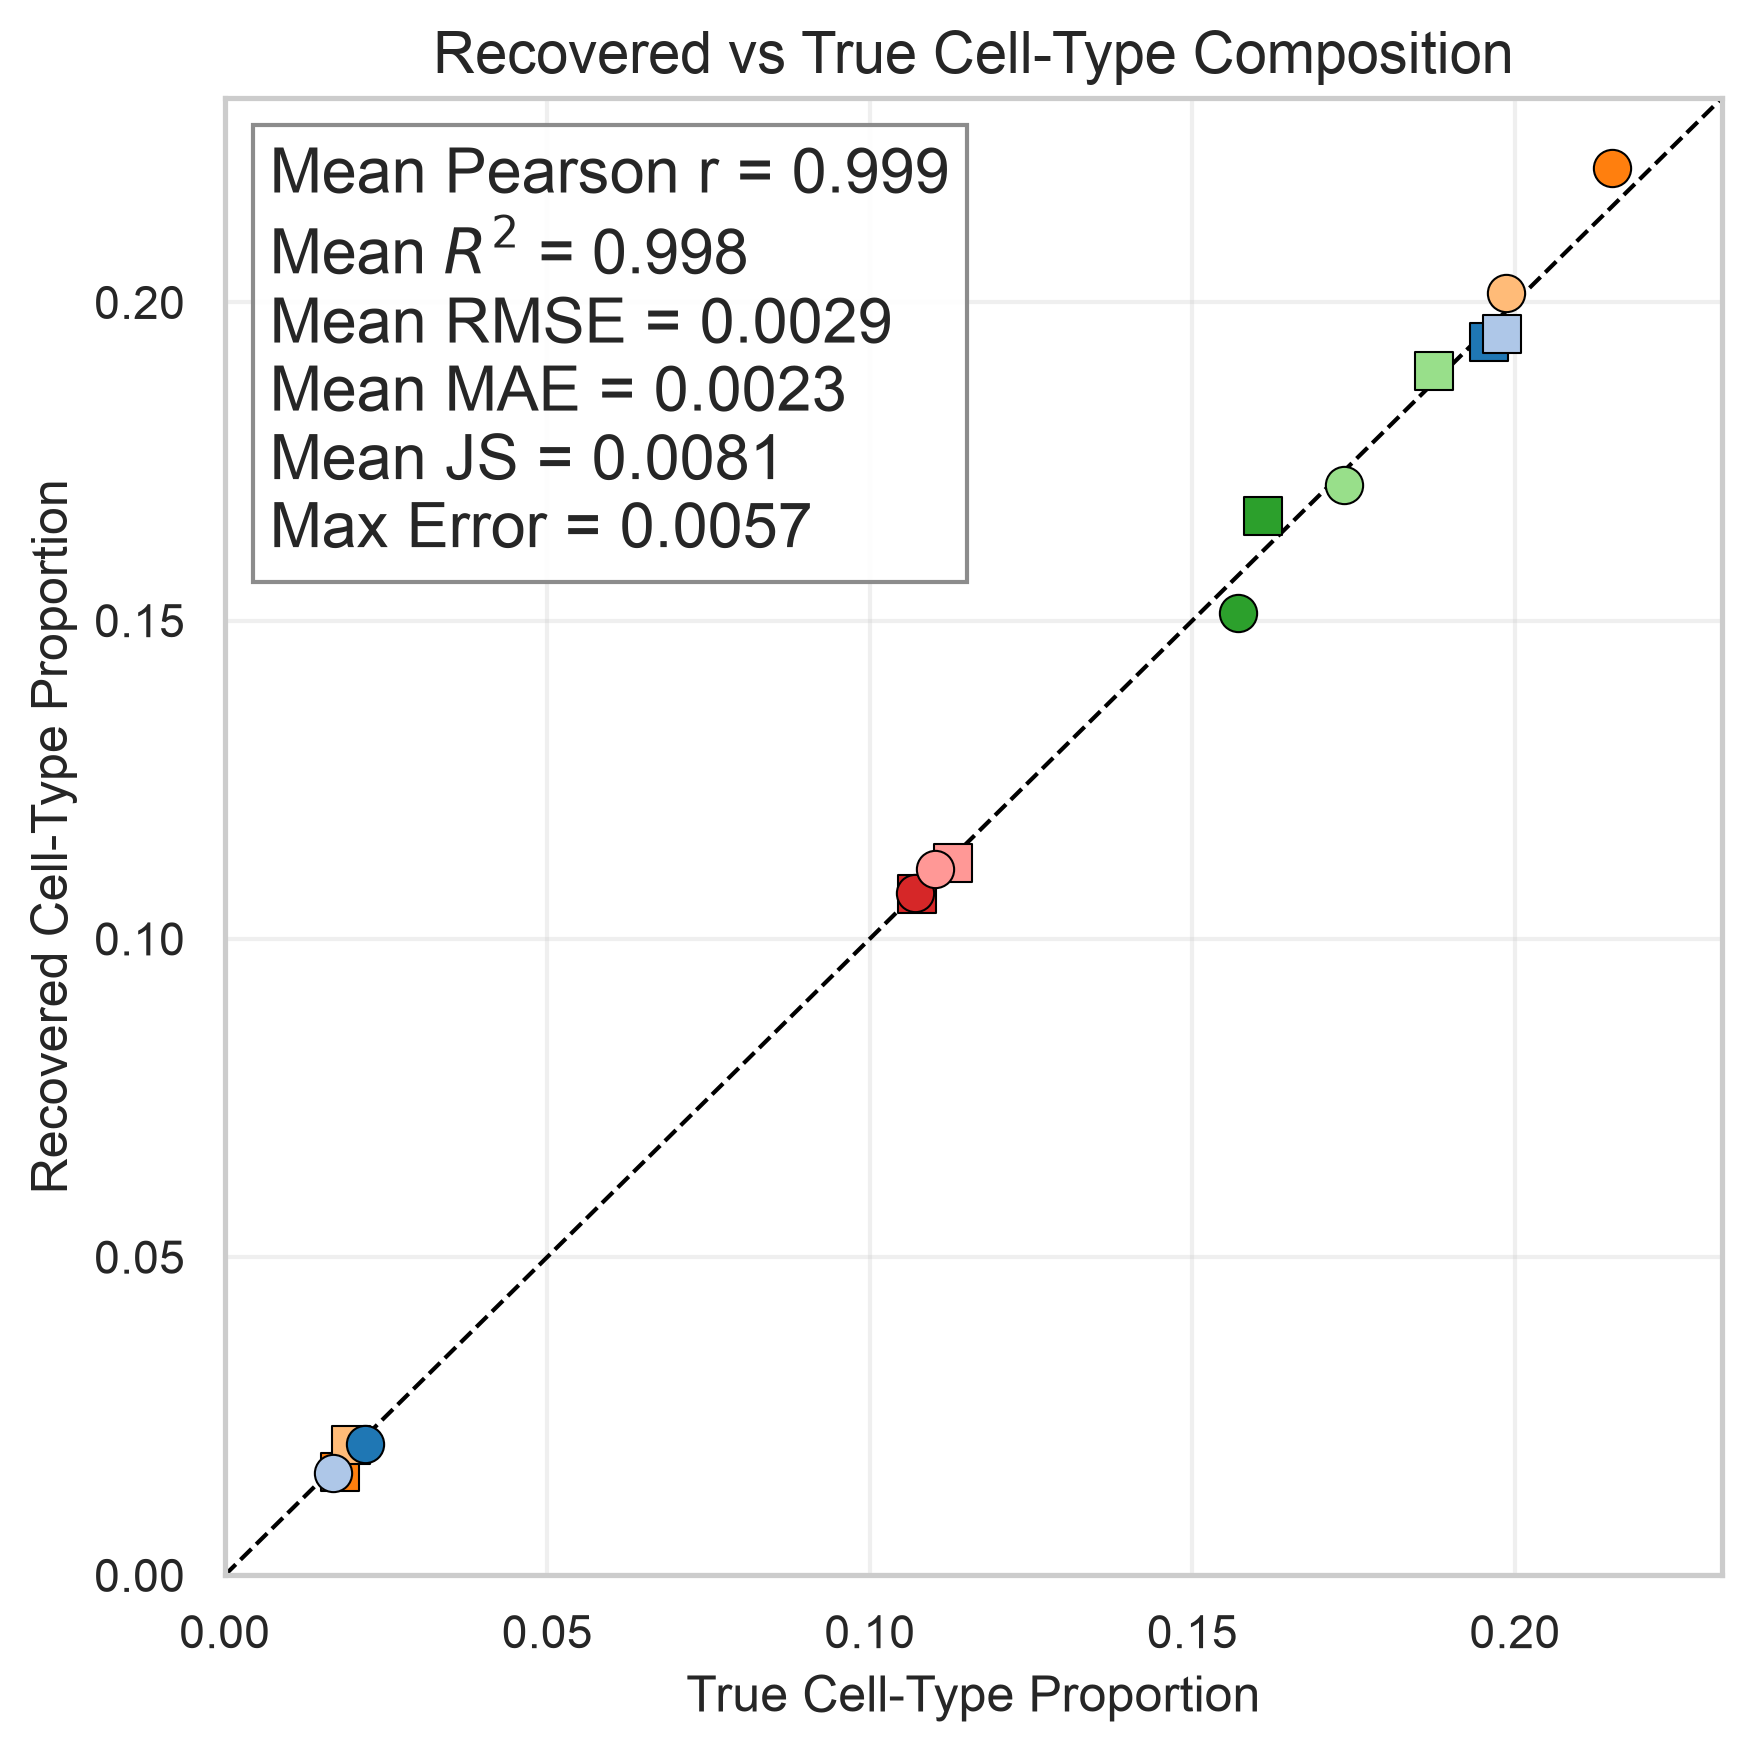

In [417]:
metrics, true_comp, recovered_comp, diff, errors = compute_composition_metrics(
    recovered.obs
)

plot_composition_scatter(
    metrics,
    true_comp,
    recovered_comp,
    color_dict,
)

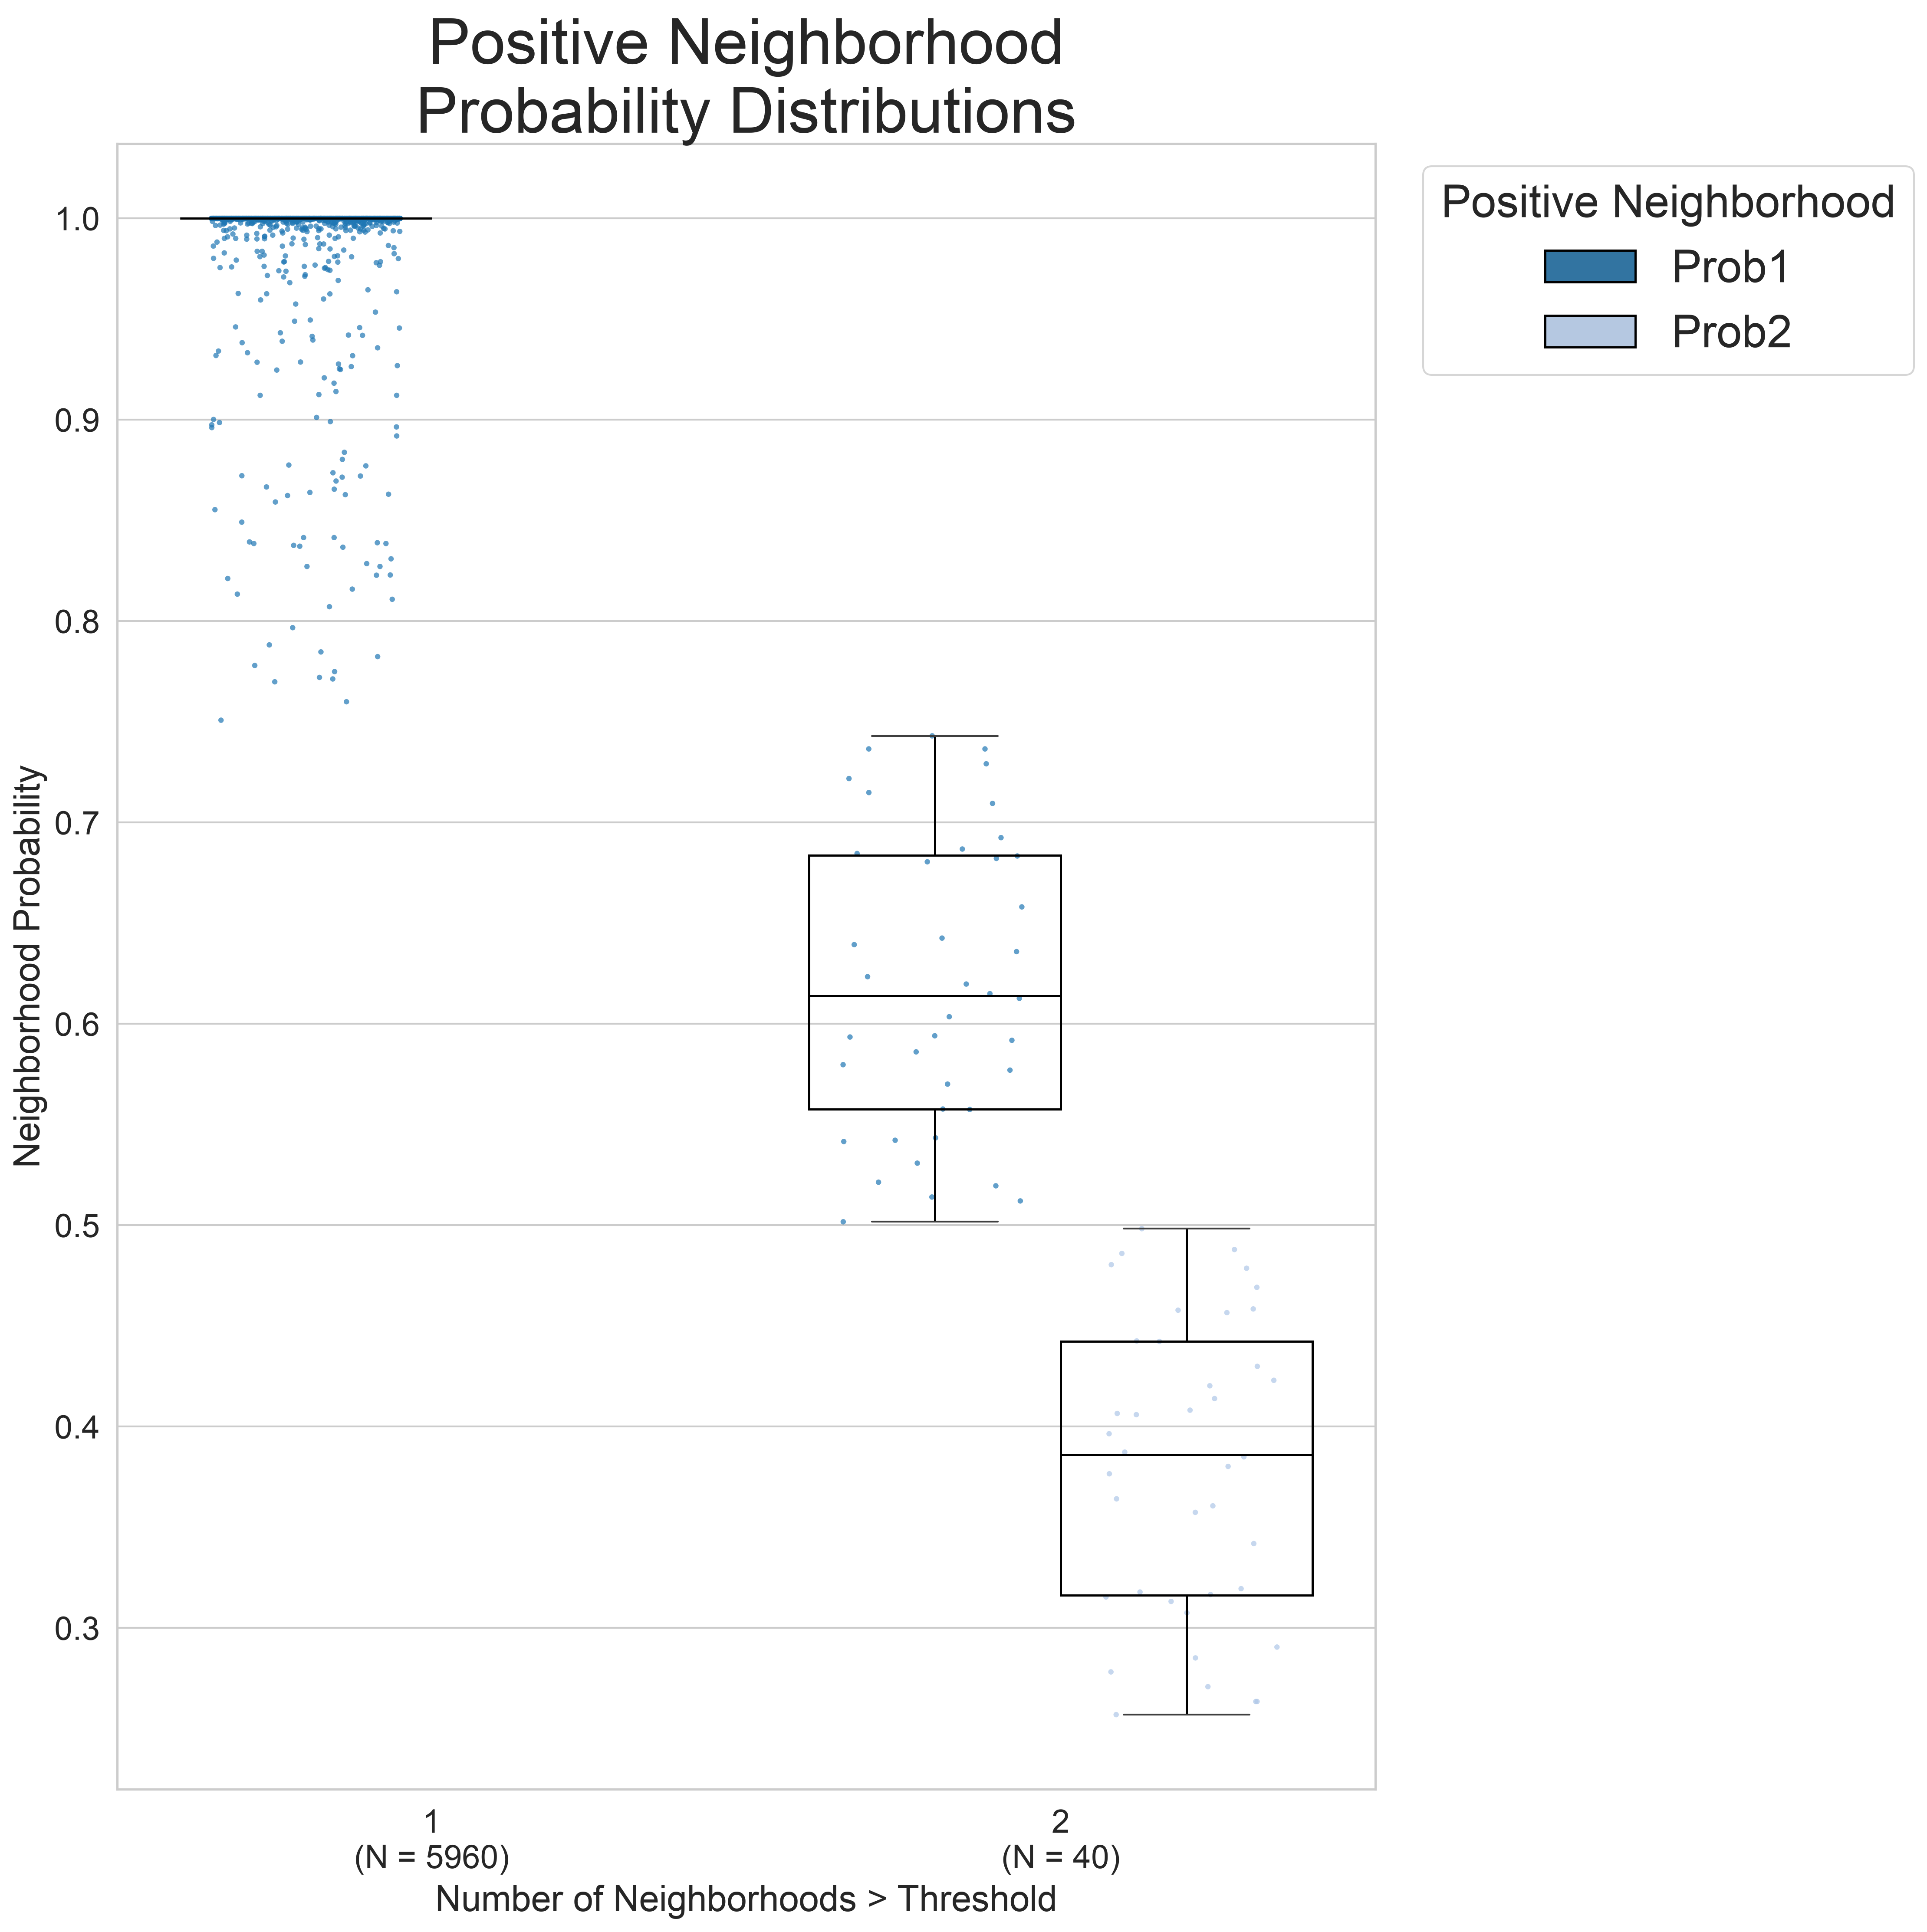

In [418]:
figs = mg.pl.edges_positive_probability(
            cells,
            prob_key="neighborhood_probabilities",
            threshold=0.25,
            save="png",
            show=True
        )

In [419]:
probabilities_df = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)

In [420]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def make_celltype_palette_strict(df, cell_type_col='Cell_Type'):
    """
    Create a long, non-repeating categorical color palette for each unique cell type.
    Uses a combination of seaborn/matplotlib categorical palettes.
    """
    import seaborn as sns

    # Get unique cell types
    cell_types = sorted(df[cell_type_col].dropna().unique())
    n = len(cell_types)

    # Combine multiple qualitative palettes
    palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
    combined_colors = []

    for name in palette_names:
        combined_colors.extend(sns.color_palette(name))

    if len(combined_colors) < n:
        raise ValueError(f"Not enough distinct colors for {n} cell types. Max supported is {len(combined_colors)}.")

    # Slice and assign
    final_palette = combined_colors[:n]
    color_dict = dict(zip(cell_types, final_palette))
    return color_dict, final_palette, cell_types

color_dict, color_list, cell_type_list = make_celltype_palette_strict(cells.obs, cell_type_col='cell_type')

/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/924959466.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Figures saved to: /Users/bharatkikani/Desktop/figures


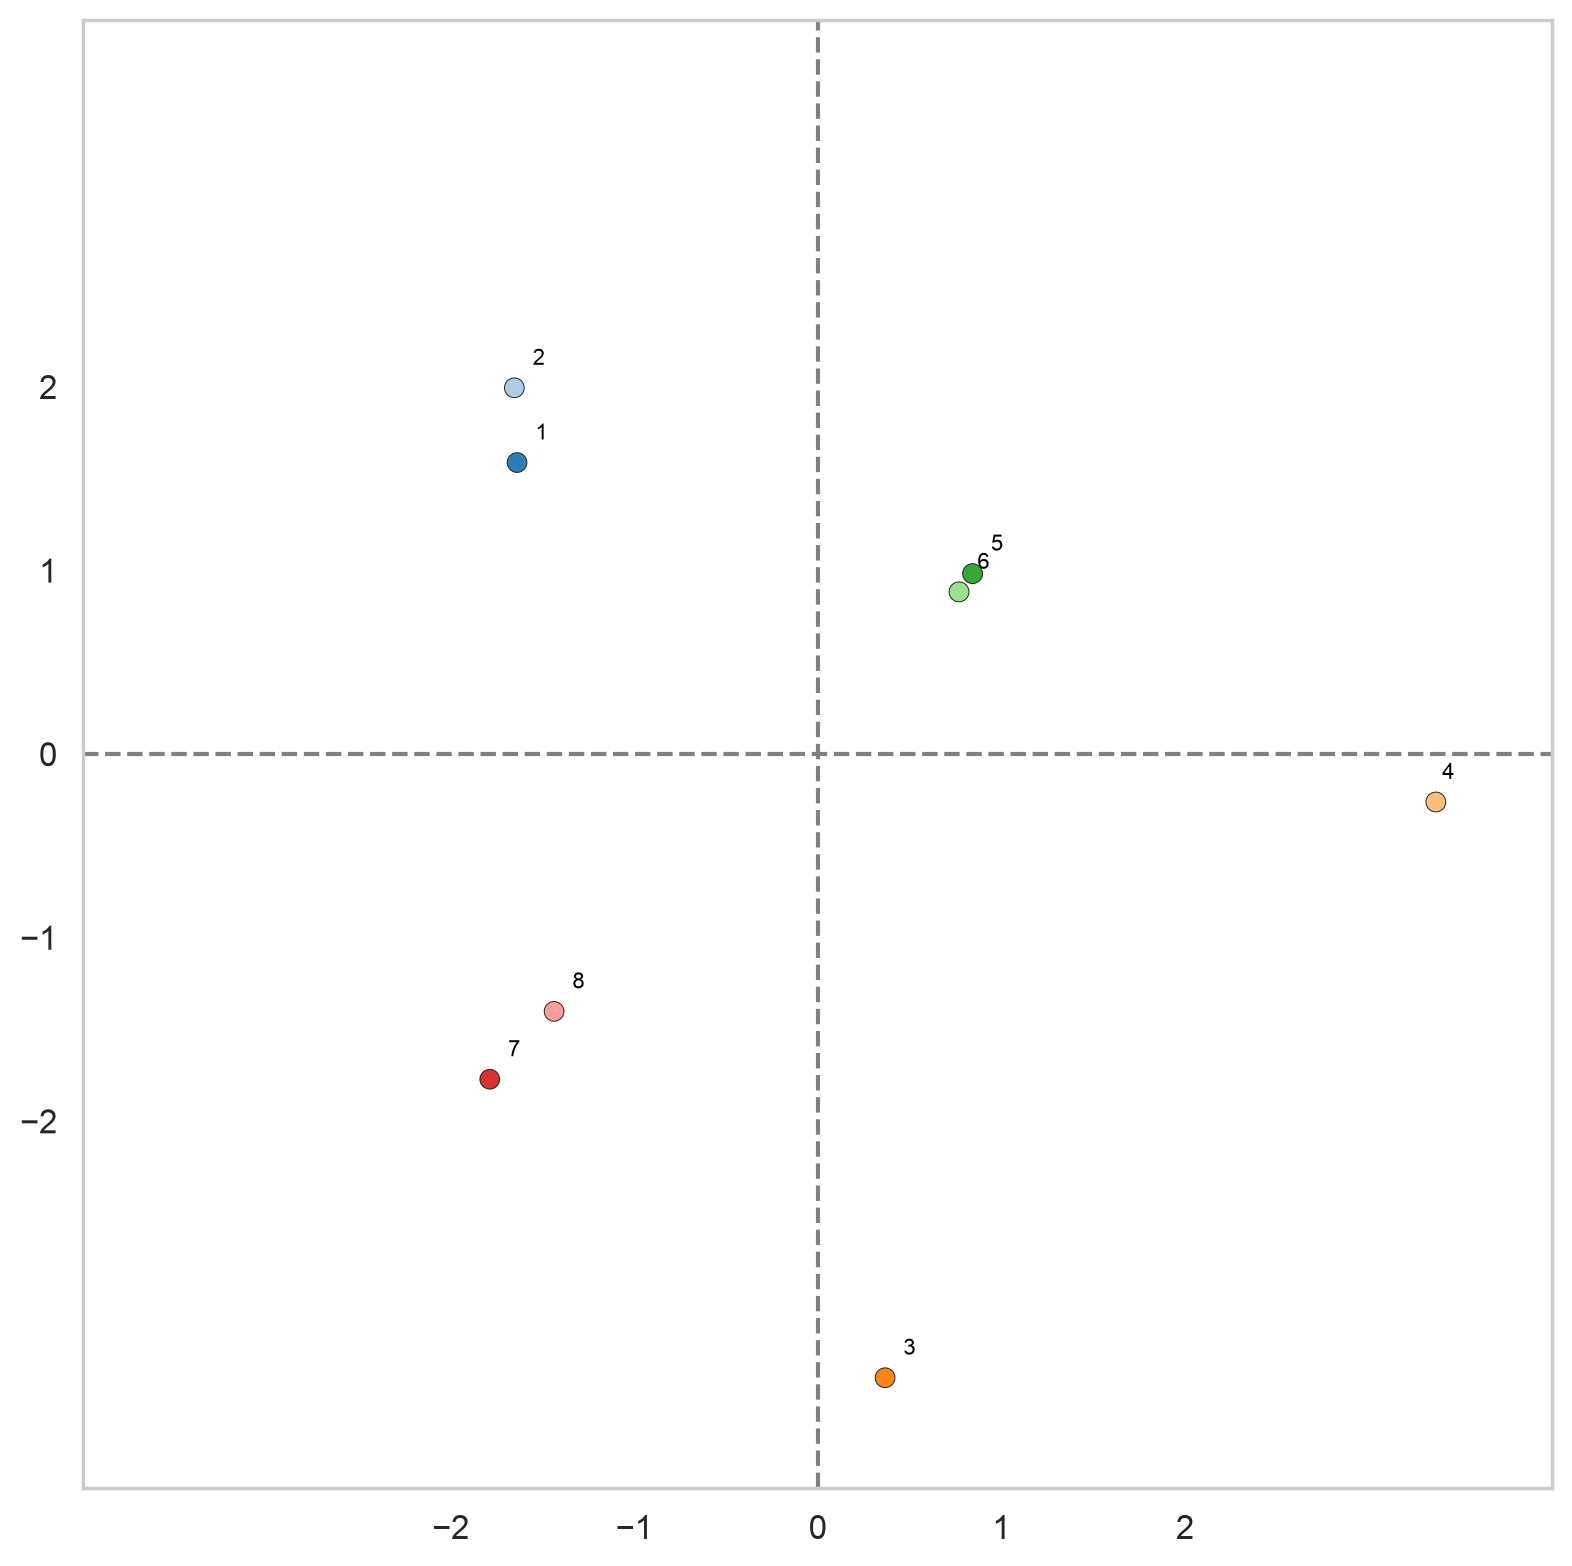

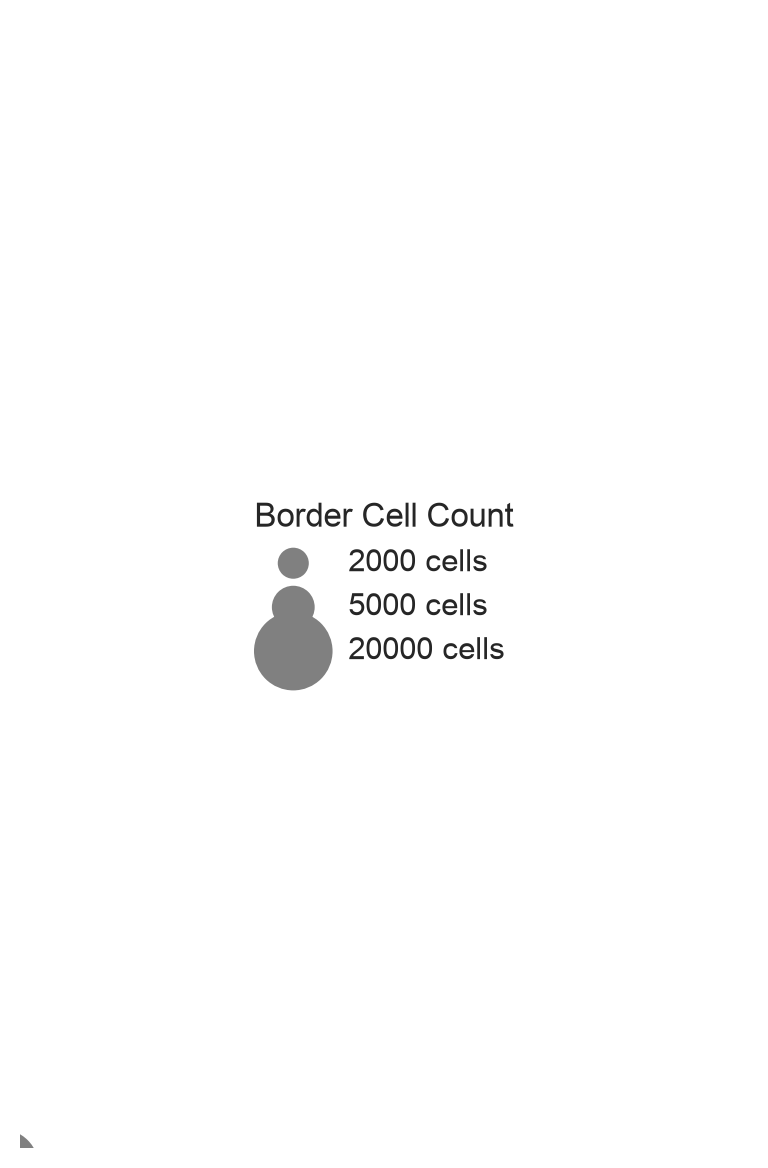

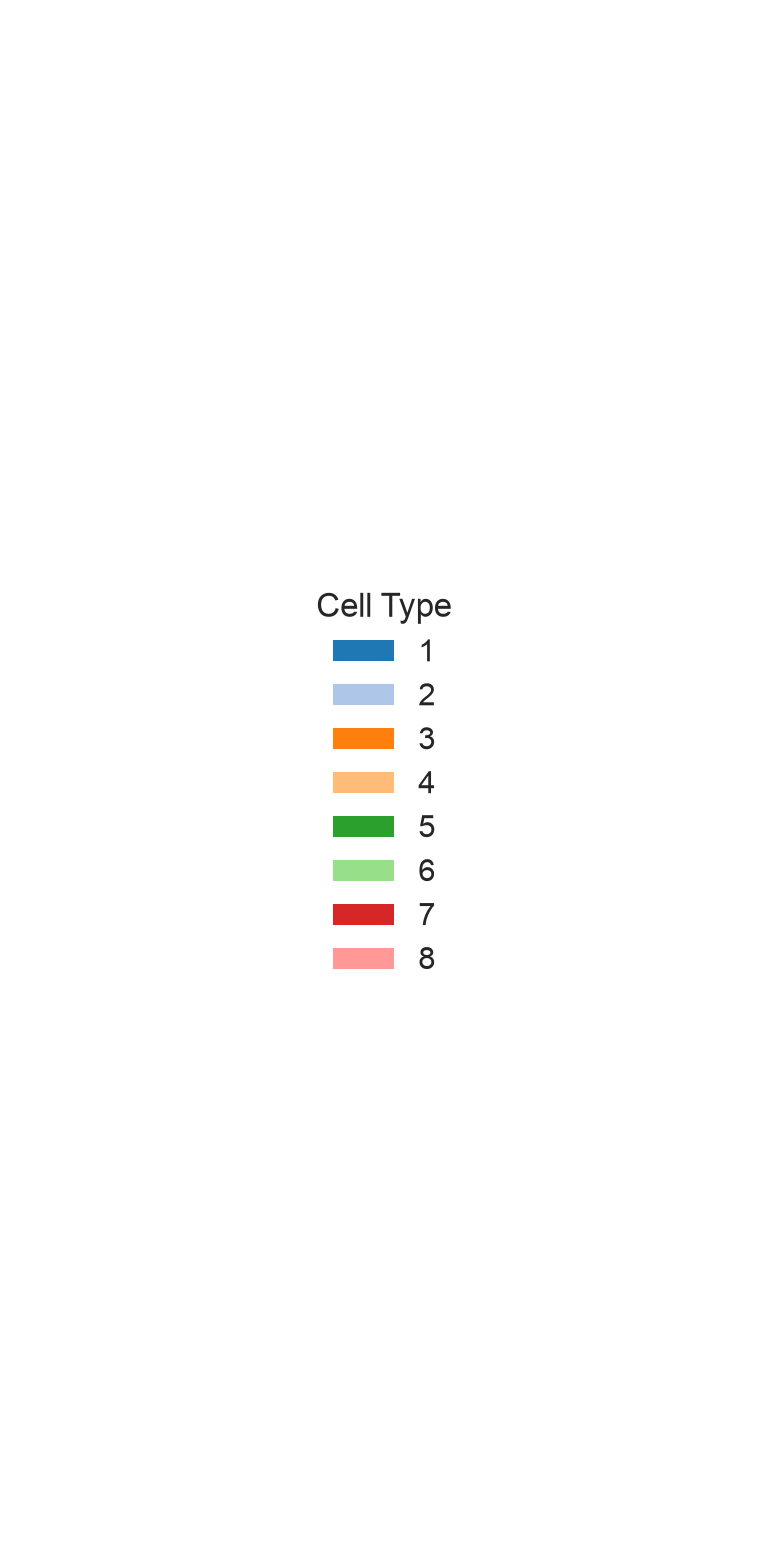

In [439]:
from pathlib import Path

save_dir = Path(
    "/Users/bharatkikani/Desktop/figures"
)

save_dir.mkdir(
    parents=True,
    exist_ok=True
)

figs = mg.pl.plot_border_enrichment(
    adata=cells,
    df_probabilities=probabilities_df,
    n1="A",
    n2="B",
    cell_type_col="cell_type",
    pos_threshold=0.1,
    min_count=1,
    prob_key="neighborhood_probabilities",
    show=False,
    dpi=200,
    label_dots=True,
    label_fontsize=8,
    label_offset_frac=0.02,
    label_bbox=None,
    neighborhood_count_threshold=0.05,
    use_tqdm_for_count=False,
)

# Handle either a dictionary or a list of figures
if isinstance(figs, dict):
    figure_items = figs.items()
else:
    figure_items = enumerate(figs)

for name, fig in figure_items:

    for ax in fig.axes:
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)

    if isinstance(name, str):
        filename = f"{name}.png"
    else:
        filename = f"mingl_border_enrichment_{name}.png"

    fig.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    fig.show()

print(f"Figures saved to: {save_dir}")

/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/371966871.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Figures saved to: /Users/bharatkikani/Desktop/figures


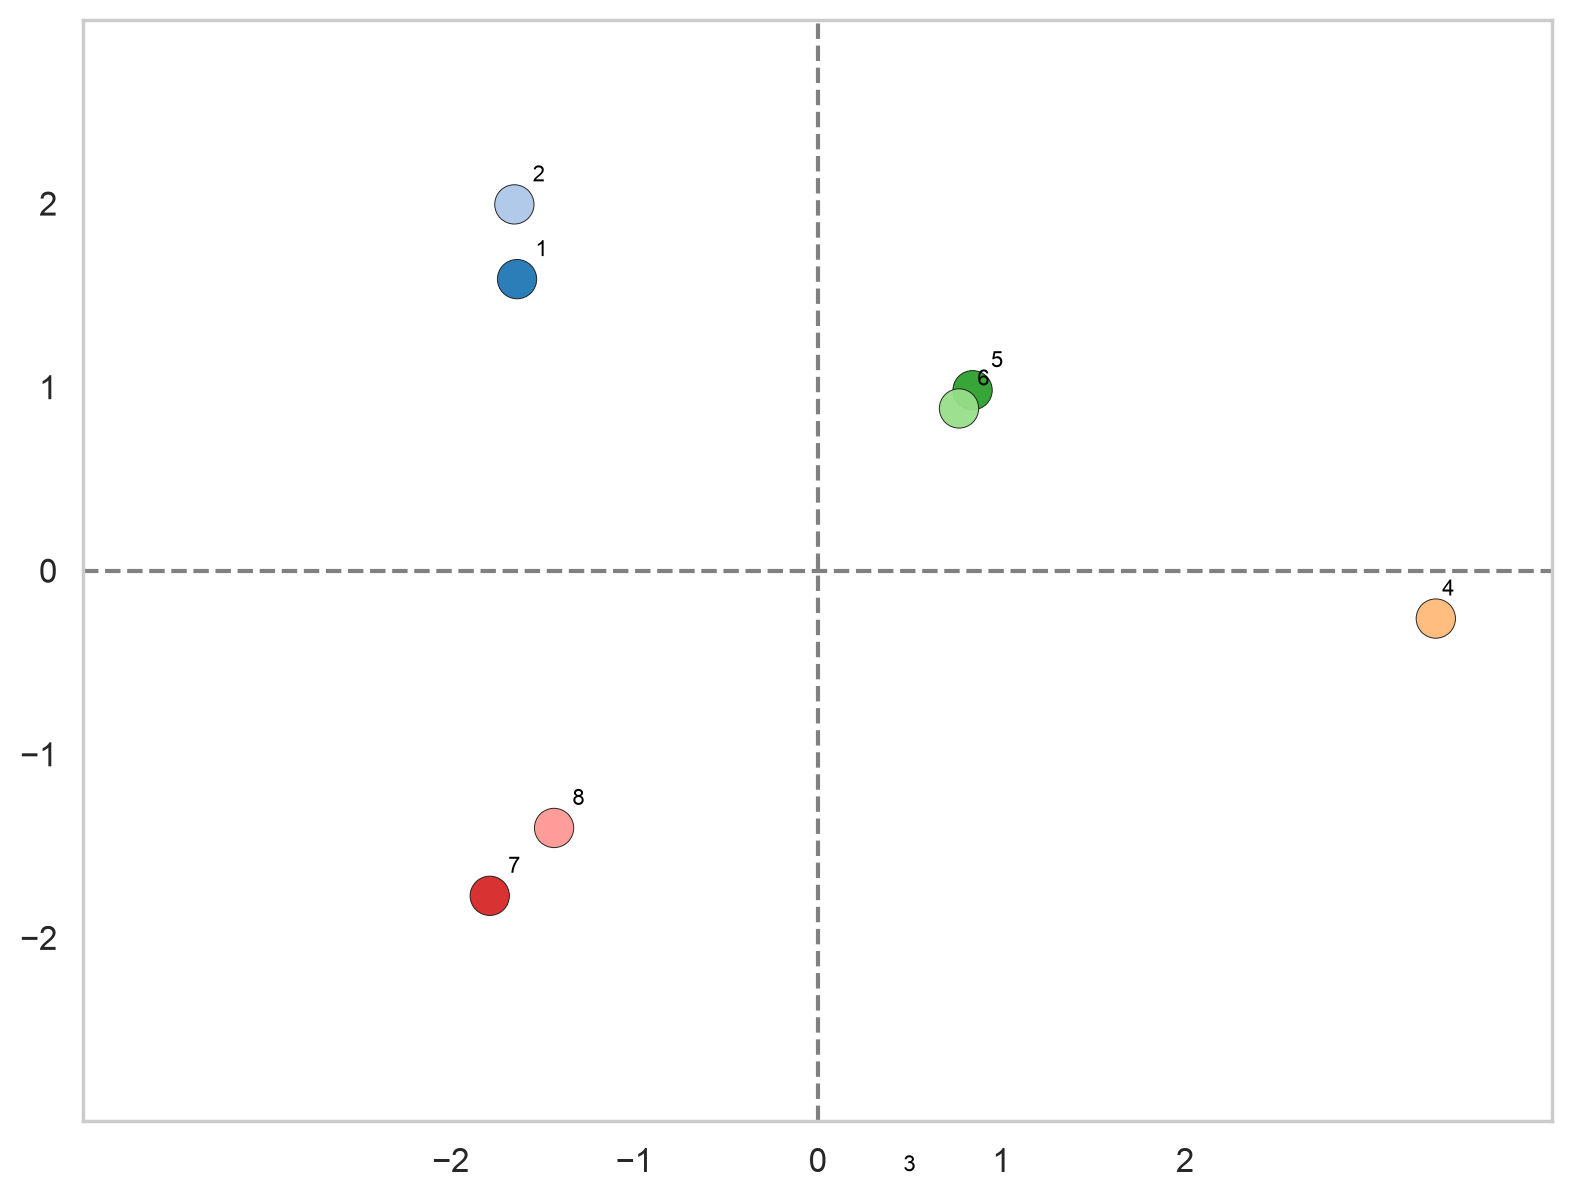

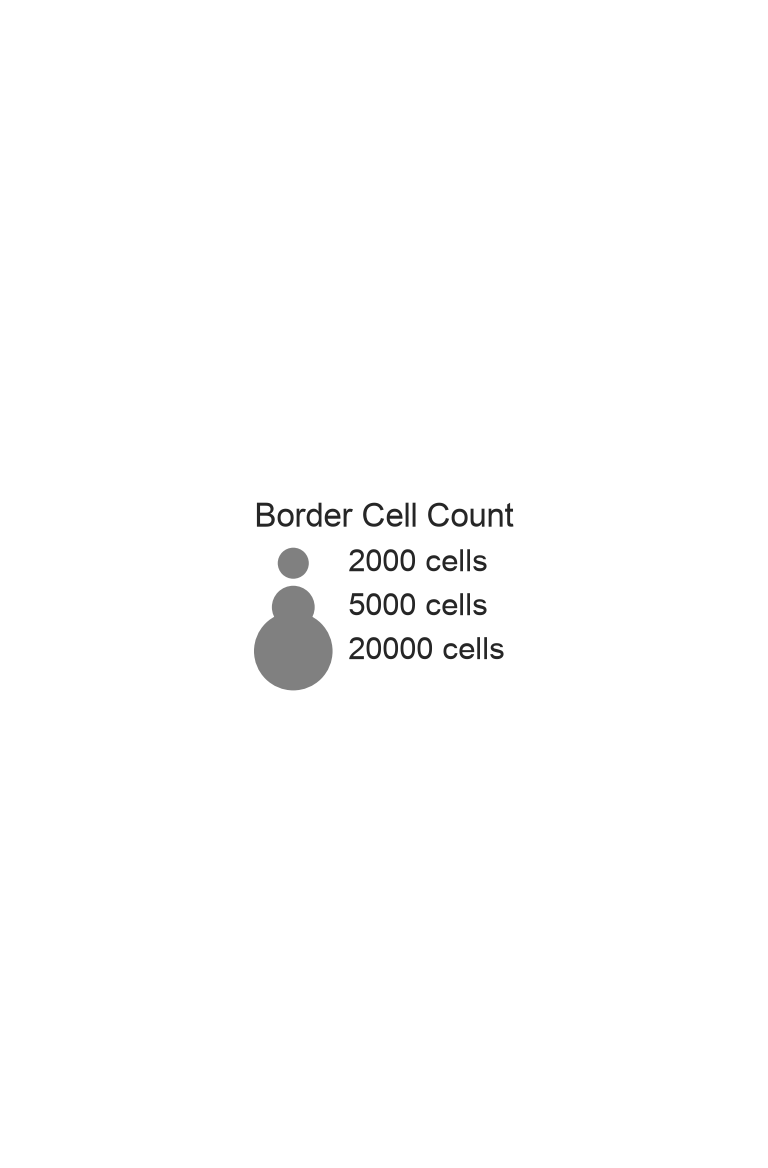

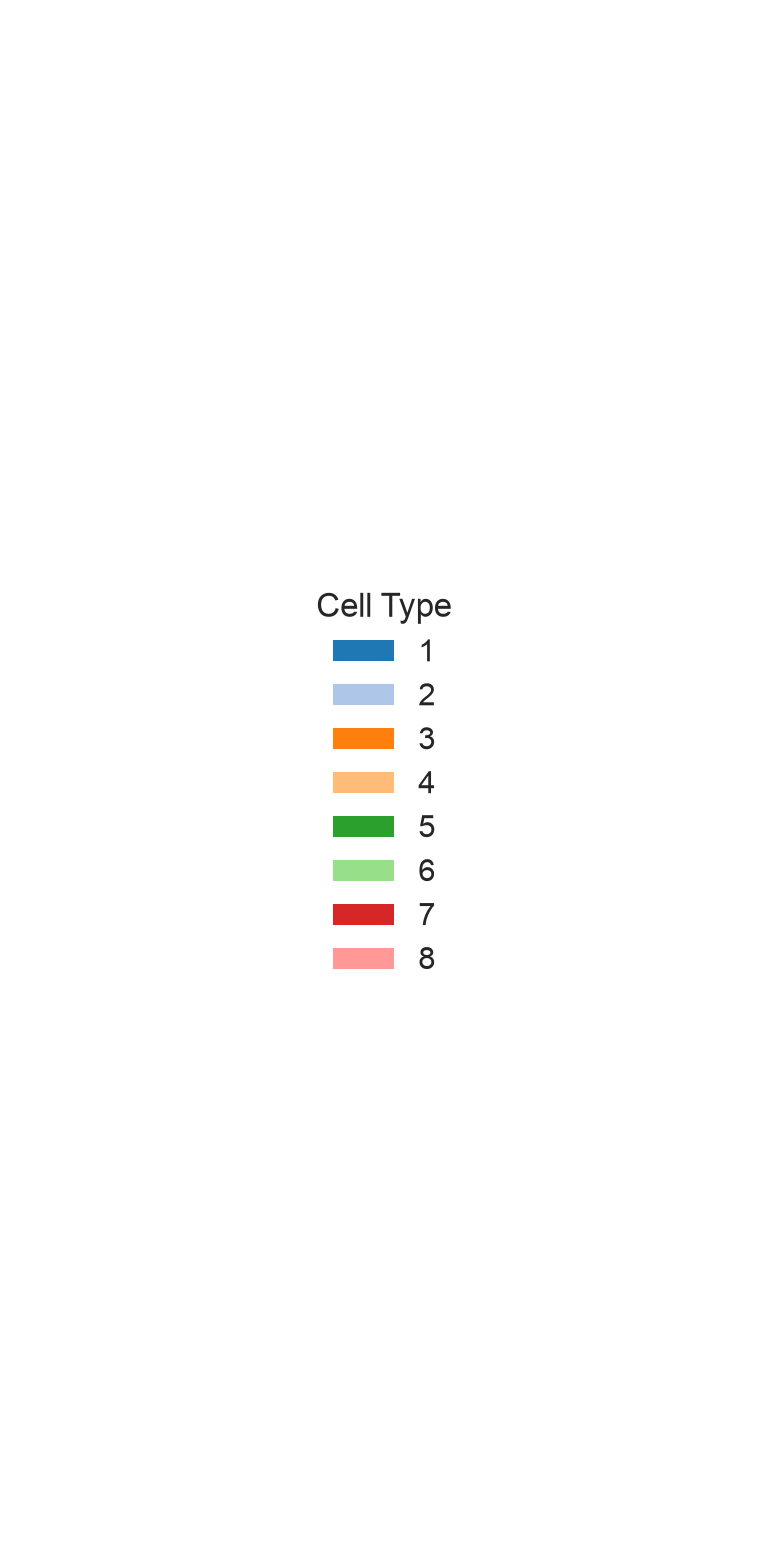

In [442]:
from pathlib import Path
from matplotlib.collections import PathCollection

save_dir = Path("/Users/bharatkikani/Desktop/figures")
save_dir.mkdir(parents=True, exist_ok=True)

DOT_SIZE = 200  # Increase this value for larger dots

figs = mg.pl.plot_border_enrichment(
    adata=cells,
    df_probabilities=probabilities_df,
    n1="A",
    n2="B",
    cell_type_col="cell_type",
    pos_threshold=0.1,
    min_count=1,
    prob_key="neighborhood_probabilities",
    show=False,
    dpi=200,
    label_dots=True,
    label_fontsize=8,
    label_offset_frac=0.02,
    label_bbox=None,
    neighborhood_count_threshold=0.05,
    use_tqdm_for_count=False,
)

# Handle either a dictionary or a list of figures
if isinstance(figs, dict):
    figure_items = figs.items()
else:
    figure_items = enumerate(figs)

for name, fig in figure_items:

    for ax in fig.axes:
        ax.set_xlim(-4, 4)
        ax.set_ylim(-3, 3)

        # Make plotted dots larger
        for collection in ax.collections:
            if isinstance(collection, PathCollection):
                collection.set_sizes([DOT_SIZE])

    if isinstance(name, str):
        filename = f"{name}.png"
    else:
        filename = f"mingl_border_enrichment_{name}.png"

    fig.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    fig.show()

print(f"Figures saved to: {save_dir}")

Figures saved to: /Users/bharatkikani/Desktop/figures


/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/3641205892.py:151: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


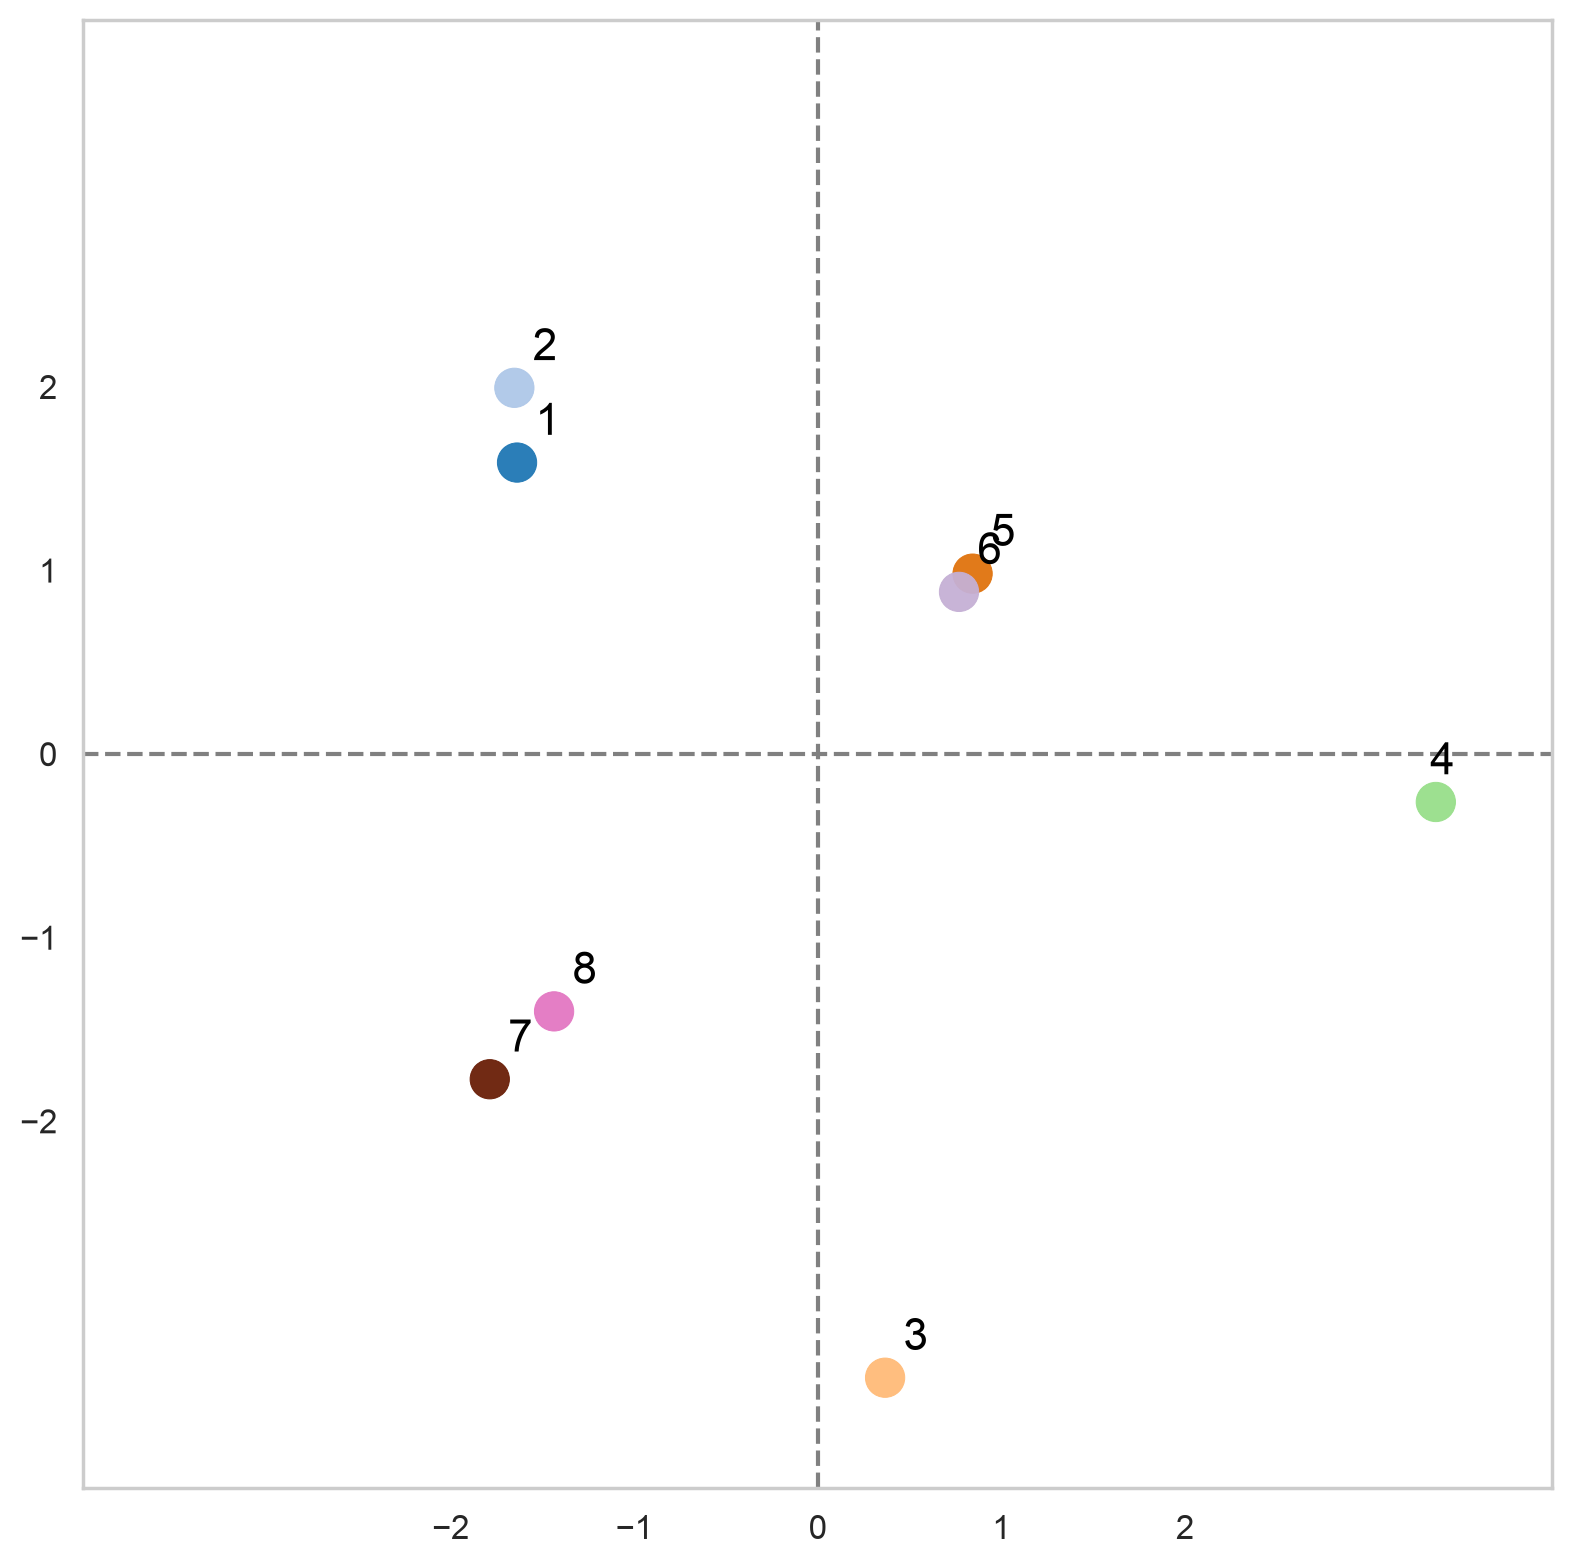

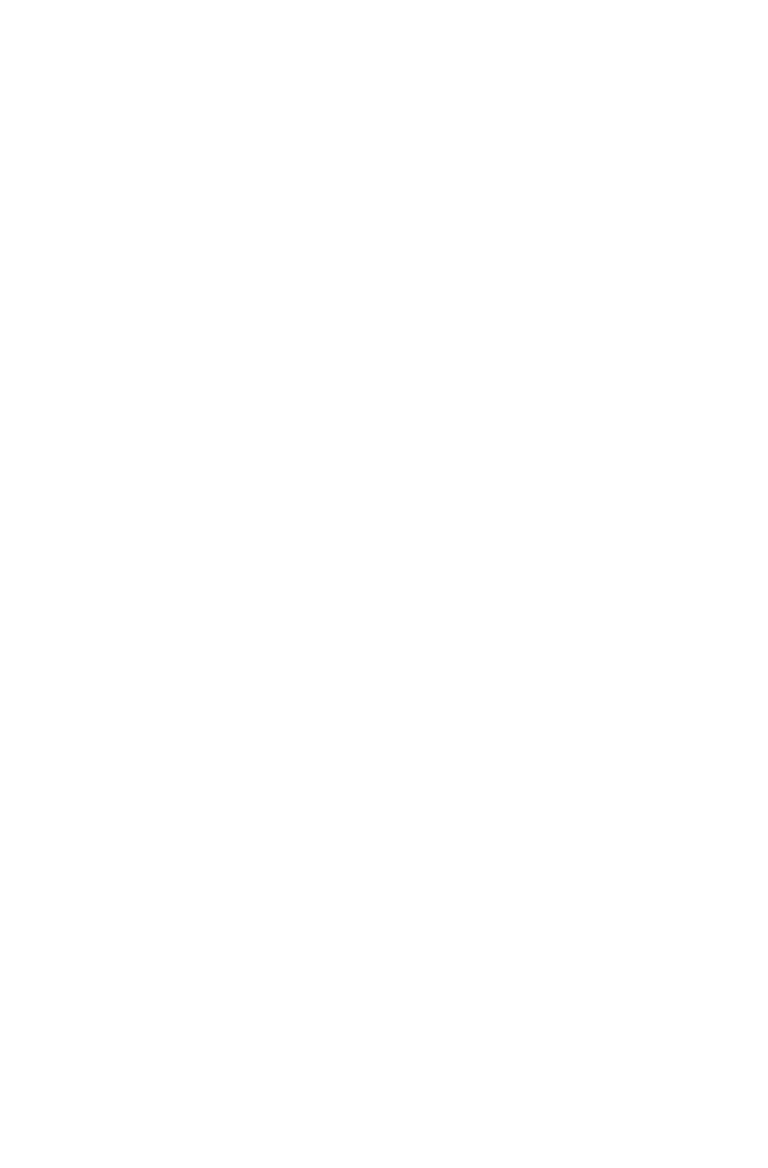

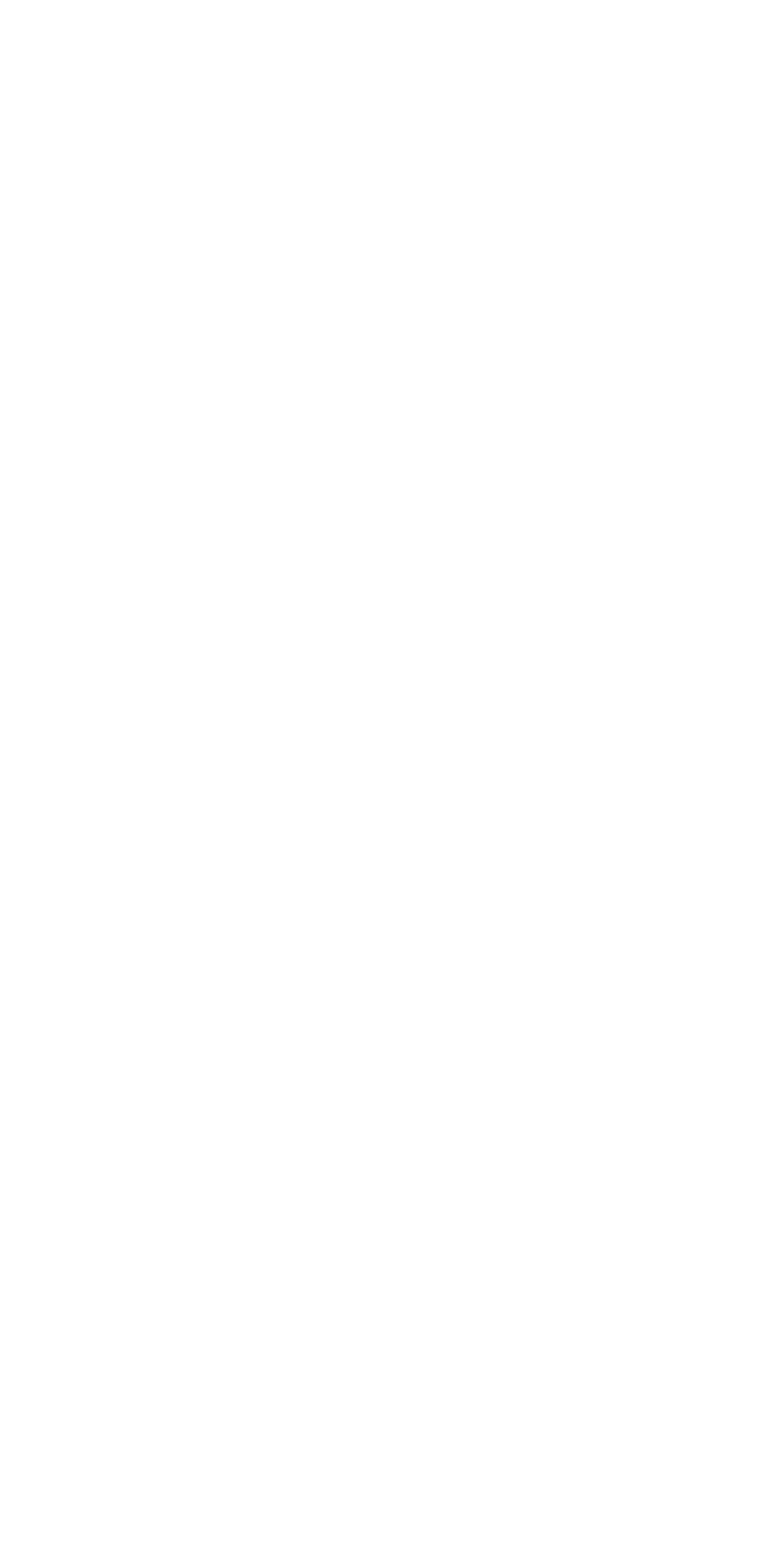

In [452]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection


# Output directory
save_dir = Path("/Users/bharatkikani/Desktop/figures")
save_dir.mkdir(parents=True, exist_ok=True)


# Plot settings
DOT_SIZE = 200
NUMBER_FONT_SIZE = 16


# Cell types in numeric order
unique_cell_types = sorted(
    cells.obs["cell_type"].dropna().unique(),
    key=lambda x: int(x)
)

unique_cell_types = [
    str(cell_type)
    for cell_type in unique_cell_types
]


# Explicit colors matching the screenshot
cell_type_colors = [
    "#1f77b4",  # 1: blue
    "#aec7e8",  # 2: light blue
    "#ffbb78",  # 3: light orange
    "#98df8a",  # 4: light green
    "#e0730de8",  # 5: orange
    "#c5b0d5",  # 6: light purple
    "#691e07",  # 7: brown
    "#e377c2",  # 8: pink
]


# Create cell-type-to-color mapping
color_map = {
    cell_type: cell_type_colors[i]
    for i, cell_type in enumerate(unique_cell_types)
}


# Generate MINGL border-enrichment figures
figs = mg.pl.plot_border_enrichment(
    adata=cells,
    df_probabilities=probabilities_df,
    n1="A",
    n2="B",
    cell_type_col="cell_type",
    pos_threshold=0.1,
    min_count=1,
    prob_key="neighborhood_probabilities",
    show=False,
    dpi=200,
    label_dots=True,
    label_fontsize=NUMBER_FONT_SIZE,
    label_offset_frac=0.02,
    label_bbox=None,
    neighborhood_count_threshold=0.05,
    use_tqdm_for_count=False,
)


# Handle dictionary or list of figures
if isinstance(figs, dict):
    figure_items = figs.items()
else:
    figure_items = enumerate(figs)


for name, fig in figure_items:

    for ax in fig.axes:

        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)

        # Find scatter plots
        scatter_collections = [
            collection
            for collection in ax.collections
            if isinstance(collection, PathCollection)
        ]

        for collection in scatter_collections:

            n_points = len(collection.get_offsets())

            # Apply one color to each cell-type dot
            if n_points == len(unique_cell_types):

                colors_for_dots = [
                    color_map[cell_type]
                    for cell_type in unique_cell_types
                ]

                collection.set_facecolors(colors_for_dots)
                collection.set_edgecolors(colors_for_dots)
                collection.set_sizes([DOT_SIZE] * n_points)

            else:
                collection.set_sizes([DOT_SIZE] * n_points)

        # Increase the size of the numbers displayed beside dots
        for text in ax.texts:
            text.set_fontsize(NUMBER_FONT_SIZE)

        # Remove the original legend
        legend = ax.get_legend()

        if legend is not None:
            legend.remove()

        # Build a matching legend
        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=color_map[cell_type],
                markeredgecolor=color_map[cell_type],
                markersize=8,
                linestyle="",
                label=cell_type,
            )
            for cell_type in unique_cell_types
        ]


    # Output filename
    if isinstance(name, str):
        filename = f"{name}.png"
    else:
        filename = f"mingl_border_enrichment_{name}.png"

    # Save figure
    fig.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    fig.show()


print(f"Figures saved to: {save_dir}")

/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/1971569339.py:170: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Figures saved to: /Users/bharatkikani/Desktop/figures


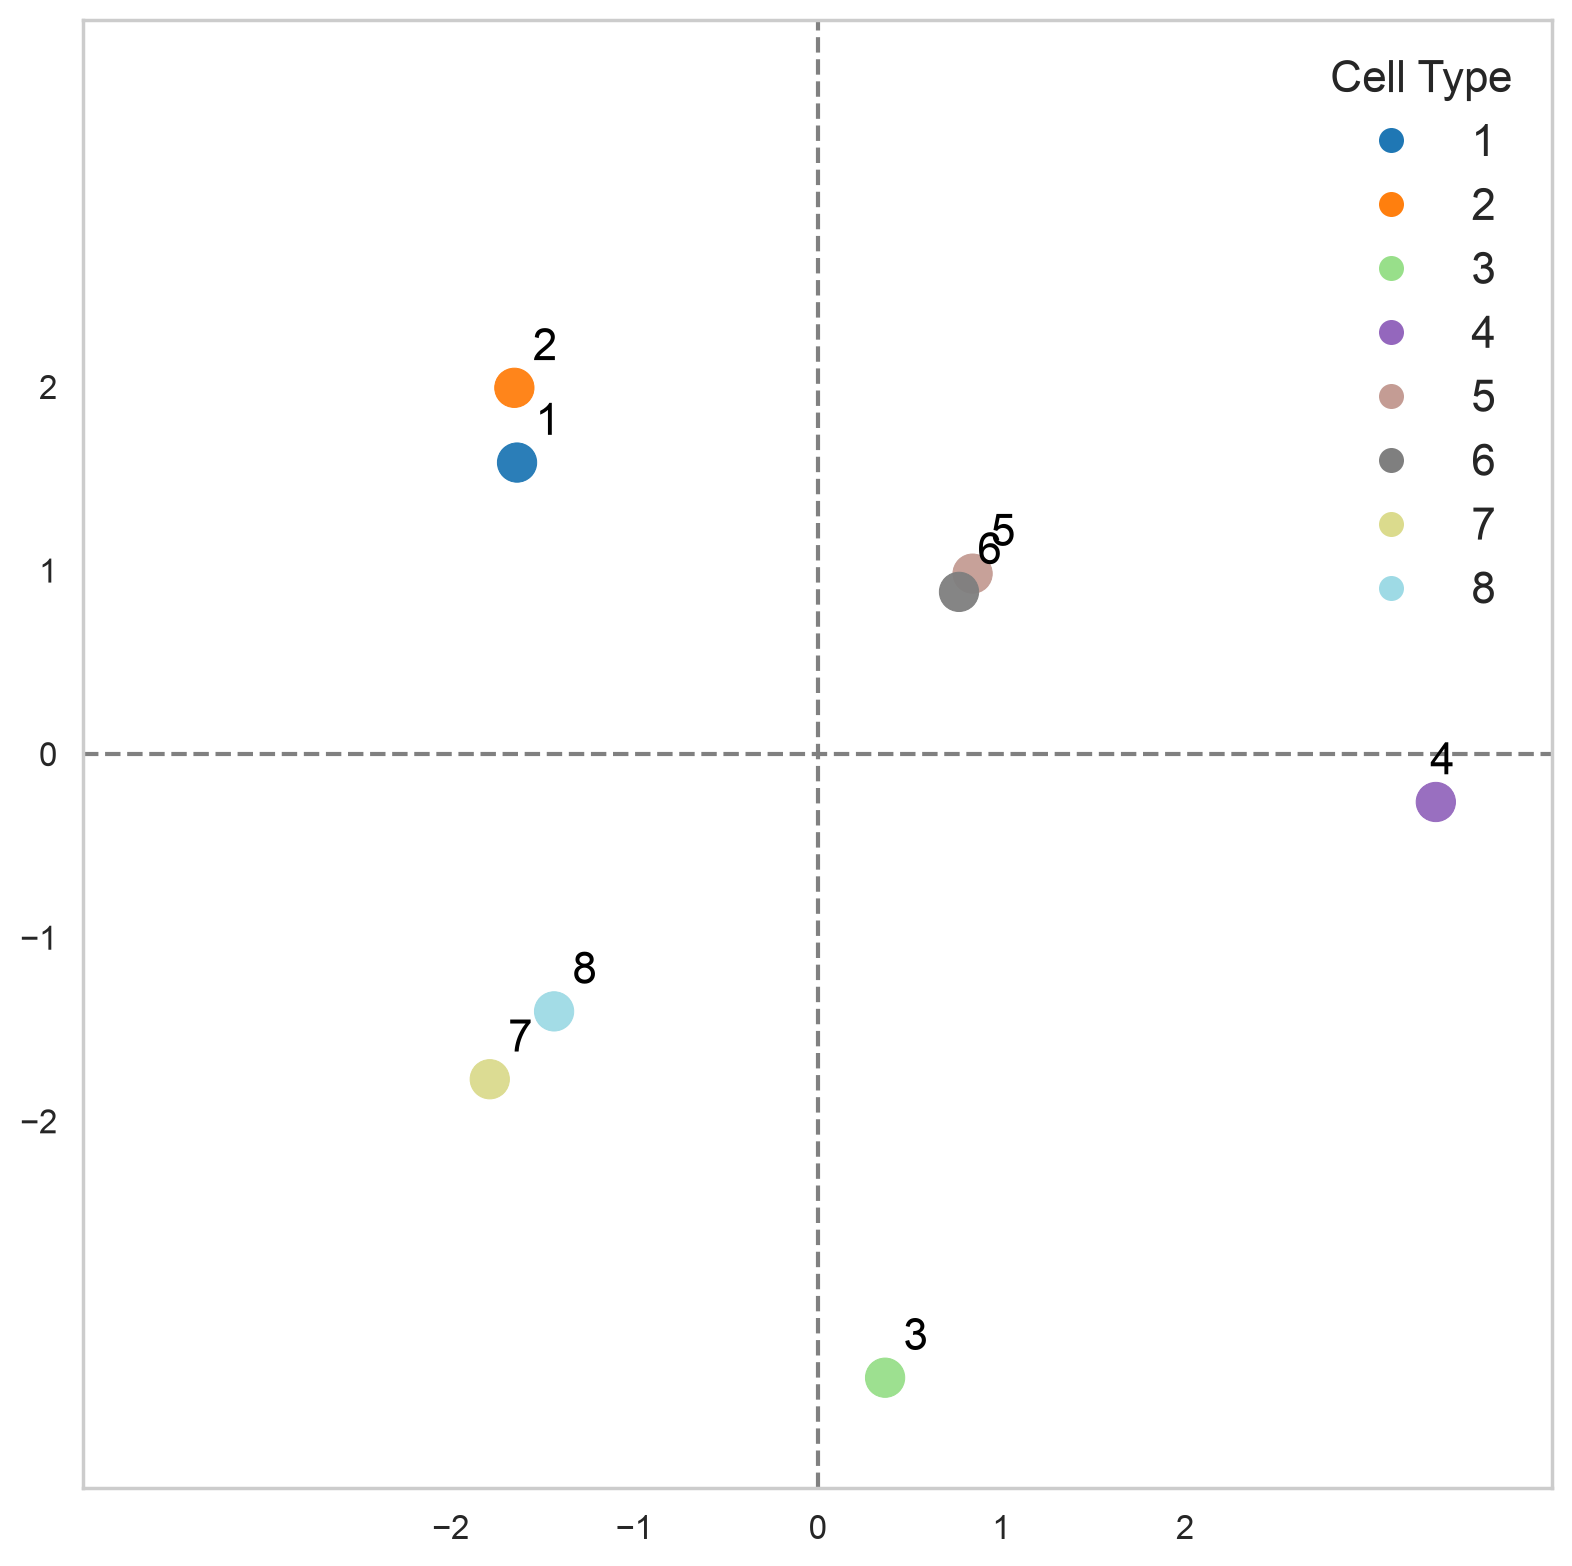

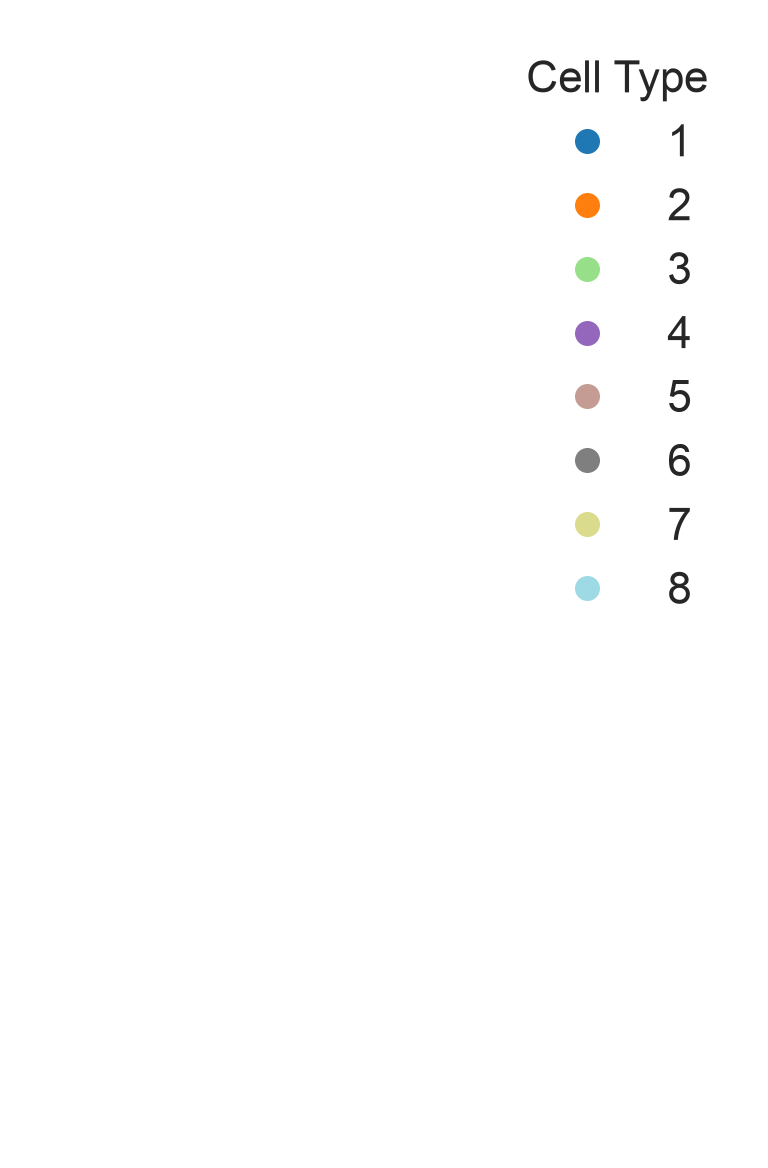

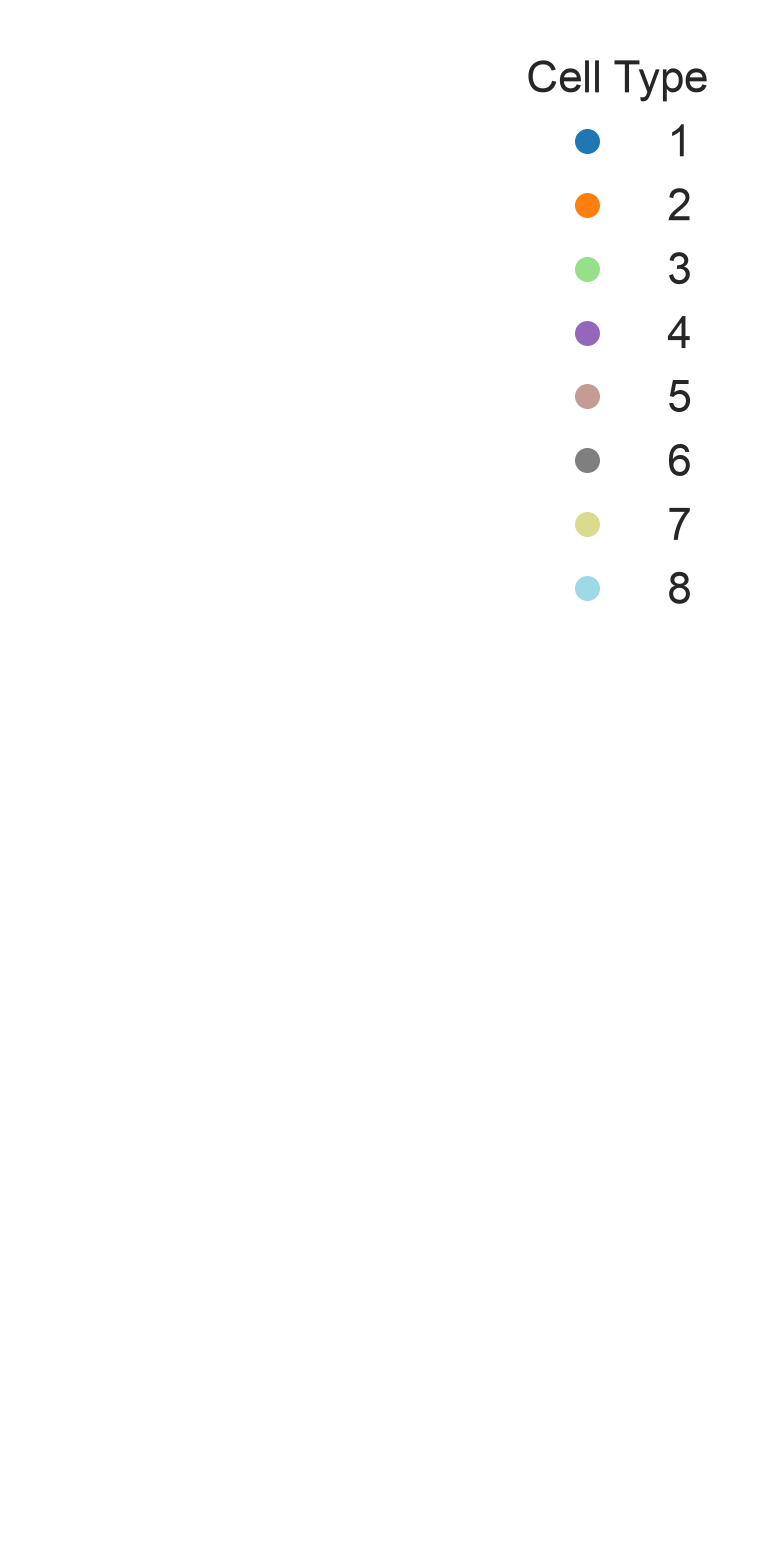

In [448]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection


# Output directory
save_dir = Path("/Users/bharatkikani/Desktop/figures")
save_dir.mkdir(parents=True, exist_ok=True)


# Plot settings
DOT_SIZE = 200
NUMBER_FONT_SIZE = 16


# Get cell types in numeric order
cell_types = cells.obs["cell_type"].dropna().unique()

try:
    unique_cell_types = sorted(
        cell_types,
        key=lambda x: int(x)
    )
except (ValueError, TypeError):
    unique_cell_types = sorted(
        cell_types,
        key=str
    )

unique_cell_types = [
    str(cell_type)
    for cell_type in unique_cell_types
]


# Create the color mapping
cmap = plt.colormaps["tab20"].resampled(
    len(unique_cell_types)
)

color_map = {
    cell_type: cmap(i)
    for i, cell_type in enumerate(unique_cell_types)
}

cell_type_colors = [
    color_map[cell_type]
    for cell_type in unique_cell_types
]


# Generate border-enrichment figures
figs = mg.pl.plot_border_enrichment(
    adata=cells,
    df_probabilities=probabilities_df,
    n1="A",
    n2="B",
    cell_type_col="cell_type",
    pos_threshold=0.1,
    min_count=1,
    prob_key="neighborhood_probabilities",
    show=False,
    dpi=200,
    label_dots=True,
    label_fontsize=NUMBER_FONT_SIZE,
    label_offset_frac=0.02,
    label_bbox=None,
    neighborhood_count_threshold=0.05,
    use_tqdm_for_count=False,
)


# Handle either a dictionary or a list of figures
if isinstance(figs, dict):
    figure_items = figs.items()
else:
    figure_items = enumerate(figs)


for name, fig in figure_items:

    for ax in fig.axes:

        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)

        # Find plotted scatter collections
        scatter_collections = [
            collection
            for collection in ax.collections
            if isinstance(collection, PathCollection)
        ]

        for collection in scatter_collections:

            n_points = len(collection.get_offsets())

            # Apply one color per cell type
            if n_points == len(unique_cell_types):

                collection.set_facecolors(
                    cell_type_colors
                )

                collection.set_edgecolors(
                    cell_type_colors
                )

                collection.set_sizes(
                    [DOT_SIZE] * n_points
                )

            else:

                collection.set_sizes(
                    [DOT_SIZE] * n_points
                )

        # Increase the size of the numbers next to the dots
        for text in ax.texts:
            text.set_fontsize(NUMBER_FONT_SIZE)

        # Rebuild the legend using the exact same color mapping
        legend = ax.get_legend()

        if legend is not None:
            legend.remove()

        handles = []

        for cell_type in unique_cell_types:

            handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor=color_map[cell_type],
                    markeredgecolor=color_map[cell_type],
                    markersize=8,
                    linestyle="",
                    label=cell_type,
                )
            )

        ax.legend(
            handles=handles,
            title="Cell Type",
            frameon=False,
            fontsize=NUMBER_FONT_SIZE,
            title_fontsize=NUMBER_FONT_SIZE,
            loc="best",
        )

    # Create output filename
    if isinstance(name, str):
        filename = f"{name}.png"
    else:
        filename = f"mingl_border_enrichment_{name}.png"

    # Save figure
    fig.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    fig.show()


print(f"Figures saved to: {save_dir}")

/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/998732607.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


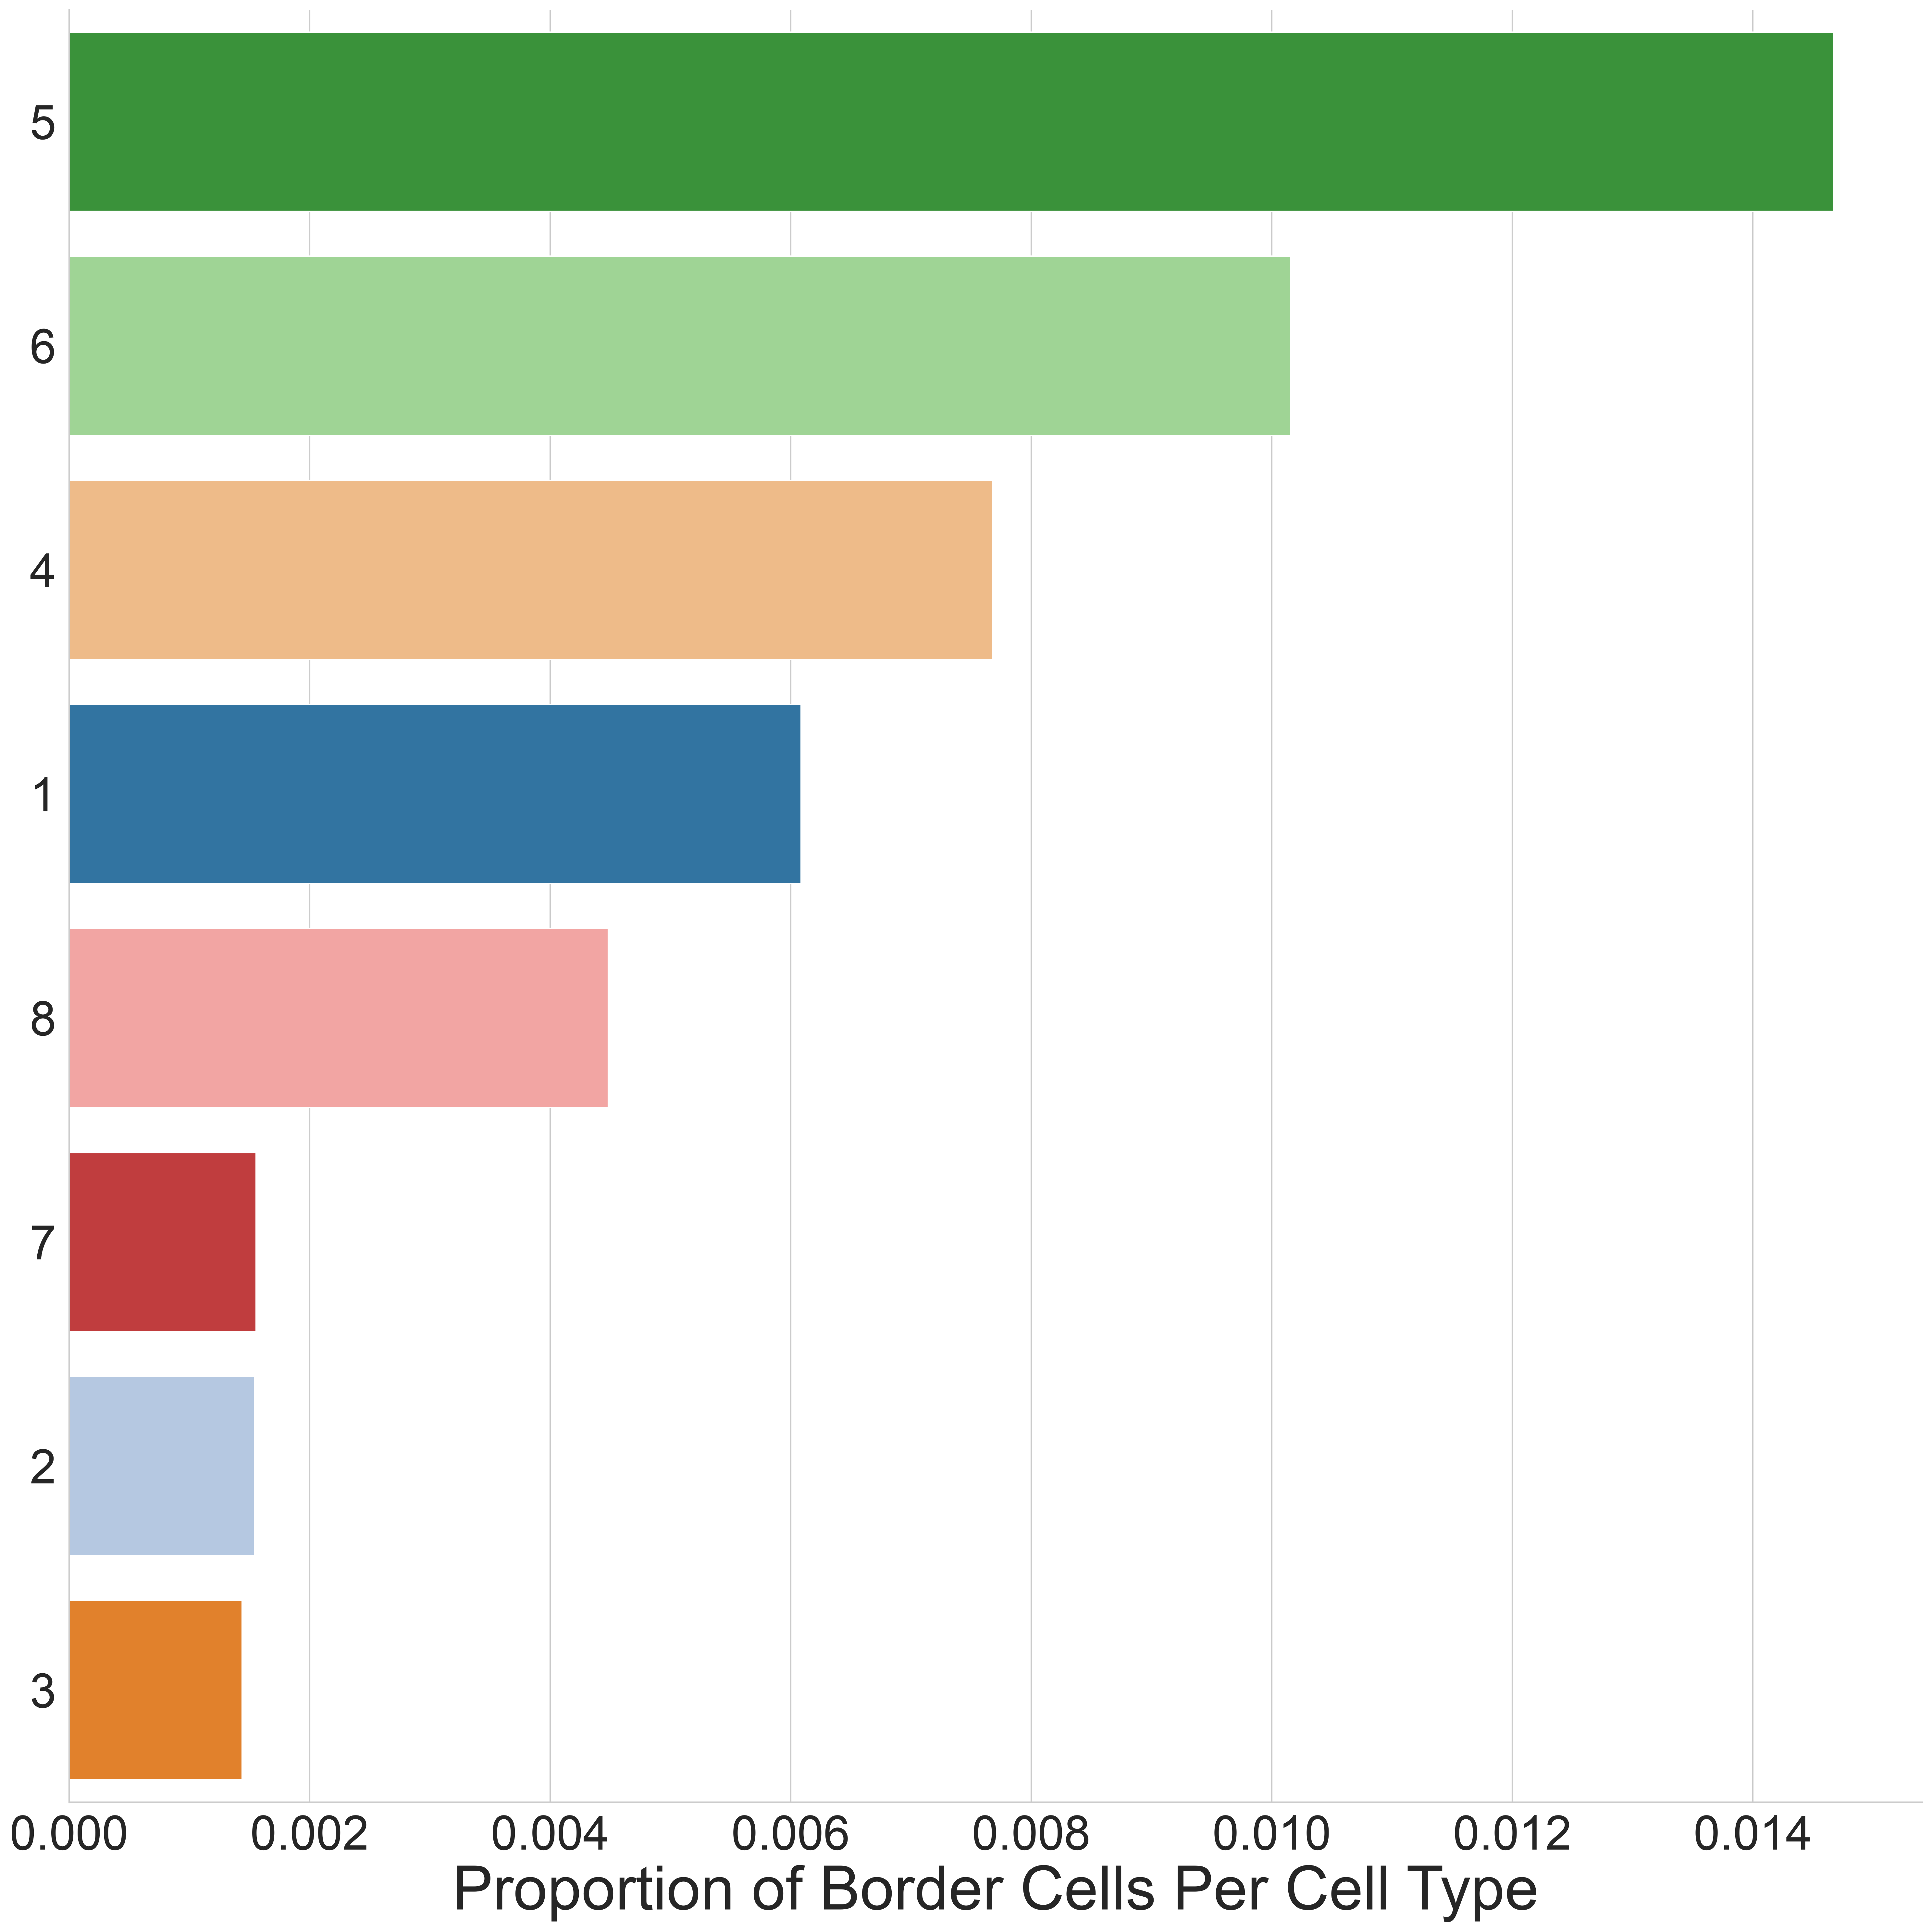

In [422]:
obs = cells.obs

# Filter for cells where Count_Above_Threshold == 2 or 3
subset = obs[obs["Count_Above_Threshold"].isin([2, 3])]

# Total counts per cell type
total_counts = obs["cell_type"].value_counts()

# Subset counts
subset_counts = subset["cell_type"].value_counts()

# Compute proportions (align safely)
proportion = (subset_counts / total_counts).fillna(0)

proportion_df = proportion.reset_index()
proportion_df.columns = ["cell_type", "Proportion"]

# Sort descending (largest first)
proportion_df = proportion_df.sort_values(
    by="Proportion",
    ascending=False
)

# --- CRITICAL STEP ---
# Force plotting order to match sorted order
order = proportion_df["cell_type"].tolist()

plt.figure(figsize=(20, 20), dpi=300)

sns.barplot(
    data=proportion_df,
    y="cell_type",
    x="Proportion",
    order=order,            # ensures top = largest
    palette=color_dict
)

sns.despine(top=True, right=True)

plt.xlabel("Proportion of Border Cells Per Cell Type", fontsize=45)
plt.ylabel("")
plt.yticks(fontsize=35)
plt.xticks(fontsize=35)
plt.tight_layout()
plt.show()


/var/folders/8c/5dh5r79j0hg6pp35ng2z69hw0000gn/T/ipykernel_7828/1202182659.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proportion_df, y='Neighborhood', x='Proportion', order=order, palette=palette)


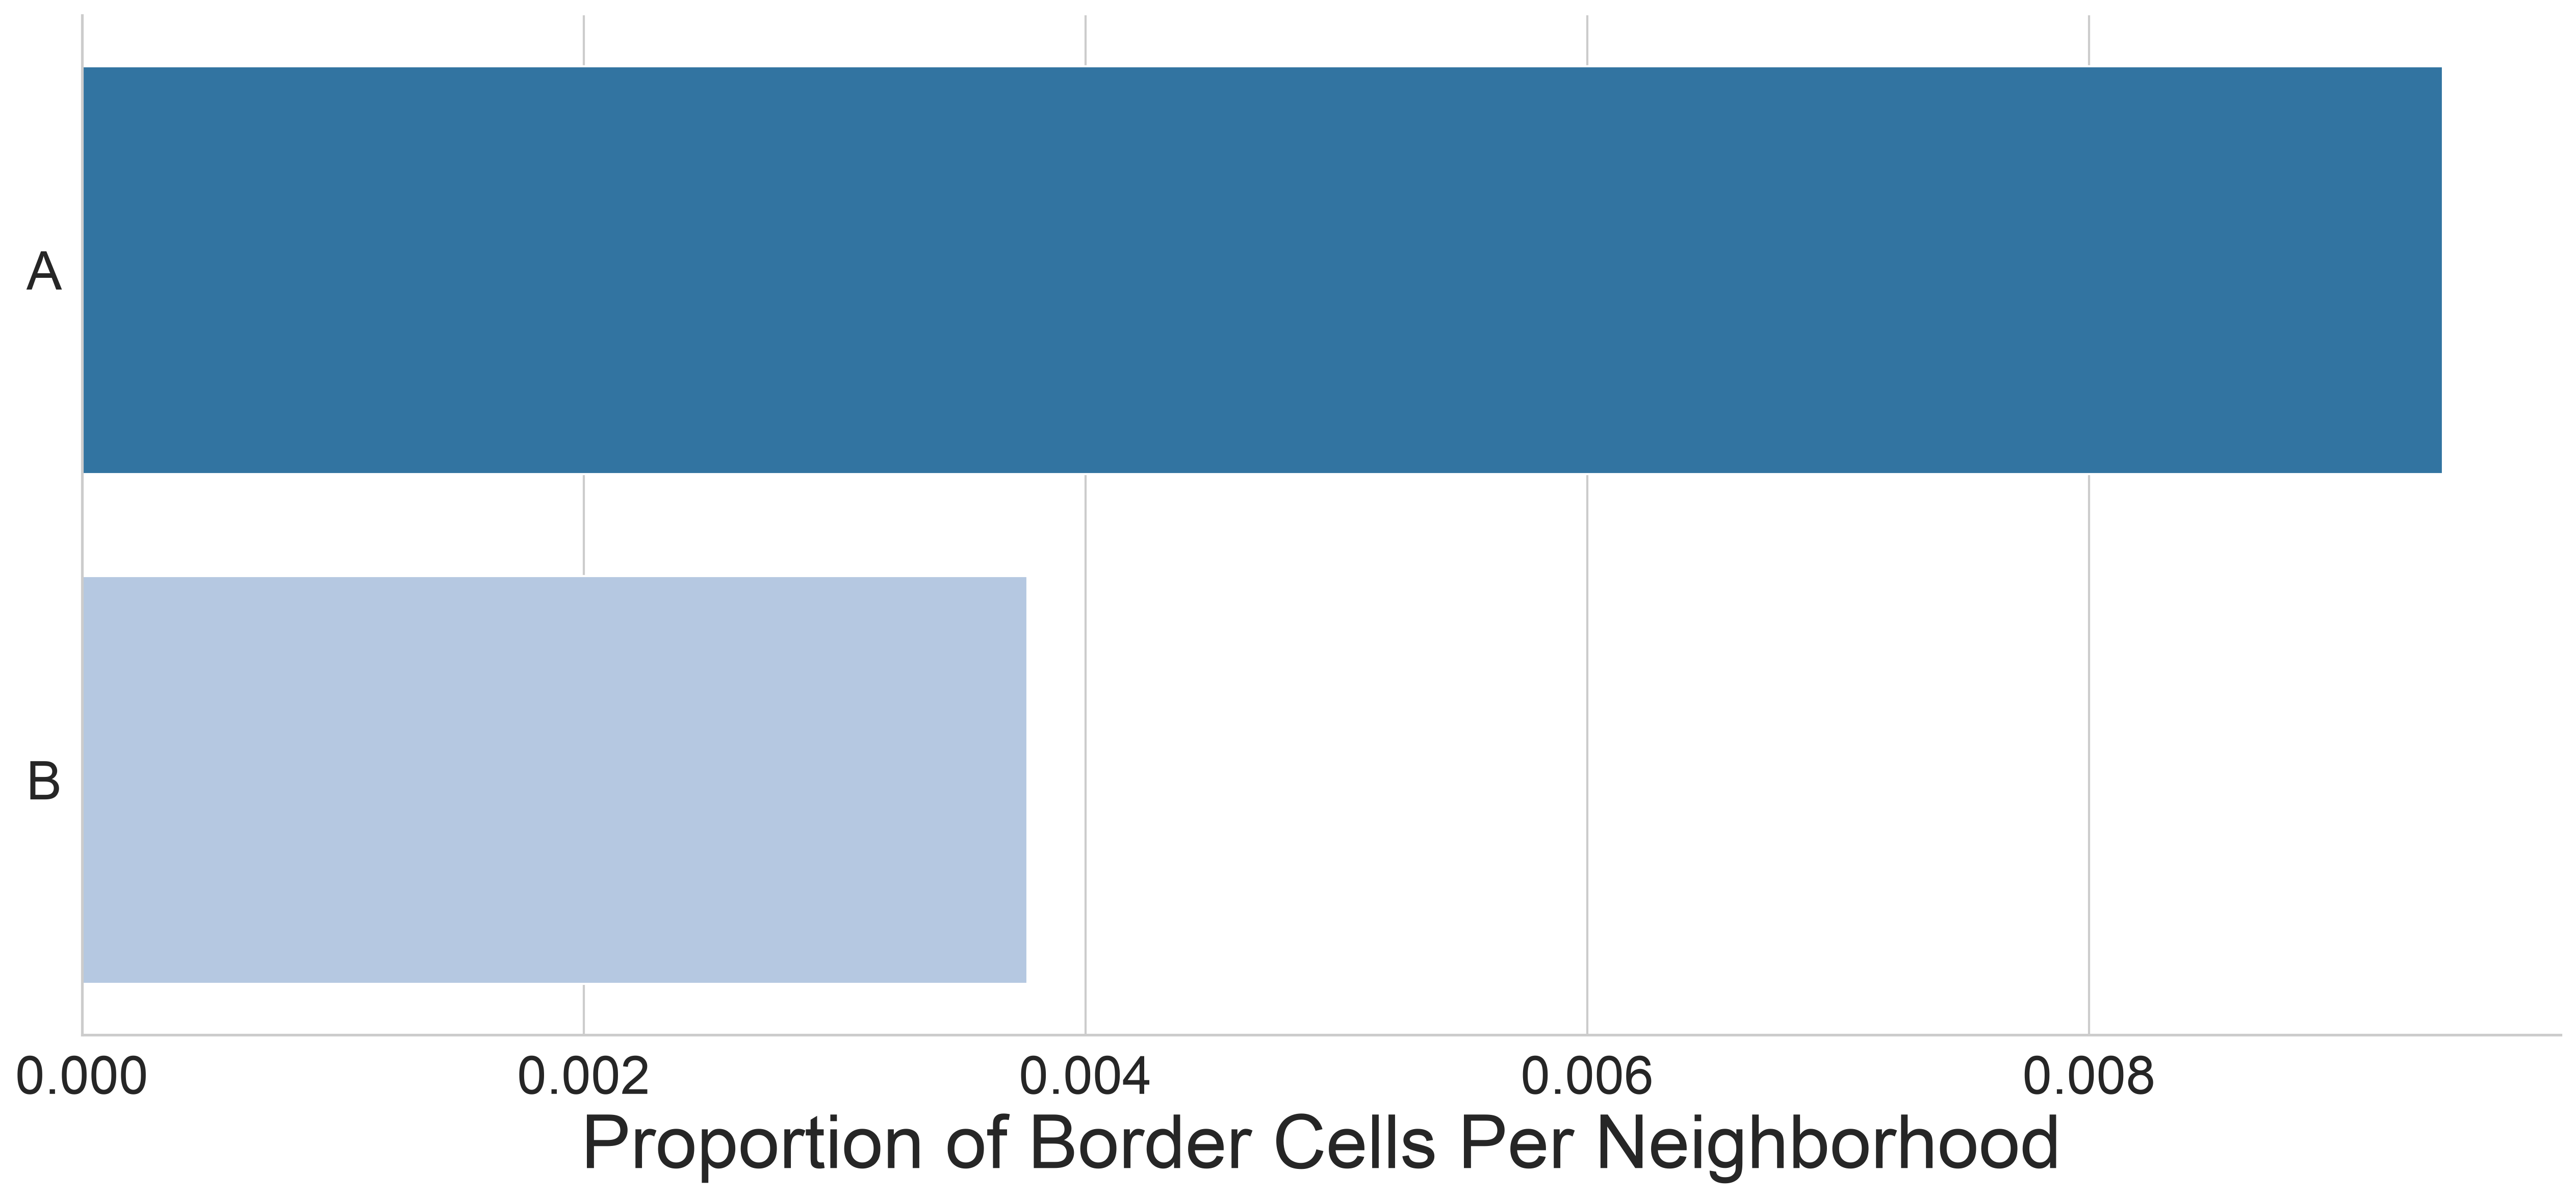

In [423]:
import seaborn as sns
import matplotlib.pyplot as plt

obs = cells.obs

neigh_dict, neigh_color_list, neigh_list = make_celltype_palette_strict(obs, cell_type_col='Neighborhood')
# Filter for cells where Count_Above_Threshold == 2 or 3
subset = obs[obs['Count_Above_Threshold'].isin([2, 3])]

# Total counts per cell type in the full dataset
total_counts = obs['Neighborhood'].value_counts()

# Subset counts per cell type (only those positive for more than one neighborhood)
subset_counts = subset['Neighborhood'].value_counts()

# Compute proportion per cell type
proportion_df = (subset_counts / total_counts).reset_index()
proportion_df.columns = ['Neighborhood', 'Proportion']

# Optional: sort by proportion
proportion_df = proportion_df.sort_values(by='Proportion', ascending=False)

# Create a unique color palette
palette = neigh_dict

order = proportion_df["Neighborhood"].tolist()
# Plot
plt.figure(figsize=(17, 8), dpi=300)
sns.barplot(data=proportion_df, y='Neighborhood', x='Proportion', order=order, palette=palette)

# Remove box spines except left & bottom
sns.despine(top=True, right=True)

# Labels and formatting
plt.xlabel('Proportion of Border Cells Per Neighborhood', fontsize=35)
plt.ylabel('')
plt.yticks(fontsize=25)
plt.xticks(fontsize=25)
plt.tight_layout()
plt.show()


In [424]:
probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,
    columns=cells.uns["neighborhood_probability_neighborhoods"],
)

mingl_border_mask = (
    (probabilities["A"] >= 0.25) &
    (probabilities["B"] >= 0.25)
)

plot_df = cells.obs.copy()
plot_df["MINGL_border"] = mingl_border_mask.to_numpy()

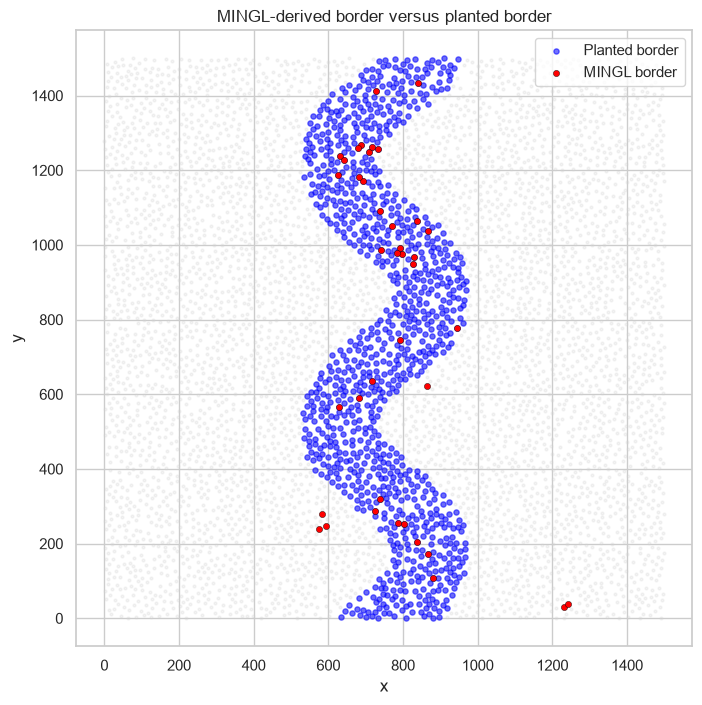

In [425]:
plt.figure(figsize=(8, 8))

plt.scatter(
    plot_df["x"],
    plot_df["y"],
    s=4,
    color="lightgray",
    alpha=0.25,
)

true_border = plot_df[plot_df["true_border"]]
mingl_border = plot_df[plot_df["MINGL_border"]]

plt.scatter(
    true_border["x"],
    true_border["y"],
    s=14,
    color="blue",
    alpha=0.55,
    label="Planted border",
)

plt.scatter(
    mingl_border["x"],
    mingl_border["y"],
    s=20,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    label="MINGL border",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("MINGL-derived border versus planted border")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()

In [426]:
# Confirm the relevant columns
print(synthetic_border.columns.tolist())

# Cell-type proportions in the planted border
border_comp = pd.crosstab(
    synthetic_border["true_border"],
    synthetic_border["cell_type"],
    normalize="index",
)

# Composition of A and B outside the planted border
non_border = synthetic_border[
    ~synthetic_border["true_border"]
]

A_comp = (
    non_border[
        non_border["true_organization"] == "A"
    ]["cell_type"]
    .value_counts(normalize=True)
)

B_comp = (
    non_border[
        non_border["true_organization"] == "B"
    ]["cell_type"]
    .value_counts(normalize=True)
)

# Align all cell types
all_cell_types = sorted(
    synthetic_border["cell_type"].unique()
)

border_values = (
    border_comp.loc[True]
    .reindex(all_cell_types, fill_value=0)
)

A_values = (
    A_comp
    .reindex(all_cell_types, fill_value=0)
)

B_values = (
    B_comp
    .reindex(all_cell_types, fill_value=0)
)

eps = 1e-9

true_log2_border_vs_A = np.log2(
    (border_values + eps) /
    (A_values + eps)
)

true_log2_border_vs_B = np.log2(
    (border_values + eps) /
    (B_values + eps)
)

true_check = pd.DataFrame({
    "border_vs_A": true_log2_border_vs_A,
    "border_vs_B": true_log2_border_vs_B,
})

####################################################
# Because the marker types are equi-abundant in A and
# B, border_vs_A and border_vs_B should agree for them.
# A marker whose two columns disagree indicates the
# marker signal has leaked onto the A/B identity axis.
####################################################

true_check["role"] = [
    "enriched" if ct in ENRICHED_TYPES
    else "depleted" if ct in DEPLETED_TYPES
    else "identity A" if ct in IDENTITY_A_TYPES
    else "identity B" if ct in IDENTITY_B_TYPES
    else "filler"
    for ct in true_check.index
]

true_check

['cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'true_border', 'true_border_operational', 'signed_distance', 'distance_from_border', 'window_frac_B', 'Neighborhood']


,border_vs_A,border_vs_B,role
cell_type,,,
1,-1.196495,2.448125,identity A
2,-1.360406,2.867078,identity A
3,2.440478,-1.507752,identity B
4,3.105924,-1.156891,identity B
5,0.920024,0.964500,enriched
6,0.816879,0.976798,enriched
7,-1.410999,-1.389080,depleted
8,-1.449458,-1.406470,depleted


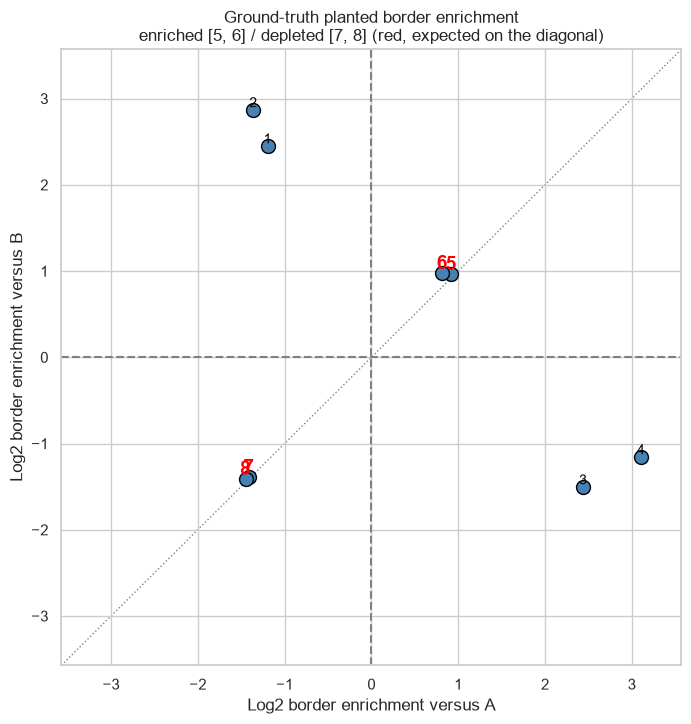

In [427]:
plot_true = true_check.copy()

plt.figure(figsize=(8, 8))

plt.scatter(
    plot_true["border_vs_A"],
    plot_true["border_vs_B"],
    s=100,
    color="steelblue",
    edgecolor="black",
)

for cell_type, row in plot_true.iterrows():

    if cell_type in MARKER_TYPES:
        fontsize = 14
        fontweight = "bold"
        color = "red"
    else:
        fontsize = 10
        fontweight = "normal"
        color = "black"

    plt.text(
        row["border_vs_A"],
        row["border_vs_B"],
        str(cell_type),
        fontsize=fontsize,
        fontweight=fontweight,
        color=color,
        ha="center",
        va="bottom",
    )

####################################################
# Markers should land on the y = x diagonal: they are
# equi-abundant in A and B, so their border enrichment
# is the same measured against either territory.
####################################################

lim = np.nanmax(np.abs(
    plot_true[["border_vs_A", "border_vs_B"]].values
)) * 1.15

plt.plot(
    [-lim, lim],
    [-lim, lim],
    color="gray",
    linestyle=":",
    linewidth=1,
    zorder=0,
)

plt.axvline(0, color="gray", linestyle="--")
plt.axhline(0, color="gray", linestyle="--")

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.xlabel("Log2 border enrichment versus A")
plt.ylabel("Log2 border enrichment versus B")
plt.title(
    f"Ground-truth planted border enrichment\n"
    f"enriched {ENRICHED_TYPES} / depleted {DEPLETED_TYPES} "
    f"(red, expected on the diagonal)"
)
plt.show()

In [428]:
####################################################
# MINGL border calls versus the planted border
#
# Scored against BOTH ground-truth definitions:
#   true_border             - geometric
#   true_border_operational - the window actually
#                             straddles both territories
#                             (the ceiling for any
#                             window-based method)
####################################################

probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs.index,
    columns=cells.uns["neighborhood_probability_neighborhoods"],
)

THRESHOLD = 0.25

mingl_border = (
    (probabilities["A"] >= THRESHOLD) &
    (probabilities["B"] >= THRESHOLD)
).to_numpy()


def score_border(truth, pred, label=""):
    """Precision / recall / IoU of a boolean border call."""

    truth = np.asarray(truth, dtype=bool)
    pred = np.asarray(pred, dtype=bool)

    tp = int((truth & pred).sum())
    fp = int((~truth & pred).sum())
    fn = int((truth & ~pred).sum())

    precision = tp / max(pred.sum(), 1)
    recall = tp / max(truth.sum(), 1)
    iou = tp / max((truth | pred).sum(), 1)

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "truth": label,
        "n_true": int(truth.sum()),
        "n_pred": int(pred.sum()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
    }


border_scores = pd.DataFrame([
    score_border(
        synthetic_border["true_border"],
        mingl_border,
        "geometric",
    ),
    score_border(
        synthetic_border["true_border_operational"],
        mingl_border,
        "operational",
    ),
]).set_index("truth")

print(border_scores.round(3).to_string())

####################################################
# Ranking quality, independent of where the threshold
# happens to sit on the probability scale
####################################################

from sklearn.metrics import roc_auc_score

min_prob = probabilities[["A", "B"]].min(axis=1).to_numpy()

print()
print("AUC (min-probability as border score):")
print(
    f"  vs geometric   : "
    f"{roc_auc_score(synthetic_border['true_border'], min_prob):.3f}"
)
print(
    f"  vs operational : "
    f"{roc_auc_score(synthetic_border['true_border_operational'], min_prob):.3f}"
)

####################################################
# Where the recall goes
####################################################

print()
print(
    "Fraction of cells with max probability > 1 - 1e-6 : "
    f"{(probabilities.max(axis=1) > 1 - 1e-6).mean():.3f}"
)
print(
    "For a probability in (0.25, 0.75) a cell needs |log-likelihood "
    "ratio| < log(3) = 1.10."
)

             n_true  n_pred  tp  fp   fn  precision  recall     f1    iou
truth                                                                    
geometric      1014      40  34   6  980      0.850   0.034  0.065  0.033
operational     224      40  13  27  211      0.325   0.058  0.098  0.052

AUC (min-probability as border score):
  vs geometric   : 0.876
  vs operational : 0.932

Fraction of cells with max probability > 1 - 1e-6 : 0.875
For a probability in (0.25, 0.75) a cell needs |log-likelihood ratio| < log(3) = 1.10.


In [429]:
synthetic_border

,cell_id,x,y,cell_type,unique_region,true_organization,true_border,true_border_operational,signed_distance,distance_from_border,window_frac_B,Neighborhood
0,0,205.045310,1322.758766,1,1,A,False,False,-360.595662,360.595662,0.0,A
1,1,1067.469050,599.405782,3,1,B,False,False,342.480053,342.480053,1.0,B
2,2,1403.731354,537.997025,7,1,B,False,False,766.911903,766.911903,1.0,B
3,3,852.773516,221.099842,5,1,A,True,True,-6.514162,6.514162,0.5,B
4,4,334.383767,695.634156,8,1,A,False,False,-279.695707,279.695707,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5995,249.115136,951.748081,1,1,A,False,False,-489.723467,489.723467,0.0,A
5996,5996,549.116242,473.522407,5,1,A,True,False,-84.257436,84.257436,0.0,A
5997,5997,1197.595965,39.215769,8,1,B,False,False,285.656896,285.656896,1.0,B
5998,5998,1158.096675,1144.550616,5,1,B,False,False,405.807195,405.807195,1.0,B


---

## Probability calibration

Everything above uses MINGL exactly as released. This last section is a
*diagnostic*, not a change to the method: it measures how much of the missing
recall is a calibration effect rather than a ranking failure.

MINGL scores a window by multiplying independent per-cell-type Gaussian
densities:

```
loglik[cell, nbhd] = sum_over_celltypes( -0.5 * z^2 - log(sd) )
```

The per-type marginals are individually well calibrated (the fitted `sd` values
match the binomial expectation `sqrt(k p (1-p))`). The **joint** is not: window
counts are multinomial with a fixed total `k`, so the per-type counts are
strongly negatively correlated and the terms in that sum are not independent.
Summing them as if they were multiplies the effective sample size by roughly the
number of cell types, which inflates `|log-likelihood ratio|` by the same
factor.

The consequence is mechanical. A cell needs `|LLR| < log(3) = 1.10` to land in
`(0.25, 0.75)` and be called a border cell. Among cells genuinely at the
interface the LLR spread is an order of magnitude wider than that, so most true
border cells are pushed to a hard 0/1 and are never called — even though the
*ranking* is largely correct (see the AUC above).

Dividing the log-likelihood by a constant temperature `T` before the softmax
tests this directly. It changes nothing about the model or the centroids; it
only rescales the confidence. If recall rises sharply with `T` while AUC is
unchanged, the loss was calibration.

In [430]:
####################################################
# Recompute MINGL's log-likelihood using MINGL's own
# KNN2 windows and centroid_Calculation - nothing here
# reimplements the model.
#
# Self-contained on purpose: the probability-binning
# section above rebinds `cluster_col` to
# "Probability_Bin_Cluster" and overwrites `centroids`
# with the bin-cluster version, and it converts several
# obs columns to categorical. A fresh AnnData with
# string columns is built here so this section is
# unaffected by any of that.
####################################################

from mingl.tl.knn2 import KNN2

CAL_CLUSTER_COL = "cell_type"
CAL_NEIGHBORHOOD_COL = "Neighborhood"
CAL_REGION_KEY = "unique_region"

cal_obs = cells.obs.copy()

for col in [CAL_CLUSTER_COL, CAL_NEIGHBORHOOD_COL, CAL_REGION_KEY]:
    cal_obs[col] = cal_obs[col].astype(str)

cal_adata = ad.AnnData(obs=cal_obs)

cal_adata.obs_names = [
    str(i) for i in range(len(cal_obs))
]

cal_centroids = mg.tl.centroid_Calculation(
    cal_adata,
    k=K_WINDOW,
    cluster_col=CAL_CLUSTER_COL,
    neighborhood_col=CAL_NEIGHBORHOOD_COL,
    region_col=CAL_REGION_KEY,
)

centroid_df = cal_centroids.to_df()

cell_type_names = list(
    cal_obs[CAL_CLUSTER_COL].unique()
)

mus = centroid_df[
    [f"{c}_mean" for c in cell_type_names]
].to_numpy(float)

sds = centroid_df[
    [f"{c}_std" for c in cell_type_names]
].to_numpy(float)

safe_sds = np.where(sds == 0, 1.0, sds)

window_counts = KNN2(
    cal_adata,
    cluster_col=CAL_CLUSTER_COL,
    region_key=CAL_REGION_KEY,
    ks=(K_WINDOW,),
)[K_WINDOW]

W = window_counts[cell_type_names].to_numpy(float)

z = (W[:, None, :] - mus[None, :, :]) / safe_sds[None, :, :]

loglik = (
    -0.5 * z ** 2
    - np.log(safe_sds)
).sum(axis=2)

neighborhood_names = list(centroid_df.index)

print("loglik matrix:", loglik.shape, neighborhood_names)

####################################################
# Sanity check: the per-cell-type marginals ARE
# calibrated. Fitted sd versus the binomial
# expectation sqrt(k p (1-p)) for a k-cell window.
####################################################

for row, nbhd in enumerate(neighborhood_names):

    p_hat = mus[row] / K_WINDOW

    expected_sd = np.sqrt(
        K_WINDOW * p_hat * (1 - p_hat)
    )

    print(
        f"  {nbhd}: mean fitted sd {sds[row].mean():.3f} "
        f"vs binomial {expected_sd.mean():.3f}"
    )


def temperature_probabilities(loglik, temperature):
    """Row-wise softmax of loglik / temperature."""

    scaled = loglik / float(temperature)

    scaled = scaled - scaled.max(axis=1, keepdims=True)

    p = np.exp(scaled)

    return p / p.sum(axis=1, keepdims=True)


####################################################
# Verify the softmax at T=1 reproduces MINGL's own
# probabilities, so the sweep below is measured
# against the real method and not a lookalike.
####################################################

mingl_probs = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,
    columns=cells.uns["neighborhood_probability_neighborhoods"],
)

P1 = temperature_probabilities(loglik, 1.0)

P1_df = pd.DataFrame(
    P1,
    columns=neighborhood_names,
    index=cells.obs_names,
)[mingl_probs.columns]

max_abs_diff = np.abs(
    P1_df.to_numpy() - mingl_probs.to_numpy()
).max()

print()
print(
    f"max |reconstructed - MINGL| probability: {max_abs_diff:.2e}"
)

####################################################
# The band a cell must fall inside to be called
####################################################

interface = (
    synthetic_border["true_border_operational"].to_numpy()
)

llr = loglik[:, 0] - loglik[:, 1]

print()
print(
    f"|LLR| among interface cells: "
    f"median {np.median(np.abs(llr[interface])):.1f}, "
    f"SD {llr[interface].std():.1f}"
)
print("required for a border call: |LLR| < log(3) = 1.10")

Example dummy cols: ['cell_type__1', 'cell_type__2', 'cell_type__3', 'cell_type__4', 'cell_type__5']
{5:                 x            y unique_region cell_type    1    2    3    4  \
0      205.045310  1322.758766             1         1  1.0  2.0  0.0  0.0   
1     1067.469050   599.405782             1         3  0.0  0.0  2.0  0.0   
2     1403.731354   537.997025             1         7  0.0  0.0  3.0  0.0   
3      852.773516   221.099842             1         5  1.0  0.0  1.0  0.0   
4      334.383767   695.634156             1         8  2.0  0.0  0.0  0.0   
...           ...          ...           ...       ...  ...  ...  ...  ...   
5995   249.115136   951.748081             1         1  2.0  1.0  0.0  0.0   
5996   549.116242   473.522407             1         5  0.0  1.0  0.0  0.0   
5997  1197.595965    39.215769             1         8  0.0  0.0  0.0  0.0   
5998  1158.096675  1144.550616             1         5  0.0  0.0  1.0  0.0   
5999   146.118515   265.244208       

/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/miniconda3/envs/mingl-env/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


    n_pred  precision  recall     f1    iou    auc
T                                                 
1       40      0.325   0.058  0.098  0.052  0.932
2       95      0.347   0.147  0.207  0.115  0.932
3      136      0.360   0.219  0.272  0.158  0.932
5      244      0.381   0.415  0.397  0.248  0.932
8      437      0.286   0.558  0.378  0.233  0.932
12     697      0.234   0.728  0.354  0.215  0.932
20    1374      0.155   0.951  0.267  0.154  0.932
40    3271      0.068   1.000  0.128  0.068  0.932


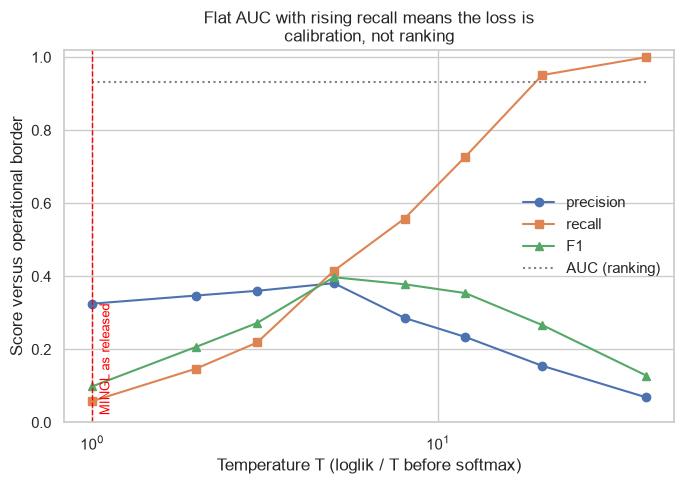

In [431]:
####################################################
# Temperature sweep
####################################################

sweep_rows = []

for T in [1, 2, 3, 5, 8, 12, 20, 40]:

    P = temperature_probabilities(loglik, T)

    pred = (P.min(axis=1) >= THRESHOLD)

    row = score_border(interface, pred, label=T)

    row["auc"] = roc_auc_score(
        interface,
        P.min(axis=1),
    )

    sweep_rows.append(row)

sweep = pd.DataFrame(sweep_rows).rename(
    columns={"truth": "T"}
).set_index("T")

print(sweep[
    ["n_pred", "precision", "recall", "f1", "iou", "auc"]
].round(3).to_string())

####################################################
# Plot
####################################################

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    sweep.index,
    sweep["precision"],
    "o-",
    label="precision",
)

ax.plot(
    sweep.index,
    sweep["recall"],
    "s-",
    label="recall",
)

ax.plot(
    sweep.index,
    sweep["f1"],
    "^-",
    label="F1",
)

ax.plot(
    sweep.index,
    sweep["auc"],
    ":",
    color="gray",
    label="AUC (ranking)",
)

ax.axvline(
    1,
    color="red",
    linestyle="--",
    linewidth=1,
)

ax.text(
    1.05,
    0.02,
    "MINGL as released",
    color="red",
    fontsize=9,
    rotation=90,
    va="bottom",
)

ax.set_xscale("log")
ax.set_xlabel("Temperature T (loglik / T before softmax)")
ax.set_ylabel("Score versus operational border")
ax.set_ylim(0, 1.02)
ax.set_title(
    "Flat AUC with rising recall means the loss is\n"
    "calibration, not ranking"
)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [432]:
####################################################
# Enrichment recovery: released MINGL versus the
# temperature-corrected call
####################################################

T_USE = 3.0

P_cal = temperature_probabilities(loglik, T_USE)

border_calls = {
    "MINGL (T=1)": (
        temperature_probabilities(loglik, 1.0).min(axis=1)
        >= THRESHOLD
    ),
    f"MINGL (T={T_USE:g})": (
        P_cal.min(axis=1) >= THRESHOLD
    ),
    "planted truth": synthetic_border[
        "true_border"
    ].to_numpy(),
}

all_cell_types = sorted(
    synthetic_border["cell_type"].unique()
)

eps = 1e-9

enrichment_rows = []

for label, mask in border_calls.items():

    inside = (
        synthetic_border.loc[mask, "cell_type"]
        .value_counts(normalize=True)
        .reindex(all_cell_types, fill_value=0)
    )

    outside = (
        synthetic_border.loc[~mask, "cell_type"]
        .value_counts(normalize=True)
        .reindex(all_cell_types, fill_value=0)
    )

    log2fc = np.log2(
        (inside + eps) / (outside + eps)
    )

    for ct in all_cell_types:

        enrichment_rows.append({
            "method": label,
            "cell_type": ct,
            "log2FC": log2fc[ct],
            "role": (
                "enriched" if ct in ENRICHED_TYPES
                else "depleted" if ct in DEPLETED_TYPES
                else "background"
            ),
        })

enrichment = pd.DataFrame(enrichment_rows)

print(
    enrichment.pivot(
        index="cell_type",
        columns="method",
        values="log2FC",
    ).round(2).to_string()
)

####################################################
# Direction recovered correctly?
####################################################

for label in border_calls:

    sub = enrichment[enrichment["method"] == label]

    enr_ok = (
        sub.loc[sub["role"] == "enriched", "log2FC"] > 0
    ).all()

    dep_ok = (
        sub.loc[sub["role"] == "depleted", "log2FC"] < 0
    ).all()

    print(
        f"{label:>18}: enriched direction "
        f"{'OK' if enr_ok else 'FAIL'}, "
        f"depleted direction {'OK' if dep_ok else 'FAIL'}"
    )

method     MINGL (T=1)  MINGL (T=3)  planted truth
cell_type                                         
1                -0.13        -1.11          -0.32
2                -2.12        -1.09          -0.45
3                -2.22        -1.41          -0.58
4                 0.21         0.52          -0.22
5                 1.15         0.80           0.94
6                 0.61         0.97           0.89
7                -2.11        -1.57          -1.40
8                -0.58        -1.36          -1.43
       MINGL (T=1): enriched direction OK, depleted direction OK
       MINGL (T=3): enriched direction OK, depleted direction OK
     planted truth: enriched direction OK, depleted direction OK


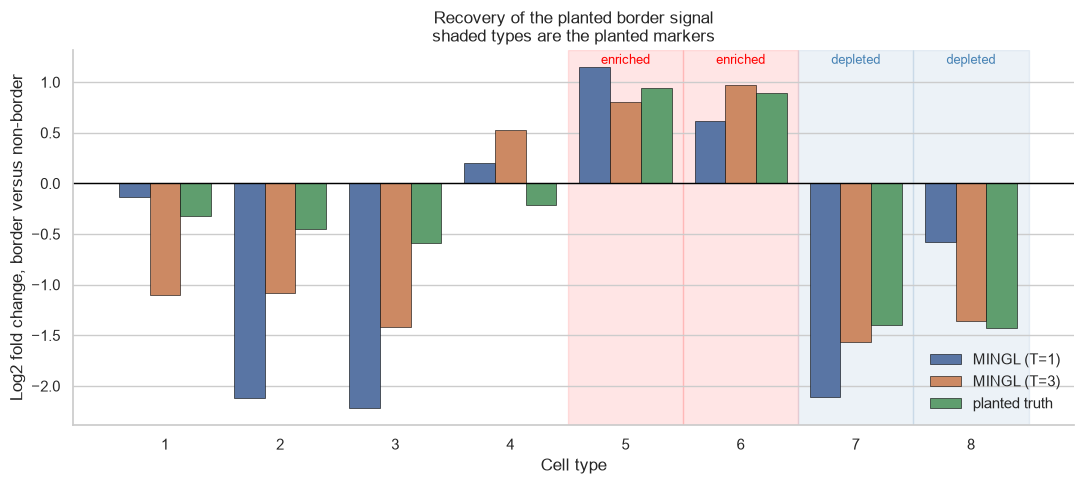

wrote /Volumes/data/MINGLE/Reviewer Response/Code/R1.5/border_recovery_benchmark.csv
wrote /Volumes/data/MINGLE/Reviewer Response/Code/R1.5/temperature_sweep.csv


In [433]:
####################################################
# Final figure: log2 fold change by cell type
####################################################

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=enrichment,
    x="cell_type",
    y="log2FC",
    hue="method",
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
)

ax.axhline(0, color="black", linewidth=1)

ymin, ymax = ax.get_ylim()

for ct in all_cell_types:

    role = enrichment.loc[
        enrichment["cell_type"] == ct,
        "role",
    ].iloc[0]

    if role == "background":
        continue

    ax.axvspan(
        all_cell_types.index(ct) - 0.5,
        all_cell_types.index(ct) + 0.5,
        color="red" if role == "enriched" else "steelblue",
        alpha=0.10,
        zorder=0,
    )

    ax.text(
        all_cell_types.index(ct),
        ymax * 0.97,
        role,
        ha="center",
        va="top",
        fontsize=9,
        color="red" if role == "enriched" else "steelblue",
    )

ax.set_xlabel("Cell type")
ax.set_ylabel("Log2 fold change, border versus non-border")
ax.set_title(
    "Recovery of the planted border signal\n"
    "shaded types are the planted markers"
)
ax.legend(
    frameon=False,
    loc="lower right",
)

sns.despine()
plt.tight_layout()
plt.show()

####################################################
# Save
####################################################

BENCH_PATH = os.path.join(OUT_DIR, "border_recovery_benchmark.csv")

enrichment.to_csv(BENCH_PATH, index=False)

SWEEP_PATH = os.path.join(OUT_DIR, "temperature_sweep.csv")

sweep.to_csv(SWEEP_PATH)

print("wrote", BENCH_PATH)
print("wrote", SWEEP_PATH)